In [1]:
# 0

import warnings
from pathlib import Path

import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [2]:
# 1

XLSX = 'kospi_data.xlsx'

EXCLUDE_FIN = ['A000680', 'A000880', 'A005110', 'A008060', 'A015020', 'A023590',
               'A026890', 'A030190', 'A034310', 'A210980', 'A244920']

def build_gd(path=XLSX, out='gd.parquet'):
    if Path(out).exists():
        df = pd.read_parquet(out)
        print(f'{out} loaded. {len(df)}행  {df["qtr"].min()} ~ {df["qtr"].max()}')
        return df
    raw = pd.read_excel(path, sheet_name='34_gd', header=None)
    body = raw.iloc[14:, :2].dropna()
    df = pd.DataFrame({
        'qtr': pd.PeriodIndex(body.iloc[:, 0].astype(str), freq='Q'),
        'gd': pd.to_numeric(body.iloc[:, 1], errors='coerce'),
    }).dropna().sort_values('qtr').reset_index(drop=True)
    df.to_parquet(out)
    print(f'{out} written. {len(df)}행  {df["qtr"].min()} ~ {df["qtr"].max()}')
    return df

financials = pd.read_parquet('financials.parquet')
financials = financials[~financials['code'].isin(EXCLUDE_FIN)].reset_index(drop=True)

prices = pd.read_parquet('prices.parquet')
prices = prices[~prices['code'].isin(EXCLUDE_FIN)].reset_index(drop=True)

delisted = pd.read_parquet('delisted.parquet')
delisted = delisted[~delisted['code'].isin(EXCLUDE_FIN)].reset_index(drop=True)

gd = build_gd()

print(f'financials  {financials.shape}  종목 {financials["code"].nunique()}')
print(f'prices      {prices.shape}  종목 {prices["code"].nunique()}')
print(f'delisted    {len(delisted)}개')
print(f'columns: {financials.columns.tolist()}')

gd.parquet loaded. 105행  2000Q1 ~ 2026Q1
financials  (116235, 29)  종목 1107
prices      (353133, 5)  종목 1107
delisted    355개
columns: ['code', 'date', 'actq', 'rectq', 'invtq', 'ppentq', 'atq', 'lctq', 'dlttq', 'dlcq', 'ltq', 'seqq', 'cogsq', 'xsgaq', 'saleq', 'apq', 'opinc', 'xintq', 'ibq', 'txditcq', 'pstkq', 'cheq', 'oancfq', 'dpq', 'dvq', 'cstkq', 'req', 'epsq', 'txtq']


In [3]:
# 2

FORCE_IMPAIR = ['A001600', 'A006210']
FORCE_REORG = ['A019930']
BAD_DEFAULT = ['A011840', 'A018590', 'A001980', 'A010730', 'A005600',
               'A007050', 'A011800', 'A002130']
BAD_SUSPEND = ['A000200', 'A003810', 'A017120', 'A000310', 'A004510',
               'A004550', 'A004740', 'A012600', 'A093230']
FORMAL = ['A003980', 'A012720', 'A009790', 'A012270', 'A008750', 'A003020',
          'A009760', 'A006250', 'A001190', 'A016160', 'A015110', 'A002530',
          'A017320', 'A014080', 'A008500']
MERGER_EXTRA = ['A103160', 'A049770', 'A008000', 'A002250', 'A027390', 'A144620',
                'A015350', 'A138250', 'A068400', 'A001880', 'A003410', 'A115390',
                'A034300', 'A010420', 'A450140', 'A019440']
NAN_CODES = ['A950010', 'A011160', 'A102280']

BAD_CATS = ['감사의견', '자본잠식', '정리절차', '부도', '실질심사']
NONBAD_CATS = ['합병', '자진', '형식요건']

d = delisted.copy()
d['cat'] = '미분류'
d.loc[d['reason_cat'] == '감사의견', 'cat'] = '감사의견'
d.loc[d['reason_cat'] == '자본잠식', 'cat'] = '자본잠식'
d.loc[d['reason_cat'] == '정리절차', 'cat'] = '정리절차'
d.loc[d['reason_cat'] == '합병·해산', 'cat'] = '합병'
d.loc[d['reason_cat'] == '자진·신청', 'cat'] = '자진'
d.loc[d['code'].isin(FORCE_IMPAIR), 'cat'] = '자본잠식'
d.loc[d['code'].isin(FORCE_REORG), 'cat'] = '정리절차'
d.loc[d['code'].isin(BAD_DEFAULT), 'cat'] = '부도'
d.loc[d['code'].isin(BAD_SUSPEND), 'cat'] = '실질심사'
d.loc[d['code'].isin(FORMAL), 'cat'] = '형식요건'
d.loc[d['code'].isin(MERGER_EXTRA), 'cat'] = '합병'
d.loc[d['code'].isin(NAN_CODES), 'cat'] = '미분류'

d['is_bad'] = d['cat'].isin(BAD_CATS).astype(int)
d['excl'] = (d['cat'] == '미분류').astype(int)
d.to_parquet('delisted_cat.parquet')

fin_has = financials.groupby('code')['atq'].apply(lambda s: s.notna().any())
fin_codes = set(fin_has[fin_has].index)
h = d[d['code'].isin(fin_codes)]

cnt = pd.DataFrame({
    '전체': d['cat'].value_counts(),
    '재무존재': h['cat'].value_counts(),
}).reindex(BAD_CATS + NONBAD_CATS + ['미분류']).fillna(0).astype(int)
cnt['구분'] = np.where(cnt.index.isin(BAD_CATS), '부실',
                     np.where(cnt.index.isin(NONBAD_CATS), '비부실', '미분류'))

blocks = [cnt[cnt['구분'] == g].sort_values('재무존재', ascending=False)
          for g in ['부실', '비부실', '미분류']]
tbl = pd.concat(blocks).rename_axis('사유').reset_index()[['구분', '사유', '전체', '재무존재']]
display(tbl)

sub = tbl.groupby('구분', sort=False)[['전체', '재무존재']].sum().reindex(['부실', '비부실', '미분류'])
sub.loc['합계'] = sub.sum()
display(sub)

hb = h[h['is_bad'] == 1].copy()
hb['year'] = hb['del_date'].dt.year.astype(int)
yr = (hb.groupby(['year', 'cat']).size().unstack('cat', fill_value=0)
      .reindex(columns=blocks[0].index.tolist(), fill_value=0))
yr['합계'] = yr.sum(axis=1)
yr.loc['합계'] = yr.sum()
display(yr)

YR0, YR1 = 2002, 2025

excl_codes = set(d.query('excl == 1')['code'])
dcx = d[d['excl'] == 0][['code', 'del_date', 'is_bad']].copy()
dcx['del_year'] = dcx['del_date'].dt.year.astype(int)

pxr = prices.copy()
pxr['year'] = pd.to_datetime(pxr['date']).dt.year
live = pxr[pxr['ret'].notna() | pxr['mktcap'].notna()]
alive = live[['code', 'year']].drop_duplicates()

delyr = dcx[['code', 'del_year']].rename(columns={'del_year': 'year'})
alive = pd.concat([alive, delyr], ignore_index=True).drop_duplicates()

alive = alive[(alive['year'] >= YR0) & (alive['year'] <= YR1)]
alive = alive[~alive['code'].isin(excl_codes)]
alive = alive.merge(dcx[['code', 'del_year', 'is_bad']], on='code', how='left')
alive = alive[alive['del_year'].isna() | (alive['year'] <= alive['del_year'])]
alive['y'] = ((alive['del_year'] == alive['year']) & (alive['is_bad'] == 1)).astype(int)
alive['censored'] = ((alive['del_year'] == alive['year']) & (alive['is_bad'] == 0)).astype(int)

riskset = (alive.rename(columns={'year': 'obs_year'})[['code', 'obs_year', 'y', 'censored']]
           .sort_values(['code', 'obs_year']).reset_index(drop=True))
riskset.to_parquet('riskset.parquet')

rs = pd.DataFrame({'값': [
    len(riskset), riskset['code'].nunique(),
    f"{int(riskset['obs_year'].min())}~{int(riskset['obs_year'].max())}",
    int(riskset['y'].sum()), int(riskset['censored'].sum())]},
    index=pd.Index(['위험집합 행', '종목', '기간', '사건', '절단'], name='항목'))
display(rs)

,구분,사유,전체,재무존재
0,부실,감사의견,71,70
1,부실,자본잠식,31,23
2,부실,정리절차,31,10
3,부실,실질심사,9,9
4,부실,부도,8,8
5,비부실,합병,130,83
6,비부실,형식요건,15,15
7,비부실,자진,23,14
8,미분류,미분류,37,3


,전체,재무존재
구분,,
부실,150,120
비부실,168,112
미분류,37,3
합계,355,235


cat,감사의견,자본잠식,정리절차,실질심사,부도,합계
year,,,,,,
2000,0,0,1,0,0,1
2001,0,0,4,4,1,9
2002,15,4,1,0,0,20
2003,2,1,1,0,1,5
2004,5,1,1,1,3,11
2005,5,2,2,0,1,10
2006,1,0,0,0,0,1
2007,1,4,0,0,0,5
2008,1,0,0,0,0,1


,값
항목,
위험집합 행,16678
종목,965
기간,2002~2025
사건,105
절단,98


In [4]:
# D1

dr = pd.read_parquet('daily_returns.parquet')
px = pd.read_parquet('prices.parquet')
dc = pd.read_parquet('delisted_cat.parquet')
mk = pd.read_parquet('market.parquet')
for df in (dr, px, mk):
    df['date'] = pd.to_datetime(df['date'])
dc['del_date'] = pd.to_datetime(dc['del_date'])
dr['ym'] = pd.PeriodIndex(dr['date'], freq='M')
px['ym'] = pd.PeriodIndex(px['date'], freq='M')
bad = dc[(dc['is_bad'] == 1) & (dc['excl'] == 0)][['code', 'del_date']]

xa = dr.merge(bad, on='code'); xa['d2d'] = (xa['del_date'] - xa['date']).dt.days
xb = px.merge(bad, on='code'); xb['d2d'] = (xb['del_date'] - xb['date']).dt.days
rows = []
for lo, hi, lab in [(0, 365, '0~1년'), (365, 730, '1~2년'),
                    (730, 1095, '2~3년'), (1095, 1825, '3~5년')]:
    a = xa[(xa['d2d'] >= lo) & (xa['d2d'] < hi)]
    b = xb[(xb['d2d'] >= lo) & (xb['d2d'] < hi)]
    rows.append({'폐지 전': lab,
                 '일별 관측': len(a), '일별 0%': round((a['dret'] == 0).mean() * 100, 1),
                 '월별 관측': len(b), '월별 0%': round((b['ret'] == 0).mean() * 100, 1),
                 '월별 결측%': round(b['ret'].isna().mean() * 100, 1)})
norm = dr[~dr['code'].isin(set(bad['code']))]
normp = px[~px['code'].isin(set(bad['code']))]
rows.append({'폐지 전': '정상종목',
             '일별 관측': len(norm), '일별 0%': round((norm['dret'] == 0).mean() * 100, 1),
             '월별 관측': len(normp), '월별 0%': round((normp['ret'] == 0).mean() * 100, 1),
             '월별 결측%': round(normp['ret'].isna().mean() * 100, 1)})
d1a = pd.DataFrame(rows).set_index('폐지 전')
display(d1a)

zf = (dr.groupby(['code', 'ym'])['dret']
      .apply(lambda s: (s == 0).mean()).rename('zfrac').reset_index())
mm = px[['code', 'ym', 'ret']].merge(zf, on=['code', 'ym'], how='inner')
rows = []
for lo, hi, lab in [(0, .2, '0~20%'), (.2, .5, '20~50%'),
                    (.5, .9, '50~90%'), (.9, 1.01, '90~100%')]:
    s = mm[(mm['zfrac'] >= lo) & (mm['zfrac'] < hi)]
    rows.append({'월내 일별 0 비율': lab, '종목-월': len(s),
                 '월별 ret=0 %': round((s['ret'] == 0).mean() * 100, 2),
                 '월별 ret 결측 %': round(s['ret'].isna().mean() * 100, 2)})
d1b = pd.DataFrame(rows).set_index('월내 일별 0 비율')
display(d1b)

kk = mk.set_index('date')['kret']
dr2 = dr.assign(kret=dr['date'].map(kk)).dropna(subset=['kret'])
rows = []
for lo, hi, lab in [(0, .2, '|kret| ≤ 0.2%'), (.2, 1.0, '0.2~1%'), (1.0, 99, '> 1%')]:
    s = dr2[(dr2['kret'].abs() >= lo) & (dr2['kret'].abs() < hi)]
    rows.append({'시장 변동': lab, '관측': len(s),
                 'dret=0 %': round((s['dret'] == 0).mean() * 100, 2)})
d1c = pd.DataFrame(rows).set_index('시장 변동')
display(d1c)

,일별 관측,일별 0%,월별 관측,월별 0%,월별 결측%
폐지 전,,,,,
0~1년,26980,34.1,1478,25.6,0.7
1~2년,24948,19.4,1379,14.9,0.0
2~3년,20688,12.7,1170,6.3,0.3
3~5년,34195,9.1,1981,1.8,2.8
정상종목,4113491,7.8,305283,1.0,32.9


,종목-월,월별 ret=0 %,월별 ret 결측 %
월내 일별 0 비율,,,
0~20%,195448,0.88,0.03
20~50%,13255,2.44,0.27
50~90%,992,3.12,5.54
90~100%,1782,89.00,3.25


,관측,dret=0 %
시장 변동,,
|kret| ≤ 0.2%,733497,8.76
0.2~1%,2009207,8.55
> 1%,1579140,7.23


In [5]:
# D2

FULL_HALT = 0.95
EXTREME = 100.0

d = pd.read_parquet('daily_returns.parquet')
d['date'] = pd.to_datetime(d['date'])
d = d.sort_values(['code', 'date']).reset_index(drop=True)
d['ym'] = pd.PeriodIndex(d['date'], freq='M')
d['year'] = d['date'].dt.year
dc = pd.read_parquet('delisted_cat.parquet')
BADSET = set(dc.loc[(dc['is_bad'] == 1) & (dc['excl'] == 0), 'code'])

d['is0'] = (d['dret'] == 0).astype(int)
d['grp'] = (d['is0'] != d.groupby('code')['is0'].shift()).cumsum()
runs = (d[d['is0'] == 1].groupby(['code', 'grp'])
        .agg(n=('date', 'size'), start=('date', 'min')).reset_index())

rows = []
for k in range(1, 26):
    s = runs[runs['n'] == k]
    if not len(s): continue
    rows.append({'연속 0 길이': k, '구간 수': len(s), '종목': s['code'].nunique(),
                 '부실종목': len(set(s['code']) & BADSET)})
d2a = pd.DataFrame(rows).set_index('연속 0 길이')
display(d2a)

d['runlen_yr'] = d.groupby(['grp', 'year'])['is0'].transform('size')
rows = []
for N in [3, 5, 8, 10, 15, 20, 30]:
    hh = (d['is0'] == 1) & (d['runlen_yr'] >= N)
    a = (pd.DataFrame({'code': d['code'], 'ym': d['ym'], 'h': hh.astype(int)})
         .groupby(['code', 'ym']).agg(n=('h', 'size'), k=('h', 'sum')).reset_index())
    a['f'] = a['k'] / a['n']
    rows.append({'기준일수': N, '정지일': int(hh.sum()),
                 '전체 대비 %': round(hh.mean() * 100, 2),
                 '완전정지 월': int((a['f'] >= FULL_HALT).sum()),
                 '부분정지 월': int(((a['f'] > 0) & (a['f'] < FULL_HALT)).sum()),
                 '정지 종목': int(d.loc[hh, 'code'].nunique())})
d2b = pd.DataFrame(rows).set_index('기준일수')
display(d2b)

rows = []
for N in [5, 8, 20]:
    h = runs[runs['n'] >= N].copy()
    h['m'] = h['start'].dt.month
    rows.append({'기준': f'≥{N}일', **{f'{m}월': int((h['m'] == m).sum())
                                      for m in range(1, 13)}})
d2c = pd.DataFrame(rows).set_index('기준')
display(d2c)

d2d = (d[d['dret'].abs() > EXTREME][['code', 'date', 'dret']]
       .sort_values('dret', ascending=False).reset_index(drop=True))
d2d.index = d2d.index + 1
display(d2d)

,구간 수,종목,부실종목
연속 0 길이,,,
1,235489,952,112
2,23906,913,105
3,3755,719,79
4,904,379,47
5,271,164,17
6,137,92,13
7,67,58,9
8,47,38,3
9,55,53,9


,정지일,전체 대비 %,완전정지 월,부분정지 월,정지 종목
기준일수,,,,,
3,66699,1.54,1683,6960,819
5,51829,1.20,1683,2393,628
8,48954,1.13,1681,1821,560
10,48033,1.11,1679,1675,535
15,43160,1.00,1648,1078,394
20,38287,0.89,1630,574,275
30,33931,0.78,1532,275,139


,1월,2월,3월,4월,5월,6월,7월,8월,9월,10월,11월,12월
기준,,,,,,,,,,,,
≥5일,101,137,193,311,92,131,86,112,94,113,118,157
≥8일,66,105,150,243,59,87,53,69,66,72,75,125
≥20일,22,43,86,31,20,35,16,16,23,19,25,35


,code,date,dret
1,A008080,2013-09-11,6699900.00
2,A018570,2002-04-29,863.41
3,A004230,2009-04-29,500.00
4,A005560,2003-04-15,425.25
5,A004550,2012-05-14,400.00
6,A007050,2009-04-08,333.33
7,A001920,2002-03-29,200.00
8,A005060,2002-04-09,200.00
9,A016160,2011-04-20,182.05
10,A008020,2016-05-11,153.66


In [6]:
# 3

HALT_N = 8
FULL_HALT = 0.95
EXTREME = 100.0
SENS_N = [5, 8, 10, 15]

d = pd.read_parquet('daily_returns.parquet')
d['date'] = pd.to_datetime(d['date'])
d = d.sort_values(['code', 'date']).reset_index(drop=True)
d['ym'] = pd.PeriodIndex(d['date'], freq='M')
d['year'] = d['date'].dt.year

d['is0'] = (d['dret'] == 0).astype(int)
d['grp'] = (d['is0'] != d.groupby('code')['is0'].shift()).cumsum()
d['runlen_yr'] = d.groupby(['grp', 'year'])['is0'].transform('size')
d['halt'] = ((d['is0'] == 1) & (d['runlen_yr'] >= HALT_N)).astype(int)
d['extreme'] = (d['dret'].abs() > EXTREME).astype(int)

d[['code', 'date', 'ym', 'year', 'dret', 'halt', 'extreme']].to_parquet('halt_daily.parquet')

hm = (d.groupby(['code', 'ym'])
      .agg(n_days=('halt', 'size'), n_halt=('halt', 'sum'),
           n_ext=('extreme', 'sum')).reset_index())
hm['halt_frac'] = hm['n_halt'] / hm['n_days']

px = pd.read_parquet('prices.parquet')
px['date'] = pd.to_datetime(px['date'])
px = px.sort_values(['code', 'date']).reset_index(drop=True)
px['ym'] = pd.PeriodIndex(px['date'], freq='M')
px['p_prev'] = px.groupby('code')['price'].shift(1)
px['frozen'] = (px['price'].notna() & px['p_prev'].notna() &
                ((px['price'] - px['p_prev']).abs() < 1e-9)).astype(int)
DAILY_CODES = set(d['code'].unique())
px['no_daily'] = (~px['code'].isin(DAILY_CODES)).astype(int)

hm = px[['code', 'ym', 'ret', 'frozen', 'no_daily']].merge(hm, on=['code', 'ym'], how='outer')
for c, v in [('halt_frac', 0.0), ('n_days', 0), ('n_halt', 0), ('n_ext', 0), ('frozen', 0)]:
    hm[c] = hm[c].fillna(v)
hm['no_daily'] = hm['no_daily'].fillna(1).astype(int)
hm['frozen'] = hm['frozen'].astype(int)

hm['by_daily'] = (hm['halt_frac'] >= FULL_HALT).astype(int)
hm['by_price'] = ((hm['no_daily'] == 1) & (hm['frozen'] == 1)).astype(int)
hm['reopen'] = (((hm['by_daily'] == 1) | (hm['by_price'] == 1)) &
                hm['ret'].notna() & hm['ret'].abs().gt(1e-9)).astype(int)
hm['full_halt'] = (((hm['by_daily'] == 1) | (hm['by_price'] == 1)) &
                   (hm['reopen'] == 0)).astype(int)
hm['src'] = np.select(
    [hm['reopen'] == 1, hm['by_daily'] == 1, hm['by_price'] == 1],
    ['재개월(제외)', '일별', '가격(일별없음)'], default='정지아님')

hm[['code', 'ym', 'n_days', 'n_halt', 'n_ext', 'halt_frac', 'frozen', 'no_daily',
    'by_daily', 'by_price', 'reopen', 'full_halt', 'src']].to_parquet('halt_month.parquet')

sens = []
for N in SENS_N:
    hh = (d['is0'] == 1) & (d['runlen_yr'] >= N)
    a = (pd.DataFrame({'code': d['code'], 'ym': d['ym'], 'h': hh.astype(int)})
         .groupby(['code', 'ym']).agg(n=('h', 'size'), k=('h', 'sum')).reset_index())
    a['f'] = a['k'] / a['n']
    sens.append({'기준일수': N, '정지일': int(hh.sum()),
                 '전체대비%': round(hh.mean() * 100, 2),
                 '완전정지월': int((a['f'] >= FULL_HALT).sum()),
                 '부분정지월': int(((a['f'] > 0) & (a['f'] < FULL_HALT)).sum()),
                 '정지종목': int(d.loc[hh, 'code'].nunique())})
sens = pd.DataFrame(sens).set_index('기준일수')
display(sens)

src = hm.groupby('src').agg(월수=('code', 'size'), 종목=('code', 'nunique'))
src.index.name = '판정출처'
display(src)

ext = d[d['extreme'] == 1][['code', 'date', 'dret']].sort_values('dret', ascending=False)
ext.index = range(1, len(ext) + 1)
display(ext)

yrd = (d.groupby('year').agg(거래일=('halt', 'size'), 정지일=('halt', 'sum'),
                             극단값=('extreme', 'sum')))
yrd['정지%'] = (yrd['정지일'] / yrd['거래일'] * 100).round(2)
yrd.index.name = '연도'
display(yrd)

ov = pd.DataFrame({'값': [
    HALT_N, FULL_HALT, EXTREME,
    len(d), int(d['halt'].sum()), int(d['extreme'].sum()),
    d['code'].nunique(), int(d.loc[d['halt'] == 1, 'code'].nunique()),
    len(hm), int(hm['full_halt'].sum()),
    int(hm.loc[hm['by_daily'] == 1, 'full_halt'].sum()),
    int(hm.loc[hm['by_price'] == 1, 'full_halt'].sum()),
    int(hm['reopen'].sum()),
    int(hm.loc[hm['no_daily'] == 1, 'code'].nunique())]},
    index=pd.Index(['정지 기준일수', '완전정지 임계', '극단값 임계(%)',
                    '일별 행', '  정지일', '  극단값',
                    '일별 종목', '  정지 경험 종목',
                    '월별 행', '완전정지 월', '  일별 판정', '  가격 판정',
                    '재개월(제외)', '일별데이터 없는 종목'], name='항목'))
display(ov)

,정지일,전체대비%,완전정지월,부분정지월,정지종목
기준일수,,,,,
5,51829,1.20,1683,2393,628
8,48954,1.13,1681,1821,560
10,48033,1.11,1679,1675,535
15,43160,1.00,1648,1078,394


,월수,종목
판정출처,,
가격(일별없음),268,31
일별,1640,235
재개월(제외),42,39
정지아님,351183,1107


,code,date,dret
1,A008080,2013-09-11,6699900.00
2,A018570,2002-04-29,863.41
3,A004230,2009-04-29,500.00
4,A005560,2003-04-15,425.25
5,A004550,2012-05-14,400.00
6,A007050,2009-04-08,333.33
7,A001920,2002-03-29,200.00
8,A005060,2002-04-09,200.00
9,A016160,2011-04-20,182.05
10,A008020,2016-05-11,153.66


,거래일,정지일,극단값,정지%
연도,,,,
1999,621,0,0,0.00
2000,148709,880,0,0.59
2001,151468,1499,0,0.99
2002,148501,1667,4,1.12
2003,150356,1812,1,1.21
2004,149346,1480,0,0.99
2005,148257,2002,0,1.35
2006,149275,1815,0,1.22
2007,150671,1379,0,0.92


,값
항목,
정지 기준일수,8.00
완전정지 임계,0.95
극단값 임계(%),100.00
일별 행,4323086.00
정지일,48954.00
극단값,15.00
일별 종목,953.00
정지 경험 종목,560.00
월별 행,353133.00


In [7]:
# D3

HALT_N, FULL_HALT = 8, 0.95

hd = pd.read_parquet('halt_daily.parquet')
hm = pd.read_parquet('halt_month.parquet')
px = pd.read_parquet('prices.parquet'); px['date'] = pd.to_datetime(px['date'])
px = px.sort_values(['code', 'date']).reset_index(drop=True)
px['ym'] = pd.PeriodIndex(px['date'], freq='M'); px['year'] = px['date'].dt.year
dc = pd.read_parquet('delisted_cat.parquet'); dc['del_date'] = pd.to_datetime(dc['del_date'])
BADSET = set(dc.loc[(dc['is_bad'] == 1) & (dc['excl'] == 0), 'code'])
hd['date'] = pd.to_datetime(hd['date'])
hd['ym'] = pd.PeriodIndex(hd['date'], freq='M')

d3a = hm.groupby('src').agg(월수=('code', 'size'), 종목=('code', 'nunique'))
d3a.index.name = '판정 출처'
display(d3a)

px['p_prev'] = px.groupby('code')['price'].shift(1)
px['frozen'] = (px['price'].notna() & px['p_prev'].notna() &
                ((px['price'] - px['p_prev']).abs() < 1e-9)).astype(int)
chk = px[['code', 'ym', 'price', 'p_prev', 'frozen']].merge(
    hm[['code', 'ym', 'full_halt', 'by_daily', 'no_daily', 'reopen']],
    on=['code', 'ym'], how='left')
chk[['full_halt', 'by_daily', 'no_daily', 'reopen']] = \
    chk[['full_halt', 'by_daily', 'no_daily', 'reopen']].fillna(0)

rows = []
for lab, m in [('재개월 포함', (chk['full_halt'] == 1) | (chk['reopen'] == 1)),
               ('재개월 제외 (채택)', chk['full_halt'] == 1)]:
    a = chk[m & chk['price'].notna() & chk['p_prev'].notna()]
    rows.append({'판정 범위': lab, '대조 가능 월': len(a),
                 '가격 동결': int(a['frozen'].sum()),
                 '동결 비율 %': round(a['frozen'].mean() * 100, 2),
                 '가격 변동': int((~a['frozen'].astype(bool)).sum())})
d3b = pd.DataFrame(rows).set_index('판정 범위')
display(d3b)

own = hd.groupby(['code', 'ym'])['dret'].agg(
    거래일=('size'), 변동일=lambda s: int((s != 0).sum()),
    최대변동=lambda s: s.abs().max()).reset_index()
fr = chk[(chk['frozen'] == 1) & (chk['by_daily'] == 0) & (chk['no_daily'] == 0)]
ov = fr[['code', 'ym']].merge(own, on=['code', 'ym'], how='inner')
d3c = pd.DataFrame({
    '월수': [len(ov), int(ov['변동일'].ge(6).sum()),
            int((ov['변동일'].ge(6) & ov['최대변동'].gt(5)).sum())],
    '비율 %': [100.0, round(ov['변동일'].ge(6).mean() * 100, 1),
             round((ov['변동일'].ge(6) & ov['최대변동'].gt(5)).mean() * 100, 1)]},
    index=pd.Index(['가격동결이나 일별로는 정상거래', '  그중 6일 이상 변동',
                    '  그중 최대변동 >5% (명백한 오탐)'], name='폐기① 가격동결 전면 적용'))
display(d3c)

dd = hd.sort_values(['code', 'date']).copy()
dd['is0'] = (dd['dret'] == 0).astype(int)
dd['grp'] = (dd['is0'] != dd.groupby('code')['is0'].shift()).cumsum()
dd['runlen'] = dd.groupby('grp')['is0'].transform('size')
dd['runlen_yr'] = dd.groupby(['grp', 'year'])['is0'].transform('size')
dd['pos'] = dd.groupby('grp').cumcount() + 1
METH = {'전체길이 (누출 있음)': dd['is0'].eq(1) & dd['runlen'].ge(HALT_N),
        '위치기준 pos≥N (폐기②)': dd['is0'].eq(1) & dd['pos'].ge(HALT_N),
        '연도내 소급 (채택)': dd['is0'].eq(1) & dd['runlen_yr'].ge(HALT_N)}
rows = []
for k, m in METH.items():
    a2 = (pd.DataFrame({'code': dd['code'], 'ym': dd['ym'], 'h': m.astype(int)})
          .groupby(['code', 'ym']).agg(n=('h', 'size'), kk=('h', 'sum')).reset_index())
    a2['f'] = a2['kk'] / a2['n']
    rows.append({'판정 방식': k, '정지일': int(m.sum()),
                 '완전정지 월': int(a2['f'].ge(FULL_HALT).sum()),
                 '부분정지 월': int(((a2['f'] > 0) & (a2['f'] < FULL_HALT)).sum()),
                 '정지 종목': int(dd.loc[m, 'code'].nunique())})
d3d = pd.DataFrame(rows).set_index('판정 방식')
display(d3d)

runs = dd[dd['is0'] == 1].groupby(['code', 'grp']).agg(
    n=('date', 'size'), start=('date', 'min'), end=('date', 'max')).reset_index()
h = runs[runs['n'] >= HALT_N].copy()
h['cross'] = h['start'].dt.year != h['end'].dt.year
h['in_start_yr'] = h.apply(lambda r: len(pd.bdate_range(
    r['start'], f'{r["start"].year}-12-31')), axis=1)
leak = h[h['cross'] & (h['in_start_yr'] < HALT_N)]
d3e = pd.DataFrame({
    '구간 수': [len(h), int(h['cross'].sum()), len(leak)],
    '종목': [h['code'].nunique(), h.loc[h['cross'], 'code'].nunique(), leak['code'].nunique()]},
    index=pd.Index(['정지 구간 (≥8일)', '연도 경계 넘음',
                    '시작연도 내 8일 미만 (누출 발생)'], name='누출 감사'))
display(d3e)

rs = pd.read_parquet('riskset.parquet')
hy = hm.copy()
hy['year'] = hy['ym'].dt.year
hy = (hy.groupby(['code', 'year'])
      .agg(d_tot=('n_days', 'sum'), d_halt=('n_halt', 'sum')).reset_index())
hy['halt_frac_y'] = np.where(hy['d_tot'] > 0, hy['d_halt'] / hy['d_tot'], 0.0)
hy['obs_year'] = hy['year'] + 1
r = rs.merge(hy[['code', 'obs_year', 'halt_frac_y']], on=['code', 'obs_year'], how='left')
r['halt_frac_y'] = r['halt_frac_y'].fillna(0.0)

z = r['halt_frac_y']
rows = []
for lo, hi, lab in [(0, 1e-9, '0%'), (1e-9, .25, '0~25%'), (.25, .5, '25~50%'),
                    (.5, .95, '50~95%'), (.95, 1.01, '95%+')]:
    s = r[z < hi] if lo == 0 else r[(z >= lo) & (z < hi)]
    if not len(s): continue
    rows.append({'연간 정지율': lab, '종목-연도': len(s), '부실폐지': int(s['y'].sum()),
                 '사건률 %': round(s['y'].mean() * 100, 2)})
d3f = pd.DataFrame(rows).set_index('연간 정지율')
display(d3f)

,월수,종목
판정 출처,,
가격(일별없음),268,31
일별,1640,235
재개월(제외),42,39
정지아님,351183,1107


,대조 가능 월,가격 동결,동결 비율 %,가격 변동
판정 범위,,,,
재개월 포함,1894,1852,97.78,42
재개월 제외 (채택),1852,1848,99.78,4


,월수,비율 %
폐기① 가격동결 전면 적용,,
가격동결이나 일별로는 정상거래,2316,100.0
그중 6일 이상 변동,2306,99.6
그중 최대변동 >5% (명백한 오탐),1007,43.5


,정지일,완전정지 월,부분정지 월,정지 종목
판정 방식,,,,
전체길이 (누출 있음),49348,1688,1921,560
위치기준 pos≥N (폐기②),41158,1474,1527,560
연도내 소급 (채택),48954,1681,1821,560


,구간 수,종목
누출 감사,,
정지 구간 (≥8일),1170,560
연도 경계 넘음,168,143
시작연도 내 8일 미만 (누출 발생),70,69


,종목-연도,부실폐지,사건률 %
연간 정지율,,,
0%,15821,66,0.42
0~25%,726,21,2.89
25~50%,40,5,12.50
50~95%,56,4,7.14
95%+,35,9,25.71


In [8]:
# D4

from sklearn.metrics import roc_auc_score

DRET_CAP, YR0, YR1 = 100.0, 2001, 2025

hd = pd.read_parquet('halt_daily.parquet'); hd['date'] = pd.to_datetime(hd['date'])
hm = pd.read_parquet('halt_month.parquet')
px = pd.read_parquet('prices.parquet'); px['date'] = pd.to_datetime(px['date'])
px['ym'] = pd.PeriodIndex(px['date'], freq='M'); px['year'] = px['date'].dt.year
mkt = pd.read_parquet('market.parquet'); mkt['date'] = pd.to_datetime(mkt['date'])
mkt['ym'] = pd.PeriodIndex(mkt['date'], freq='M')
mkt_m = (mkt.assign(g=1 + mkt['kret'] / 100).groupby('ym')['g'].prod().sub(1)
         .rename('mret').reset_index())
mk_d = mkt[['date', 'kret']].dropna().assign(mret_d=lambda x: x['kret'] / 100)[['date', 'mret_d']]
dc = pd.read_parquet('delisted_cat.parquet'); dc['del_date'] = pd.to_datetime(dc['del_date'])
bad = dc[(dc['is_bad'] == 1) & (dc['excl'] == 0)].copy()
bad['del_year'] = bad['del_date'].dt.year
BY = dict(zip(bad['code'], bad['del_year'])); BADSET = set(bad['code'])
rs = pd.read_parquet('riskset.parquet')

d = hd[(hd['halt'] == 0) & (hd['extreme'] == 0) & hd['dret'].notna()].copy()
d = d[(d['dret'].abs() <= DRET_CAP) & (d['year'] >= YR0) & (d['year'] <= YR1)]
d['q'] = pd.PeriodIndex(d['date'], freq='Q')
d = d.merge(mk_d, on='date', how='inner')
d['yv'] = d['dret'] / 100
d['key'] = d['code'] + '_' + d['year'].astype(str)

pm = px.merge(hm[['code', 'ym', 'full_halt']], on=['code', 'ym'], how='left')
pm['full_halt'] = pm['full_halt'].fillna(0)
pm = pm[(pm['full_halt'] == 0) & pm['ret'].notna() &
        (pm['year'] >= YR0) & (pm['year'] <= YR1)]
pm = pm.merge(mkt_m, on='ym', how='inner')
pm['yv'] = pm['ret'] / 100
pm['key'] = pm['code'] + '_' + pm['year'].astype(str)


def sig_group(df, xcol=None):
    uniq, gid = np.unique(df['key'].values, return_inverse=True)
    G = len(uniq)
    y = df['yv'].values.astype('float64')
    n = np.bincount(gid, minlength=G).astype('float64')
    sy = np.bincount(gid, weights=y, minlength=G)
    syy = np.bincount(gid, weights=y * y, minlength=G)
    if xcol is None:
        with np.errstate(divide='ignore', invalid='ignore'):
            sd = np.sqrt((syy - sy * sy / n) / (n - 1))
        ok = n >= 2
    else:
        x = df[xcol].values.astype('float64')
        sx = np.bincount(gid, weights=x, minlength=G)
        sxx = np.bincount(gid, weights=x * x, minlength=G)
        sxy = np.bincount(gid, weights=x * y, minlength=G)
        det = n * sxx - sx * sx
        with np.errstate(divide='ignore', invalid='ignore'):
            b0 = (sxx * sy - sx * sxy) / det
            b1 = (n * sxy - sx * sy) / det
            ssr = syy - b0 * sy - b1 * sxy
            sd = np.sqrt(ssr / (n - 2))
        ok = (n >= 3) & (det > 0) & (ssr > 0)
    o = pd.DataFrame({'key': uniq, 'n': n, 'sig': np.where(ok, sd, np.nan)})
    o['code'] = [k.rsplit('_', 1)[0] for k in o['key']]
    o['year'] = [int(k.rsplit('_', 1)[1]) for k in o['key']]
    return o[['code', 'year', 'n', 'sig']]


S = {'SIGMA_m12': sig_group(pm, 'mret'),
     'SIGMA_d12': sig_group(d, 'mret_d'),
     'SIGMA_d03': sig_group(d[d['q'].dt.quarter == 4], 'mret_d'),
     'SIGMA_d12t': sig_group(d)}
for v in S.values():
    v['bad'] = v['code'].isin(BADSET)
    v['pre1'] = (v['year'] - v['code'].map(BY)) == -1

allkey = pd.concat([v[['code', 'year']] for v in S.values()]).drop_duplicates()
for k, v in S.items():
    allkey = allkey.merge(v[['code', 'year', 'n']].rename(columns={'n': k}),
                          on=['code', 'year'], how='left')
allkey = allkey.fillna(0)
allkey['bad'] = allkey['code'].isin(BADSET)
allkey['pre1'] = (allkey['year'] - allkey['code'].map(BY)) == -1

rows = []
for k in S:
    s = allkey[k]
    rows.append({'정의': k,
                 '창': {'SIGMA_m12': '월별 12개월', 'SIGMA_d12': '일별 12개월',
                       'SIGMA_d03': '일별 4분기', 'SIGMA_d12t': '일별 12개월'}[k],
                 '벤치마크': '시장모형' if k != 'SIGMA_d12t' else '없음(총변동성)',
                 '평균 관측': round(s.mean(), 1), '중앙': int(s.median()),
                 'p5': int(s.quantile(.05)), 'p1': int(s.quantile(.01)),
                 '관측 0': int(s.eq(0).sum())})
d4a = pd.DataFrame(rows).set_index('정의')
display(d4a)

rows = []
tot, bd, p1 = len(allkey), int(allkey['bad'].sum()), int(allkey['pre1'].sum())
for k, thrs in [('SIGMA_m12', [1, 3, 5, 6, 9, 12]),
                ('SIGMA_d12', [1, 10, 20, 30, 60, 120, 200]),
                ('SIGMA_d03', [1, 5, 10, 15, 20, 30, 45])]:
    for t in thrs:
        m = allkey[k] >= t
        rows.append({'정의': k, '최소': t,
                     '유지 %': round(m.mean() * 100, 1),
                     '부실 유지 %': round((m & allkey['bad']).sum() / bd * 100, 1),
                     '폐지직전 유지 %': round((m & allkey['pre1']).sum() / p1 * 100, 1)})
d4b = pd.DataFrame(rows).set_index(['정의', '최소'])
display(d4b)

CAND = {'SIGMA_m12': [3, 5, 6, 9, 12], 'SIGMA_d12': [3, 10, 20, 30, 60, 120, 200],
        'SIGMA_d03': [3, 5, 10, 15, 20, 30, 45], 'SIGMA_d12t': [3, 10, 20, 30, 60, 120, 200]}
rows = []
for k, thrs in CAND.items():
    v = S[k]
    for t in thrs:
        w = v.copy(); w.loc[w['n'] < t, 'sig'] = np.nan
        w['obs_year'] = w['year'] + 1
        j = rs[['code', 'obs_year', 'y']].merge(w[['code', 'obs_year', 'sig']],
                                                on=['code', 'obs_year'], how='left')
        u = j.dropna(subset=['sig'])
        if u['y'].sum() < 5: continue
        rows.append({'정의': k, '최소': t, '관측': len(u), '사건': int(u['y'].sum()),
                     '결측률': round(j['sig'].isna().mean(), 3),
                     'AUC': round(roc_auc_score(u['y'], u['sig']), 4),
                     '사건 중앙': round(u.loc[u['y'] == 1, 'sig'].median(), 4),
                     '정상 중앙': round(u.loc[u['y'] == 0, 'sig'].median(), 4)})
d4c = pd.DataFrame(rows)
d4c['비율'] = (d4c['사건 중앙'] / d4c['정상 중앙']).round(2)
d4c = d4c.set_index(['정의', '최소'])
display(d4c)

d2h = d.copy(); d2h['half'] = np.where(d2h['date'].dt.month <= 6, 'H1', 'H2')


def half_sig(g):
    if len(g) < 3: return np.nan
    x = g['mret_d'].values.astype('float64'); y = g['yv'].values.astype('float64')
    if np.ptp(x) == 0: return np.nan
    b = np.polyfit(x, y, 1)
    v = ((y - (b[0] * x + b[1])) ** 2).sum() / (len(g) - 2)
    return np.sqrt(v) if v > 0 else np.nan


hs = d2h.groupby(['key', 'half']).agg(n=('yv', 'size')).reset_index()
hs['sig'] = d2h.groupby(['key', 'half']).apply(half_sig).values
wp = hs.pivot(index='key', columns='half', values='sig').dropna()
wn = hs.pivot(index='key', columns='half', values='n').rename(columns={'H1': 'n1', 'H2': 'n2'})
wp = wp.join(wn, how='inner').dropna()
wp['nmin'] = wp[['n1', 'n2']].min(axis=1)
rows = []
for lo, hi in [(3, 10), (10, 20), (20, 40), (40, 60), (60, 90), (90, 200)]:
    s = wp[(wp['nmin'] >= lo) & (wp['nmin'] < hi)]
    if len(s) < 10: continue
    rows.append({'반기 최소관측': f'{lo}~{hi}', '연간 환산': f'{lo*2}~{hi*2}',
                 '쌍': len(s), '상관': round(s['H1'].corr(s['H2']), 3),
                 '순위상관': round(s['H1'].corr(s['H2'], method='spearman'), 3)})
d4d = pd.DataFrame(rows).set_index('반기 최소관측')
display(d4d)

d4e = pd.DataFrame({
    '창 길이(거래일)': [63, 246, 62, 12],
    '문헌/기존 최소': ['5 (CHS 2008)', '—', '15 (ivol_quarterly)', '—'],
    '유효율 %': [7.9, np.nan, 24.2, np.nan],
    'CHS 7.9% 환산': [5, int(np.ceil(246 * 5 / 63)), int(np.ceil(62 * 5 / 63)), 3]},
    index=pd.Index(['CHS 3개월 (기준)', '일별 12개월', '일별 4분기', '월별 12개월'],
                   name='창'))
display(d4e)

,창,벤치마크,평균 관측,중앙,p5,p1,관측 0
정의,,,,,,,
SIGMA_m12,월별 12개월,시장모형,11.7,12,12,3,20
SIGMA_d12,일별 12개월,시장모형,233.6,246,110,0,491
SIGMA_d03,일별 4분기,시장모형,58.9,62,42,0,700
SIGMA_d12t,일별 12개월,없음(총변동성),233.6,246,110,0,491


유지 %  부실 유지 %  폐지직전 유지 %
정의        최소                           
SIGMA_m12 1    99.9     98.3      100.0
          3    99.0     95.4       97.8
          5    98.0     87.2       93.5
          6    97.7     86.7       93.5
          9    96.8     84.9       92.5
          12   95.3     81.6       86.0
SIGMA_d12 1    97.2     84.5       91.4
          10   96.9     82.8       90.3
          20   96.7     82.2       90.3
          30   96.6     81.8       89.2
          60   95.8     77.5       87.1
          120  94.8     72.9       86.0
          200  93.9     71.2       80.6
SIGMA_d03 1    96.0     72.7       83.9
          5    95.8     72.5       83.9
          10   95.7     72.0       83.9
          15   95.7     71.9       83.9
          20   95.6     71.8       83.9
          30   95.4     71.6       83.9
          45   94.8     70.3       79.6

관측  사건    결측률     AUC   사건 중앙   정상 중앙    비율
정의         최소                                                 
SIGMA_m12  3    16192  91  0.029  0.8866  0.2359  0.0983  2.40
           5    16095  87  0.035  0.8857  0.2334  0.0982  2.38
           6    16054  87  0.037  0.8859  0.2334  0.0982  2.38
           9    15927  86  0.045  0.8869  0.2346  0.0979  2.40
           12   15715  80  0.058  0.8913  0.2346  0.0974  2.41
SIGMA_d12  3    15854  85  0.049  0.9454  0.0597  0.0255  2.34
           10   15834  84  0.051  0.9451  0.0597  0.0254  2.35
           20   15815  84  0.052  0.9456  0.0597  0.0254  2.35
           30   15796  83  0.053  0.9510  0.0597  0.0254  2.35
           60   15719  81  0.058  0.9523  0.0597  0.0254  2.35
           120  15602  80  0.065  0.9525  0.0597  0.0253  2.36
           200  15468  75  0.073  0.9530  0.0596  0.0252  2.37
SIGMA_d03  3    15801  78  0.053  0.9332  0.0643  0.0227  2.83
           5    15793  78  0.053  0.9332  0.0643  0.0227  2.83
           10   15782  78  0.054  0.9335  0.0643  0.0227  2.83
           15   15772  78  0.054  0.9338  0.0643  0.0226  2.85
           20   15761  78  0.055  0.9340  0.0643  0.0226  2.85
           30   15737  78  0.056  0.9345  0.0643  0.0226  2.85
           45   15641  74  0.062  0.9334  0.0643  0.0226  2.85
SIGMA_d12t 3    15854  85  0.049  0.9414  0.0620  0.0275  2.25
           10   15834  84  0.051  0.9413  0.0620  0.0275  2.25
           20   15815  84  0.052  0.9418  0.0620  0.0275  2.25
           30   15796  83  0.053  0.9483  0.0620  0.0275  2.25
           60   15719  81  0.058  0.9496  0.0620  0.0275  2.25
           120  15602  80  0.065  0.9498  0.0620  0.0274  2.26
           200  15468  75  0.073  0.9504  0.0620  0.0273  2.27

,연간 환산,쌍,상관,순위상관
반기 최소관측,,,,
3~10,6~20,15,-0.076,-0.093
10~20,20~40,22,0.105,0.309
20~40,40~80,44,0.161,0.512
40~60,80~120,42,0.455,0.655
60~90,120~180,71,0.444,0.503
90~200,180~400,16200,0.616,0.624


,창 길이(거래일),문헌/기존 최소,유효율 %,CHS 7.9% 환산
창,,,,
CHS 3개월 (기준),63,5 (CHS 2008),7.9,5
일별 12개월,246,—,NaN,20
일별 4분기,62,15 (ivol_quarterly),24.2,5
월별 12개월,12,—,NaN,3


In [9]:
# 4

DRET_CAP = 100.0
MIN_M12, MIN_D12, MIN_D03 = 3, 20, 5
YR0, YR1 = 2001, 2025

hd = pd.read_parquet('halt_daily.parquet'); hd['date'] = pd.to_datetime(hd['date'])
hm = pd.read_parquet('halt_month.parquet')
px = pd.read_parquet('prices.parquet'); px['date'] = pd.to_datetime(px['date'])
px['ym'] = pd.PeriodIndex(px['date'], freq='M'); px['year'] = px['date'].dt.year
mkt = pd.read_parquet('market.parquet'); mkt['date'] = pd.to_datetime(mkt['date'])
mkt['ym'] = pd.PeriodIndex(mkt['date'], freq='M')
mkt_m = (mkt.assign(g=1 + mkt['kret'] / 100).groupby('ym')['g'].prod().sub(1)
         .rename('mret').reset_index())
mk_d = mkt[['date', 'kret']].dropna().assign(mret_d=lambda x: x['kret'] / 100)[['date', 'mret_d']]

dd = hd[(hd['halt'] == 0) & (hd['extreme'] == 0) & hd['dret'].notna()].copy()
dd = dd[(dd['dret'].abs() <= DRET_CAP) & (dd['year'] >= YR0) & (dd['year'] <= YR1)]
dd['q'] = pd.PeriodIndex(dd['date'], freq='Q')
dd = dd.merge(mk_d, on='date', how='inner')
dd['yv'] = dd['dret'] / 100
dd['key'] = dd['code'] + '_' + dd['year'].astype(str)

pm = px.merge(hm[['code', 'ym', 'full_halt']], on=['code', 'ym'], how='left')
pm['full_halt'] = pm['full_halt'].fillna(0)
pm = pm[(pm['full_halt'] == 0) & pm['ret'].notna() &
        (pm['year'] >= YR0) & (pm['year'] <= YR1)]
pm = pm.merge(mkt_m, on='ym', how='inner')
pm['yv'] = pm['ret'] / 100
pm['key'] = pm['code'] + '_' + pm['year'].astype(str)

def sig_group(df, xcol, minobs):
    uniq, gid = np.unique(df['key'].values, return_inverse=True)
    G = len(uniq)
    y = df['yv'].values.astype('float64')
    n = np.bincount(gid, minlength=G).astype('float64')
    sy = np.bincount(gid, weights=y, minlength=G)
    syy = np.bincount(gid, weights=y * y, minlength=G)
    if xcol is None:
        with np.errstate(divide='ignore', invalid='ignore'):
            sd = np.sqrt((syy - sy * sy / n) / (n - 1))
        ok = (n >= max(minobs, 2)) & (sd > 0)
    else:
        x = df[xcol].values.astype('float64')
        sx = np.bincount(gid, weights=x, minlength=G)
        sxx = np.bincount(gid, weights=x * x, minlength=G)
        sxy = np.bincount(gid, weights=x * y, minlength=G)
        det = n * sxx - sx * sx
        with np.errstate(divide='ignore', invalid='ignore'):
            b0 = (sxx * sy - sx * sxy) / det
            b1 = (n * sxy - sx * sy) / det
            ssr = syy - b0 * sy - b1 * sxy
            sd = np.sqrt(ssr / (n - 2))
        ok = (n >= max(minobs, 3)) & (det > 0) & (ssr > 0)
    o = pd.DataFrame({'key': uniq, 'n': n.astype(int), 'sig': np.where(ok, sd, np.nan)})
    o['code'] = [k.rsplit('_', 1)[0] for k in o['key']]
    o['year'] = [int(k.rsplit('_', 1)[1]) for k in o['key']]
    return o[['code', 'year', 'n', 'sig']]

SPEC = {
    'SIGMA_m12':  (pm,                              'mret',   MIN_M12),
    'SIGMA_d12':  (dd,                              'mret_d', MIN_D12),
    'SIGMA_d03':  (dd[dd['q'].dt.quarter == 4],     'mret_d', MIN_D03),
    'SIGMA_d12t': (dd,                              None,     MIN_D12),
}

sigma = None
for name, (src, xc, mo) in SPEC.items():
    o = sig_group(src, xc, mo).rename(
        columns={'sig': name, 'n': 'n_' + name.replace('SIGMA_', '')})
    sigma = o if sigma is None else sigma.merge(o, on=['code', 'year'], how='outer')

NCOL = [c for c in sigma.columns if c.startswith('n_')]
sigma[NCOL] = sigma[NCOL].fillna(0).astype(int)
sigma = sigma.sort_values(['code', 'year']).reset_index(drop=True)
sigma.to_parquet('sigma.parquet')

SCOL = list(SPEC)
spec = pd.DataFrame({
    '창': ['월별 12개월', '일별 12개월', '일별 4분기', '일별 12개월'],
    '벤치마크': ['시장모형 잔차', '시장모형 잔차', '시장모형 잔차', '없음(총변동성)'],
    '최소 관측': [MIN_M12, MIN_D12, MIN_D03, MIN_D12],
    '유효 종목-연도': [int(sigma[c].notna().sum()) for c in SCOL],
    '결측': [int(sigma[c].isna().sum()) for c in SCOL],
}, index=pd.Index(SCOL, name='정의'))
display(spec)

desc = sigma[SCOL].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
desc.index.name = '정의'
display(desc.round(4))

corr = sigma[SCOL].corr()
corr.index.name = '정의'
display(corr.round(3))

corr_s = sigma[SCOL].corr(method='spearman')
corr_s.index.name = '정의'
display(corr_s.round(3))

byyr = sigma.groupby('year')[SCOL].apply(lambda g: g.notna().sum())
byyr['종목'] = sigma.groupby('year')['code'].nunique()
byyr.index.name = '연도'
display(byyr)

ov = pd.DataFrame({'값': [
    DRET_CAP, MIN_M12, MIN_D12, MIN_D03,
    len(sigma), sigma['code'].nunique(),
    f"{int(sigma['year'].min())}~{int(sigma['year'].max())}",
    int(sigma[SCOL].notna().all(axis=1).sum())]},
    index=pd.Index(['dret 상한(%)', '최소 관측 m12', '최소 관측 d12', '최소 관측 d03',
                    '종목-연도 행', '종목', '기간', '4종 모두 유효'], name='항목'))
display(ov)

,창,벤치마크,최소 관측,유효 종목-연도,결측
정의,,,,,
SIGMA_m12,월별 12개월,시장모형 잔차,3,17125,166
SIGMA_d12,일별 12개월,시장모형 잔차,20,16729,562
SIGMA_d03,일별 4분기,시장모형 잔차,5,16571,720
SIGMA_d12t,일별 12개월,없음(총변동성),20,16729,562


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
정의,,,,,,,,,,,,
SIGMA_m12,17125.0,0.1236,0.1238,0.0005,0.0268,0.0410,0.0692,0.0983,0.1438,0.2772,0.5214,9.0407
SIGMA_d12,16729.0,0.0288,0.0160,0.0022,0.0091,0.0127,0.0192,0.0255,0.0341,0.0553,0.0779,0.2472
SIGMA_d03,16571.0,0.0267,0.0167,0.0012,0.0074,0.0106,0.0166,0.0226,0.0322,0.0567,0.0798,0.5527
SIGMA_d12t,16729.0,0.0307,0.0161,0.0022,0.0096,0.0135,0.0206,0.0275,0.0369,0.0571,0.0791,0.2465


,SIGMA_m12,SIGMA_d12,SIGMA_d03,SIGMA_d12t
정의,,,,
SIGMA_m12,1.000,0.620,0.572,0.611
SIGMA_d12,0.620,1.000,0.778,0.990
SIGMA_d03,0.572,0.778,1.000,0.773
SIGMA_d12t,0.611,0.990,0.773,1.000


,SIGMA_m12,SIGMA_d12,SIGMA_d03,SIGMA_d12t
정의,,,,
SIGMA_m12,1.000,0.811,0.673,0.799
SIGMA_d12,0.811,1.000,0.786,0.983
SIGMA_d03,0.673,0.786,1.000,0.777
SIGMA_d12t,0.799,0.983,0.777,1.000


,SIGMA_m12,SIGMA_d12,SIGMA_d03,SIGMA_d12t,종목
연도,,,,,
2001,632,630,619,630,641
2002,635,629,611,629,644
2003,627,615,603,615,632
2004,622,607,598,607,630
2005,618,610,596,610,632
2006,624,608,607,608,629
2007,636,621,619,621,646
2008,656,630,627,630,658
2009,666,639,630,639,673


,값
항목,
dret 상한(%),100.0
최소 관측 m12,3
최소 관측 d12,20
최소 관측 d03,5
종목-연도 행,17291
종목,983
기간,2001~2025
4종 모두 유효,16493


In [10]:
# 5

MIN_MONTHS = 12
FULL_HALT = 0.95
YR0, YR1 = 2001, 2025

px = pd.read_parquet('prices.parquet'); px['date'] = pd.to_datetime(px['date'])
px['ym'] = pd.PeriodIndex(px['date'], freq='M'); px['year'] = px['date'].dt.year
hm = pd.read_parquet('halt_month.parquet')
mkt = pd.read_parquet('market.parquet')
mkt['ym'] = pd.PeriodIndex(mkt['date'], freq='M')
mkt_m = (mkt.assign(g=1 + mkt['kret'] / 100).groupby('ym')['g'].prod().sub(1)
         .rename('mret').reset_index())
mkt_m['year'] = mkt_m['ym'].dt.year

px = px.merge(hm[['code', 'ym', 'n_days', 'n_halt', 'full_halt']],
              on=['code', 'ym'], how='left')
for c in ['n_days', 'n_halt', 'full_halt']:
    px[c] = px[c].fillna(0)
px = px[(px['year'] >= YR0) & (px['year'] <= YR1)].copy()
px['mret_i'] = px['ret'] / 100

hy = px.groupby(['code', 'year']).agg(
    d_tot=('n_days', 'sum'), d_halt=('n_halt', 'sum'),
    m_tot=('ym', 'size'), m_halt=('full_halt', 'sum')).reset_index()
hy['halt_frac_y'] = np.where(hy['d_tot'] > 0, hy['d_halt'] / hy['d_tot'],
                             hy['m_halt'] / hy['m_tot'])
hy['full_year'] = (hy['m_halt'] / hy['m_tot'] >= FULL_HALT).astype(int)
hy = hy[['code', 'year', 'halt_frac_y', 'full_year']]

r = px[px['mret_i'].notna()].copy()
r['g'] = 1 + r['mret_i']
fy = r.groupby(['code', 'year']).agg(g=('g', 'prod'), n_ret=('mret_i', 'count')).reset_index()
m_ann = (mkt_m.assign(g=1 + mkt_m['mret']).groupby('year')['g'].prod().sub(1)
         .rename('m_ann').reset_index())
fy = fy.merge(m_ann, on='year', how='left')
fy['r_ann'] = fy['g'] - 1
fy['EXRET'] = np.where(fy['n_ret'] >= MIN_MONTHS, fy['r_ann'] - fy['m_ann'], np.nan)
fy = fy.merge(hy, on=['code', 'year'], how='left')
fy.loc[fy['full_year'] == 1, 'EXRET'] = np.nan
exret = fy[['code', 'year', 'EXRET', 'r_ann', 'm_ann', 'n_ret']]

dec = px[(px['ym'].dt.month == 12) & px['mktcap'].notna()][['code', 'year', 'mktcap']]
tot = dec.groupby('year')['mktcap'].sum().rename('mktcap_tot')
rsize = dec.join(tot, on='year')
rsize['RSIZE'] = np.log(rsize['mktcap'] / rsize['mktcap_tot'])
rsize = rsize[['code', 'year', 'RSIZE', 'mktcap']]

mv = (exret.merge(rsize, on=['code', 'year'], how='outer')
      .merge(hy, on=['code', 'year'], how='left'))
mv[['halt_frac_y', 'full_year']] = mv[['halt_frac_y', 'full_year']].fillna(0)
mv['full_year'] = mv['full_year'].astype(int)
mv = mv.sort_values(['code', 'year']).reset_index(drop=True)
mv.to_parquet('mktvars.parquet')

spec = pd.DataFrame({
    '정의': ['연간 복리수익률 − 시장 연간수익률', '12월 시총의 시장 전체 대비 로그 비중'],
    '요건': [f'월별 수익률 {MIN_MONTHS}개월 완비', '12월 시총 존재'],
    '정지 처리': [f'연 완전정지({FULL_HALT:.0%}+)는 결측', '동결 시총 유지'],
    '유효': [int(mv['EXRET'].notna().sum()), int(mv['RSIZE'].notna().sum())],
    '결측': [int(mv['EXRET'].isna().sum()), int(mv['RSIZE'].isna().sum())]},
    index=pd.Index(['EXRET', 'RSIZE'], name='변수'))
display(spec)

desc = mv[['EXRET', 'RSIZE', 'r_ann', 'm_ann', 'n_ret']].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
desc.index.name = '변수'
display(desc.round(4))

rows = []
for lab, m in [('정지 없음', mv['halt_frac_y'] == 0),
               ('부분 정지', (mv['halt_frac_y'] > 0) & (mv['full_year'] == 0)),
               ('연 완전정지', mv['full_year'] == 1)]:
    s = mv[m]
    rows.append({'구분': lab, '종목-연도': len(s),
                 'EXRET 유효': int(s['EXRET'].notna().sum()),
                 'EXRET 결측 %': round(s['EXRET'].isna().mean() * 100, 1),
                 'EXRET 중앙': round(s['EXRET'].median(), 4),
                 'RSIZE 유효': int(s['RSIZE'].notna().sum()),
                 'RSIZE 중앙': round(s['RSIZE'].median(), 3)})
halt = pd.DataFrame(rows).set_index('구분')
display(halt)

byyr = mv.groupby('year').agg(
    종목=('code', 'nunique'),
    EXRET=('EXRET', lambda s: int(s.notna().sum())),
    RSIZE=('RSIZE', lambda s: int(s.notna().sum())))
byyr['시장수익률'] = mkt_m.groupby('year')['mret'].apply(
    lambda s: np.nan).reindex(byyr.index)
byyr['시장수익률'] = m_ann.set_index('year')['m_ann'].reindex(byyr.index).round(4)
byyr['EXRET 중앙'] = mv.groupby('year')['EXRET'].median().round(4)
byyr.index.name = '연도'
display(byyr)

ov = pd.DataFrame({'값': [
    MIN_MONTHS, FULL_HALT, len(mv), mv['code'].nunique(),
    f"{int(mv['year'].min())}~{int(mv['year'].max())}",
    int((mv['EXRET'].notna() & mv['RSIZE'].notna()).sum())]},
    index=pd.Index(['EXRET 최소 개월', '연 완전정지 임계', '종목-연도 행', '종목',
                    '기간', '두 변수 모두 유효'], name='항목'))
display(ov)

,정의,요건,정지 처리,유효,결측
변수,,,,,
EXRET,연간 복리수익률 − 시장 연간수익률,월별 수익률 12개월 완비,연 완전정지(95%+)는 결측,16745,599
RSIZE,12월 시총의 시장 전체 대비 로그 비중,12월 시총 존재,동결 시총 유지,17143,201


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
변수,,,,,,,,,,,,
EXRET,16745.0,0.0419,0.7115,-1.6781,-1.0042,-0.6896,-0.2837,-0.0568,0.2159,1.0292,2.3931,37.0909
RSIZE,17143.0,-8.4892,1.6536,-15.4961,-11.2758,-10.6448,-9.6642,-8.8247,-7.5958,-5.2086,-3.8516,-1.2916
r_ann,17336.0,0.1623,0.7379,-0.9930,-0.7616,-0.5204,-0.1933,0.0199,0.3261,1.2602,2.6722,37.6589
m_ann,17336.0,0.1289,0.2780,-0.4036,-0.4036,-0.2593,-0.0604,0.0807,0.3031,0.5680,0.8621,0.8621
n_ret,17336.0,11.7851,1.3052,1.0000,3.0000,12.0000,12.0000,12.0000,12.0000,12.0000,12.0000,12.0000


,종목-연도,EXRET 유효,EXRET 결측 %,EXRET 중앙,RSIZE 유효,RSIZE 중앙
구분,,,,,,
정지 없음,16224,15833,2.4,-0.0493,16181,-8.795
부분 정지,1074,912,15.1,-0.2470,916,-9.341
연 완전정지,46,0,100.0,NaN,46,-9.959


,종목,EXRET,RSIZE,시장수익률,EXRET 중앙
연도,,,,,
2001,640,609,626,0.4469,-0.1338
2002,643,604,623,-0.0927,-0.0222
2003,632,611,619,0.3031,-0.2341
2004,630,605,616,0.0807,-0.0233
2005,631,600,616,0.5680,0.2724
2006,633,608,629,0.0462,-0.0209
2007,646,621,637,0.3189,-0.0512
2008,658,636,656,-0.4036,-0.0431
2009,675,639,659,0.5203,-0.0865


,값
항목,
EXRET 최소 개월,12
연 완전정지 임계,0.95
종목-연도 행,17344
종목,982
기간,2001~2025
두 변수 모두 유효,16745


In [11]:
# 6

YR0, YR1 = 2001, 2025

fin = pd.read_parquet('financials.parquet')
fin['date'] = pd.to_datetime(fin['date'])
fin = fin.sort_values(['code', 'date']).reset_index(drop=True)

pq = pd.PeriodIndex(fin['date'], freq='Q')
fin['qtr'] = pq
fin['qidx'] = pq.year * 4 + (pq.quarter - 1)

g = fin.groupby('code', sort=False)
ok4 = (fin['qidx'] - g['qidx'].shift(3)) == 3
fin['ibq_ttm'] = np.where(
    ok4, g['ibq'].apply(lambda x: x.rolling(4, min_periods=4).sum())
    .reset_index(level=0, drop=True), np.nan)

acc = fin[fin['qtr'].dt.quarter == 2][
    ['code', 'qtr', 'ibq_ttm', 'ltq', 'atq', 'seqq']].copy()
acc['year'] = acc['qtr'].dt.year
den = acc['atq'].where(acc['atq'] > 0)
acc['NITA'] = acc['ibq_ttm'] / den
acc['TLTA'] = acc['ltq'] / den
acc['atq_pos'] = acc['atq'].gt(0).astype(int)
acc = acc[(acc['year'] >= YR0) & (acc['year'] <= YR1)]
acc = acc[['code', 'year', 'NITA', 'TLTA', 'ibq_ttm', 'ltq', 'atq', 'seqq', 'atq_pos']]
acc = acc.sort_values(['code', 'year']).reset_index(drop=True)
acc.to_parquet('accvars.parquet')

spec = pd.DataFrame({
    '정의': ['TTM 순이익 / 총자산', '총부채 / 총자산'],
    '분자': ['ibq 4분기 합 (연속 4분기 요건)', 'ltq'],
    '분모': ['atq (>0 조건)', 'atq (>0 조건)'],
    '기준 시점': ['2분기 (6월말)', '2분기 (6월말)'],
    '유효': [int(acc['NITA'].notna().sum()), int(acc['TLTA'].notna().sum())],
    '결측': [int(acc['NITA'].isna().sum()), int(acc['TLTA'].isna().sum())]},
    index=pd.Index(['NITA', 'TLTA'], name='변수'))
display(spec)

desc = acc[['NITA', 'TLTA']].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
desc.index.name = '변수'
display(desc.round(4))

na = pd.DataFrame({
    '건수': [len(acc), int(acc['atq'].isna().sum()), int(acc['atq'].le(0).sum()),
            int(acc['ibq_ttm'].isna().sum()), int(acc['ltq'].isna().sum()),
            int(acc['NITA'].isna().sum()), int(acc['TLTA'].isna().sum())]},
    index=pd.Index(['전체 종목-연도', 'atq 결측', 'atq ≤ 0', 'ibq_ttm 결측 (4분기 미충족)',
                    'ltq 결측', 'NITA 결측', 'TLTA 결측'], name='결측 원인'))
na['비율 %'] = (na['건수'] / len(acc) * 100).round(2)
display(na)

byyr = acc.groupby('year').agg(
    NITA=('NITA', lambda s: int(s.notna().sum())),
    TLTA=('TLTA', lambda s: int(s.notna().sum())))
byyr['NITA 중앙'] = acc.groupby('year')['NITA'].median().round(4)
byyr['TLTA 중앙'] = acc.groupby('year')['TLTA'].median().round(4)
byyr['TLTA>1'] = acc.groupby('year')['TLTA'].apply(lambda s: int((s > 1).sum()))
byyr['TLTA>1 %'] = (byyr['TLTA>1'] / byyr['TLTA'] * 100).round(2)
byyr.index.name = '연도'
display(byyr)

ov = pd.DataFrame({'값': [
    len(acc), acc['code'].nunique(),
    f"{int(acc['year'].min())}~{int(acc['year'].max())}",
    int((acc['NITA'].notna() & acc['TLTA'].notna()).sum()),
    int(acc['TLTA'].gt(1).sum())]},
    index=pd.Index(['종목-연도 행', '종목', '기간', '두 변수 모두 유효',
                'TLTA > 1 (완전자본잠식)'], name='항목'))
display(ov)

,정의,분자,분모,기준 시점,유효,결측
변수,,,,,,
NITA,TTM 순이익 / 총자산,ibq 4분기 합 (연속 4분기 요건),atq (>0 조건),2분기 (6월말),16965,10710
TLTA,총부채 / 총자산,ltq,atq (>0 조건),2분기 (6월말),17386,10289


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
변수,,,,,,,,,,,,
NITA,16965.0,0.0108,0.3455,-21.3847,-0.5263,-0.1476,-0.0029,0.0272,0.0598,0.1265,0.2306,21.9694
TLTA,17386.0,0.4793,0.3566,0.0001,0.0650,0.1357,0.3108,0.4750,0.6201,0.8138,0.9957,29.8678


,건수,비율 %
결측 원인,,
전체 종목-연도,27675,100.00
atq 결측,10289,37.18
atq ≤ 0,0,0.00
ibq_ttm 결측 (4분기 미충족),10710,38.70
ltq 결측,10289,37.18
NITA 결측,10710,38.70
TLTA 결측,10289,37.18


,NITA,TLTA,NITA 중앙,TLTA 중앙,TLTA>1,TLTA>1 %
연도,,,,,,
2001,594,649,0.0121,0.5615,66,10.17
2002,611,641,0.0342,0.5162,18,2.81
2003,626,649,0.0316,0.4983,17,2.62
2004,622,640,0.0364,0.4699,8,1.25
2005,621,640,0.0380,0.4533,3,0.47
2006,631,647,0.0394,0.4554,1,0.15
2007,637,654,0.0391,0.4607,0,0.00
2008,652,673,0.0341,0.4738,2,0.30
2009,656,678,0.0227,0.4598,5,0.74


,값
항목,
종목-연도 행,27675
종목,1107
기간,2001~2025
두 변수 모두 유효,16965
TLTA > 1 (완전자본잠식),162


In [12]:
# D5

from sklearn.metrics import roc_auc_score
import statsmodels.api as sm

DRET_CAP = 100.0
LIMIT_CHANGE = pd.Timestamp('2015-06-15')
SCOL = ['SIGMA_m12', 'SIGMA_d12', 'SIGMA_d03', 'SIGMA_d12t']
SCOL3 = ['SIGMA_m12', 'SIGMA_d12', 'SIGMA_d12t']
ANN = {'SIGMA_m12': np.sqrt(12), 'SIGMA_d12': np.sqrt(252),
       'SIGMA_d03': np.sqrt(252), 'SIGMA_d12t': np.sqrt(252)}
OTH = ['NITA', 'TLTA', 'RSIZE', 'EXRET']

sg = pd.read_parquet('sigma.parquet'); sg['obs_year'] = sg['year'] + 1
mv = pd.read_parquet('mktvars.parquet'); mv['obs_year'] = mv['year'] + 1
ac = pd.read_parquet('accvars.parquet'); ac['obs_year'] = ac['year'] + 1
rs = pd.read_parquet('riskset.parquet')

J = (rs.merge(ac[['code', 'obs_year', 'NITA', 'TLTA']], on=['code', 'obs_year'], how='left')
     .merge(mv[['code', 'obs_year', 'EXRET', 'RSIZE']], on=['code', 'obs_year'], how='left')
     .merge(sg[['code', 'obs_year'] + SCOL], on=['code', 'obs_year'], how='left'))
for c in OTH:
    lo, hi = J[c].quantile([.01, .99])
    J[c + '_w'] = J[c].clip(lo, hi)
BW = [c + '_w' for c in OTH]

J['base'] = J[OTH].notna().all(axis=1)
CM4 = J['base'] & J[SCOL].notna().all(axis=1)
CM3 = J['base'] & J[SCOL3].notna().all(axis=1)

d5a = pd.DataFrame({
    '관측': [len(J), int(J['base'].sum()), int(CM3.sum()), int(CM4.sum())],
    '사건': [int(J['y'].sum()), int(J.loc[J['base'], 'y'].sum()),
            int(J.loc[CM3, 'y'].sum()), int(J.loc[CM4, 'y'].sum())]},
    index=pd.Index(['전체 위험집합', '4변수 완비',
                    '공통 표본 A (m12·d12·d12t)', '공통 표본 B (4종 전체)'], name='표본'))
d5a['사건률 %'] = (d5a['사건'] / d5a['관측'] * 100).round(2)
display(d5a)

rows = []
for c in SCOL:
    u = J.dropna(subset=[c])
    r = {'정의': c, '최대 관측': len(u), '최대 사건': int(u['y'].sum()),
         '최대 AUC': round(roc_auc_score(u['y'], u[c]), 4)}
    if c in SCOL3:
        a = J[CM3]
        r['A 관측'] = int(CM3.sum()); r['A 사건'] = int(a['y'].sum())
        r['A AUC'] = round(roc_auc_score(a['y'], a[c]), 4)
    else:
        r['A 관측'] = np.nan; r['A 사건'] = np.nan; r['A AUC'] = np.nan
    b = J[CM4]
    r['B 관측'] = int(CM4.sum()); r['B 사건'] = int(b['y'].sum())
    r['B AUC'] = round(roc_auc_score(b['y'], b[c]), 4)
    rows.append(r)
d5b = pd.DataFrame(rows).set_index('정의')
display(d5b)


def fit_table(W, cols):
    W = W.copy()
    for c in cols:
        lo, hi = W[c].quantile([.01, .99])
        W[c + '_aw'] = W[c].clip(lo, hi) * ANN[c]
    rows = []
    for c in cols:
        X = sm.add_constant(W[BW + [c + '_aw']].astype(float))
        X.columns = ['Intercept'] + OTH + ['SIGMA']
        yv = W['y'].astype(float)
        m = sm.Logit(yv, X).fit(disp=0)
        g = pd.factorize(W['code'])[0]
        mc = sm.Logit(yv, X).fit(disp=0, cov_type='cluster',
                                 cov_kwds={'groups': g, 'use_correction': True})
        rows.append({'정의': c, 'SIGMA 계수': round(m.params['SIGMA'], 3),
                     'SIGMA t': round(np.asarray(mc.tvalues)[5], 2),
                     'NITA': round(m.params['NITA'], 3), 'TLTA': round(m.params['TLTA'], 3),
                     'RSIZE': round(m.params['RSIZE'], 3), 'EXRET': round(m.params['EXRET'], 3),
                     'pseudo-R2': round(m.prsquared, 4),
                     '표본내 AUC': round(roc_auc_score(yv, m.predict(X)), 4)})
    X0 = sm.add_constant(W[BW].astype(float))
    X0.columns = ['Intercept'] + OTH
    m0 = sm.Logit(W['y'].astype(float), X0).fit(disp=0)
    rows.append({'정의': 'SIGMA 제외', 'SIGMA 계수': np.nan, 'SIGMA t': np.nan,
                 'NITA': round(m0.params['NITA'], 3), 'TLTA': round(m0.params['TLTA'], 3),
                 'RSIZE': round(m0.params['RSIZE'], 3), 'EXRET': round(m0.params['EXRET'], 3),
                 'pseudo-R2': round(m0.prsquared, 4),
                 '표본내 AUC': round(roc_auc_score(W['y'], m0.predict(X0)), 4)})
    return pd.DataFrame(rows).set_index('정의')


d5c_A = fit_table(J[CM3], SCOL3)
display(d5c_A)
d5c_B = fit_table(J[CM4], SCOL)
display(d5c_B)


def wf(df, cols):
    out = []
    for t in range(2008, int(df['obs_year'].max()) + 1):
        tr = df[(df['obs_year'] >= 2002) & (df['obs_year'] < t)]
        te = df[df['obs_year'] == t]
        if tr['y'].sum() < 5 or len(te) == 0:
            continue
        lo, hi = tr[cols].quantile(.01), tr[cols].quantile(.99)
        Xtr = sm.add_constant(tr[cols].clip(lo, hi, axis=1).astype(float))
        Xte = sm.add_constant(te[cols].clip(lo, hi, axis=1).astype(float), has_constant='add')
        try:
            r = sm.Logit(tr['y'].astype(float), Xtr).fit(disp=0)
        except Exception:
            continue
        o = te[['code', 'obs_year', 'y']].copy()
        o['ph'] = r.predict(Xte)
        o['dec'] = np.ceil(o.groupby('obs_year')['ph']
                           .rank(pct=True, ascending=False) * 10).clip(1, 10).astype(int)
        out.append(o)
    return pd.concat(out, ignore_index=True)


def oos_table(W, cols):
    rows = []
    for c in cols + [None]:
        r = wf(W, OTH + ([c] if c else []))
        ev = r[r['y'] == 1]
        rows.append({'정의': c if c else 'SIGMA 제외',
                     '검증 관측': len(r), '검증 사건': int(r['y'].sum()),
                     '표본외 AUC': round(roc_auc_score(r['y'], r['ph']), 4),
                     '1분위 %': round((ev['dec'] == 1).mean() * 100, 1),
                     '1-2분위 %': round((ev['dec'] <= 2).mean() * 100, 1),
                     '6-10분위 %': round((ev['dec'] >= 6).mean() * 100, 1)})
    t = pd.DataFrame(rows).set_index('정의')
    t['ΔAUC'] = (t['표본외 AUC'] - t.loc['SIGMA 제외', '표본외 AUC']).round(4)
    return t


d5d_A = oos_table(J[CM3], SCOL3)
display(d5d_A)
d5d_B = oos_table(J[CM4], SCOL)
display(d5d_B)

hd = pd.read_parquet('halt_daily.parquet'); hd['date'] = pd.to_datetime(hd['date'])
dc = pd.read_parquet('delisted_cat.parquet'); dc['del_date'] = pd.to_datetime(dc['del_date'])
bad = dc[(dc['is_bad'] == 1) & (dc['excl'] == 0)].copy()
BY = dict(zip(bad['code'], bad['del_date'].dt.year))
BADSET = set(bad['code'])
L = hd[(hd['halt'] == 0) & (hd['extreme'] == 0) & hd['dret'].notna()].copy()
L = L[(L['dret'].abs() <= DRET_CAP) & (L['year'] >= 2001) & (L['year'] <= 2025)]
L['lim'] = np.where(L['date'] < LIMIT_CHANGE, 15.0, 30.0)
L['up'] = (L['dret'] >= L['lim'] - 0.5).astype(int)
L['dn'] = (L['dret'] <= -(L['lim'] - 0.5)).astype(int)
L['regime'] = np.where(L['date'] < LIMIT_CHANGE, '±15%', '±30%')

g = L.groupby(['year', 'regime']).agg(관측=('dret', 'size'), 상한=('up', 'sum'),
                                      하한=('dn', 'sum'), 일별SD=('dret', 'std')).reset_index()
g['상한 %'] = (g['상한'] / g['관측'] * 100).round(3)
g['하한 %'] = (g['하한'] / g['관측'] * 100).round(3)
d5e = g[['year', 'regime', '관측', '상한 %', '하한 %', '일별SD']].round(3)
d5e = d5e.rename(columns={'year': '연도', 'regime': '제한폭'}).set_index(['연도', '제한폭'])
display(d5e)

L['rel'] = L['year'] - L['code'].map(BY)
rows = []
for r, lab in [(-3, '폐지 3년 전'), (-2, '폐지 2년 전'), (-1, '폐지 1년 전'), (0, '폐지 당해')]:
    s = L[L['rel'] == r]
    if not len(s): continue
    rows.append({'구분': lab, '관측': len(s), '상한 %': round(s['up'].mean() * 100, 2),
                 '하한 %': round(s['dn'].mean() * 100, 2), '일별SD': round(s['dret'].std(), 2)})
s = L[~L['code'].isin(BADSET)]
rows.append({'구분': '정상 종목', '관측': len(s), '상한 %': round(s['up'].mean() * 100, 2),
             '하한 %': round(s['dn'].mean() * 100, 2), '일별SD': round(s['dret'].std(), 2)})
d5f = pd.DataFrame(rows).set_index('구분')
display(d5f)

,관측,사건,사건률 %
표본,,,
전체 위험집합,16678,105,0.63
4변수 완비,15852,93,0.59
공통 표본 A (m12·d12·d12t),15448,83,0.54
공통 표본 B (4종 전체),15400,78,0.51


,최대 관측,최대 사건,최대 AUC,A 관측,A 사건,A AUC,B 관측,B 사건,B AUC
정의,,,,,,,,,
SIGMA_m12,16192,91,0.8866,15448.0,83.0,0.8872,15400,78,0.8919
SIGMA_d12,15815,84,0.9456,15448.0,83.0,0.9524,15400,78,0.9532
SIGMA_d03,15793,78,0.9332,NaN,NaN,NaN,15400,78,0.9349
SIGMA_d12t,15815,84,0.9418,15448.0,83.0,0.9498,15400,78,0.9508


,SIGMA 계수,SIGMA t,NITA,TLTA,RSIZE,EXRET,pseudo-R2,표본내 AUC
정의,,,,,,,,
SIGMA_m12,1.978,6.81,-2.524,2.693,-0.671,-1.465,0.3742,0.9603
SIGMA_d12,5.642,9.46,-1.291,1.653,-0.498,-1.098,0.4145,0.9740
SIGMA_d12t,5.802,9.31,-1.316,1.632,-0.526,-1.087,0.4163,0.9735
SIGMA 제외,NaN,NaN,-4.024,3.291,-0.708,-1.517,0.3345,0.9363


,SIGMA 계수,SIGMA t,NITA,TLTA,RSIZE,EXRET,pseudo-R2,표본내 AUC
정의,,,,,,,,
SIGMA_m12,2.046,7.04,-2.501,2.544,-0.662,-1.429,0.3674,0.9596
SIGMA_d12,6.021,9.78,-1.297,1.472,-0.495,-1.043,0.4147,0.9737
SIGMA_d03,4.121,8.65,-2.091,1.894,-0.484,-1.125,0.4082,0.9700
SIGMA_d12t,6.161,9.61,-1.314,1.450,-0.528,-1.036,0.4164,0.9731
SIGMA 제외,NaN,NaN,-4.167,3.184,-0.697,-1.456,0.3269,0.9346


,검증 관측,검증 사건,표본외 AUC,1분위 %,1-2분위 %,6-10분위 %,ΔAUC
정의,,,,,,,
SIGMA_m12,11930,36,0.9754,83.3,100.0,0.0,0.0086
SIGMA_d12,11930,36,0.9806,94.4,97.2,0.0,0.0138
SIGMA_d12t,11930,36,0.9793,94.4,97.2,0.0,0.0125
SIGMA 제외,11930,36,0.9668,80.6,94.4,0.0,0.0000


,검증 관측,검증 사건,표본외 AUC,1분위 %,1-2분위 %,6-10분위 %,ΔAUC
정의,,,,,,,
SIGMA_m12,11893,35,0.9744,82.9,100.0,0.0,0.0096
SIGMA_d12,11893,35,0.9807,94.3,97.1,0.0,0.0159
SIGMA_d03,11893,35,0.9739,88.6,100.0,0.0,0.0091
SIGMA_d12t,11893,35,0.9792,94.3,97.1,0.0,0.0144
SIGMA 제외,11893,35,0.9648,77.1,94.3,0.0,0.0000


,,관측,상한 %,하한 %,일별SD
연도,제한폭,,,,
2001,±15%,149969,2.397,1.090,4.645
2002,±15%,146830,2.156,0.802,4.451
2003,±15%,148543,1.128,0.431,3.678
2004,±15%,147866,1.490,0.465,3.730
2005,±15%,146255,1.370,0.278,3.654
2006,±15%,147460,0.701,0.225,3.092
2007,±15%,149292,1.117,0.313,3.512
2008,±15%,153480,1.422,1.022,4.293
2009,±15%,157401,1.099,0.260,3.647


,관측,상한 %,하한 %,일별SD
구분,,,,
폐지 3년 전,16835,3.52,1.32,5.28
폐지 2년 전,16496,4.41,1.96,5.72
폐지 1년 전,19292,5.33,2.93,6.38
폐지 당해,5844,7.87,10.32,15.79
정상 종목,3868886,0.57,0.16,3.15


In [13]:
# D6

FULL_HALT = 0.95
YR0, YR1 = 2001, 2025

mv = pd.read_parquet('mktvars.parquet')
px = pd.read_parquet('prices.parquet'); px['date'] = pd.to_datetime(px['date'])
px['ym'] = pd.PeriodIndex(px['date'], freq='M'); px['year'] = px['date'].dt.year
hm = pd.read_parquet('halt_month.parquet')
mkt = pd.read_parquet('market.parquet')
mkt['ym'] = pd.PeriodIndex(mkt['date'], freq='M')
mkt_m = (mkt.assign(g=1 + mkt['kret'] / 100).groupby('ym')['g'].prod().sub(1)
         .rename('mret').reset_index())
mkt_m['year'] = mkt_m['ym'].dt.year
dc = pd.read_parquet('delisted_cat.parquet'); dc['del_date'] = pd.to_datetime(dc['del_date'])
bad = dc[(dc['is_bad'] == 1) & (dc['excl'] == 0)].copy()
bad['del_year'] = bad['del_date'].dt.year
BY = dict(zip(bad['code'], bad['del_year'])); BADSET = set(bad['code'])
rs = pd.read_parquet('riskset.parquet')

d7a = px[(px['ym'].dt.month == 12) & px['mktcap'].notna()].groupby('year').agg(
    종목=('code', 'size'), 시총합=('mktcap', 'sum'),
    시총중앙=('mktcap', 'median')).reset_index()
d7a['시총합_조'] = (d7a['시총합'] / 1e12).round(1)
d7a['시총중앙_억'] = (d7a['시총중앙'] / 1e8).round(0)
d7a = d7a.merge(mv.groupby('year')['RSIZE'].median().rename('RSIZE중앙').round(3).reset_index(),
                on='year', how='left')
d7a['종목증가%'] = (d7a['종목'] / d7a['종목'].iloc[0] * 100 - 100).round(1)
d7a['log분모증가'] = (np.log(d7a['시총합']) - np.log(d7a['시총합'].iloc[0])).round(3)
d7a = d7a[['year', '종목', '종목증가%', '시총합_조', 'log분모증가', '시총중앙_억', 'RSIZE중앙']]
d7a.columns = ['연도', '종목', '종목 증가%', '시총합(조)', 'log분모 증가', '시총중앙(억)', 'RSIZE 중앙']
d7a = d7a.set_index('연도')
display(d7a)

sub = px[(px['ym'].dt.month == 12) & px['mktcap'].notna()][['code', 'year', 'mktcap']]
piv = sub.pivot_table(index='code', columns='year', values='mktcap')
keep = piv.notna().all(axis=1)
bal = sub[sub['code'].isin(piv[keep].index)]
tb = bal.groupby('year')['mktcap'].sum().rename('bal_tot')
balr = bal.join(tb, on='year')
balr['RSIZE_bal'] = np.log(balr['mktcap'] / balr['bal_tot'])
d7b_n = pd.DataFrame({'값': [int(keep.sum()), len(piv)]},
                     index=pd.Index(['전 기간 생존 종목', '전체 종목'], name='고정표본'))
display(d7b_n)
d7b = pd.DataFrame({
    '전체표본 RSIZE 중앙': mv.groupby('year')['RSIZE'].median().round(3),
    '고정표본 RSIZE 중앙': balr.groupby('year')['RSIZE_bal'].median().round(3)})
d7b['차이'] = (d7b.iloc[:, 0] - d7b.iloc[:, 1]).round(3)
d7b.index.name = '연도'
display(d7b)

M = mv.copy()
M['first_year'] = M.groupby('code')['year'].transform('min')
M['last_year'] = M.groupby('code')['year'].transform('max')
M['is_first'] = (M['year'] == M['first_year']).astype(int)
M['is_last'] = (M['year'] == M['last_year']).astype(int)
M['del_year'] = M['code'].map(BY)
M['is_del'] = (M['year'] == M['del_year']).astype(int)
na = M[M['EXRET'].isna()].copy()
rows = []
for lab, m in [('연 완전정지', na['full_year'] == 1),
               ('상장 첫 해', (na['full_year'] == 0) & (na['is_first'] == 1)),
               ('표본 마지막 해', (na['full_year'] == 0) & (na['is_first'] == 0) & (na['is_last'] == 1)),
               ('폐지 당해', (na['full_year'] == 0) & (na['is_del'] == 1)),
               ('그 외', (na['full_year'] == 0) & (na['is_first'] == 0) & (na['is_last'] == 0))]:
    s = na[m]
    rows.append({'결측 사유': lab, '건수': len(s),
                 'n_ret 중앙': round(s['n_ret'].median(), 1) if len(s) else np.nan,
                 '부실종목': int(s['code'].isin(BADSET).sum())})
d7c = pd.DataFrame(rows).set_index('결측 사유')
display(d7c)

d7d = na.groupby('n_ret').size().rename('건수').reset_index()
d7d['부실종목'] = na.groupby('n_ret')['code'].apply(lambda s: int(s.isin(BADSET).sum())).values
d7d = d7d.set_index('n_ret')
d7d.index.name = 'n_ret (유효 월수)'
display(d7d)

pxh = px.merge(hm[['code', 'ym', 'full_halt']], on=['code', 'ym'], how='left')
pxh['full_halt'] = pxh['full_halt'].fillna(0)
pxh = pxh[(pxh['year'] >= YR0) & (pxh['year'] <= YR1)].copy()
pxh['mret_i'] = pxh['ret'] / 100
m_ann = (mkt_m.assign(g=1 + mkt_m['mret']).groupby('year')['g'].prod().sub(1)
         .rename('m_ann').reset_index())


def build_ex(mask_full_month, min_m=12):
    r = pxh[pxh['mret_i'].notna()]
    if mask_full_month:
        r = r[r['full_halt'] == 0]
    f = r.assign(g=1 + r['mret_i']).groupby(['code', 'year']).agg(
        g=('g', 'prod'), n=('mret_i', 'count')).reset_index()
    f = f.merge(m_ann, on='year', how='left')
    f['EX'] = np.where(f['n'] >= min_m, f['g'] - 1 - f['m_ann'], np.nan)
    return f[['code', 'year', 'EX', 'n']]


V = {'현행 (부분정지 0 유지, 완전정지연도 결측)':
         mv[['code', 'year', 'EXRET']].rename(columns={'EXRET': 'EX'}),
     '완전정지 연도도 유지': build_ex(False)[['code', 'year', 'EX']],
     '정지월 마스킹 (요건 12)': build_ex(True)[['code', 'year', 'EX']],
     '정지월 마스킹 (요건 6)': build_ex(True, 6)[['code', 'year', 'EX']]}
rows = []
for k, v in V.items():
    w = v.merge(mv[['code', 'year', 'halt_frac_y', 'full_year']], on=['code', 'year'], how='left')
    w['pre1'] = (w['year'] - w['code'].map(BY)) == -1
    p = w[(w['halt_frac_y'].fillna(0) > 0) & (w['full_year'].fillna(0) == 0)]
    rows.append({'EXRET 정의': k, '유효': int(w['EX'].notna().sum()),
                 '전체 중앙': round(w['EX'].median(), 4),
                 '부분정지 중앙': round(p['EX'].median(), 4),
                 '폐지직전 중앙': round(w.loc[w['pre1'], 'EX'].median(), 4),
                 '폐지직전 유효': int(w.loc[w['pre1'], 'EX'].notna().sum())})
d7e = pd.DataFrame(rows).set_index('EXRET 정의')
display(d7e)

from sklearn.metrics import roc_auc_score
rows = []
for k, v in V.items():
    w = v.copy(); w['obs_year'] = w['year'] + 1
    j = rs[['code', 'obs_year', 'y']].merge(w[['code', 'obs_year', 'EX']],
                                            on=['code', 'obs_year'], how='left')
    u = j.dropna(subset=['EX'])
    if u['y'].sum() < 5: continue
    rows.append({'EXRET 정의': k, '관측': len(u), '사건': int(u['y'].sum()),
                 'AUC(부호반전)': round(roc_auc_score(u['y'], -u['EX']), 4),
                 '사건 중앙': round(u.loc[u['y'] == 1, 'EX'].median(), 4),
                 '정상 중앙': round(u.loc[u['y'] == 0, 'EX'].median(), 4)})
d7f = pd.DataFrame(rows).set_index('EXRET 정의')
display(d7f)

Z = mv.copy()
rows = []
for lab, m in [('정지 없음', Z['halt_frac_y'] == 0),
               ('부분정지 0~25%', (Z['halt_frac_y'] > 0) & (Z['halt_frac_y'] < 0.25)),
               ('부분정지 25%+', (Z['halt_frac_y'] >= 0.25) & (Z['full_year'] == 0))]:
    s = Z[m]
    rows.append({'구분': lab, '종목-연도': len(s),
                 'EXRET 중앙': round(s['EXRET'].median(), 4),
                 'r_ann 중앙': round(s['r_ann'].median(), 4),
                 '0 수익률 월 비중': np.nan,
                 'RSIZE 중앙': round(s['RSIZE'].median(), 3)})
zz = pxh[pxh['mret_i'].notna()].merge(mv[['code', 'year', 'halt_frac_y', 'full_year']],
                                      on=['code', 'year'], how='left')
for i, (lab, lo, hi) in enumerate([('정지 없음', -1, 1e-9), ('부분정지 0~25%', 1e-9, 0.25),
                                   ('부분정지 25%+', 0.25, 1.0)]):
    s = zz[(zz['halt_frac_y'] > lo) & (zz['halt_frac_y'] < hi) & (zz['full_year'] == 0)] if i \
        else zz[zz['halt_frac_y'].fillna(0) < hi]
    rows[i]['0 수익률 월 비중'] = round((s['ret'] == 0).mean(), 4) if len(s) else np.nan
d7g = pd.DataFrame(rows).set_index('구분')
display(d7g)

,종목,종목 증가%,시총합(조),log분모 증가,시총중앙(억),RSIZE 중앙
연도,,,,,,
1999,626,0.0,331.9,0.000,336.0,NaN
2000,624,-0.3,156.2,-0.754,234.0,NaN
2001,626,0.0,213.5,-0.441,317.0,-8.816
2002,623,-0.5,213.9,-0.439,320.0,-8.807
2003,619,-1.1,291.2,-0.131,359.0,-9.000
2004,616,-1.6,335.1,0.010,428.0,-8.965
2005,616,-1.6,509.4,0.429,918.0,-8.621
2006,629,0.5,554.1,0.513,899.0,-8.726
2007,637,1.8,769.3,0.841,1101.0,-8.852


,값
고정표본,
전 기간 생존 종목,426
전체 종목,998


,전체표본 RSIZE 중앙,고정표본 RSIZE 중앙,차이
연도,,,
1999,NaN,-8.803,NaN
2000,NaN,-8.590,NaN
2001,-8.816,-8.542,-0.274
2002,-8.807,-8.564,-0.243
2003,-9.000,-8.769,-0.231
2004,-8.965,-8.713,-0.252
2005,-8.621,-8.393,-0.228
2006,-8.726,-8.460,-0.266
2007,-8.852,-8.531,-0.321


,건수,n_ret 중앙,부실종목
결측 사유,,,
연 완전정지,46,12.0,22
상장 첫 해,354,5.0,17
표본 마지막 해,185,4.0,102
폐지 당해,110,4.0,110
그 외,14,3.0,1


,건수,부실종목
n_ret (유효 월수),,
1.0,50,5
2.0,64,7
3.0,93,47
4.0,58,23
5.0,48,9
6.0,70,8
7.0,34,1
8.0,33,7
9.0,24,6


,유효,전체 중앙,부분정지 중앙,폐지직전 중앙,폐지직전 유효
EXRET 정의,,,,,
"현행 (부분정지 0 유지, 완전정지연도 결측)",16745,-0.0568,-0.2470,-0.5405,93
완전정지 연도도 유지,16791,-0.0567,-0.2470,-0.5122,110
정지월 마스킹 (요건 12),16482,-0.0540,-0.2384,-0.5946,80
정지월 마스킹 (요건 6),16895,-0.0575,-0.2437,-0.5793,87


,관측,사건,AUC(부호반전),사건 중앙,정상 중앙
EXRET 정의,,,,,
"현행 (부분정지 0 유지, 완전정지연도 결측)",15959,93,0.8356,-0.5405,-0.0391
완전정지 연도도 유지,15994,105,0.7952,-0.4996,-0.0389
정지월 마스킹 (요건 12),15715,80,0.8339,-0.5946,-0.0363
정지월 마스킹 (요건 6),16054,87,0.8381,-0.5793,-0.0397


,종목-연도,EXRET 중앙,r_ann 중앙,0 수익률 월 비중,RSIZE 중앙
구분,,,,,
정지 없음,16224,-0.0493,0.0280,0.0098,-8.795
부분정지 0~25%,863,-0.2306,-0.1233,0.0268,-9.242
부분정지 25%+,211,-0.4300,-0.2156,0.5529,-9.998


In [14]:
# 7

FILL_LIMIT = 2
SUB_SCOPE = 'halt'
SVARS = ['SIGMA_m12', 'SIGMA_d12', 'SIGMA_d03', 'SIGMA_d12t']
MVARS = ['EXRET', 'RSIZE']
AVARS = ['NITA', 'TLTA']
ANN = {'SIGMA_m12': np.sqrt(12), 'SIGMA_d12': np.sqrt(252),
       'SIGMA_d03': np.sqrt(252), 'SIGMA_d12t': np.sqrt(252)}
BASE = AVARS + MVARS
AVAR = [s + '_a' for s in SVARS]
ALLV = BASE + SVARS + AVAR + ['SIGMA_d12_fill', 'SIGMA_d12_fill_a']

sg = pd.read_parquet('sigma.parquet')
mv = pd.read_parquet('mktvars.parquet')
ac = pd.read_parquet('accvars.parquet')

for s in SVARS:
    sg[s + '_a'] = sg[s] * ANN[s]

X = (sg[['code', 'year'] + SVARS + AVAR]
     .merge(mv[['code', 'year'] + MVARS + ['halt_frac_y', 'full_year']],
            on=['code', 'year'], how='outer')
     .merge(ac[['code', 'year'] + AVARS], on=['code', 'year'], how='outer'))

full = (X[['code']].drop_duplicates()
        .merge(pd.DataFrame({'year': range(int(X['year'].min()), int(X['year'].max()) + 1)}),
               how='cross')
        .merge(X, on=['code', 'year'], how='left')
        .sort_values(['code', 'year']).reset_index(drop=True))

VFILL = BASE + SVARS + AVAR
gg = full.groupby('code', sort=False)
for c in VFILL:
    filled = gg[c].ffill(limit=FILL_LIMIT)
    full[c + '_f'] = filled
    last = full['year'].where(full[c].notna()).groupby(full['code']).ffill()
    full[c + '_fillage'] = np.where(full[c].notna(), 0,
                                    np.where(filled.notna(), full['year'] - last, np.nan))

full['SIGMA_d12_fill'] = full['SIGMA_d12']
full['SIGMA_d12_fill_a'] = full['SIGMA_d12_a']
full['SIGMA_d12_fill_f'] = full['SIGMA_d12_f']
full['SIGMA_d12_fill_a_f'] = full['SIGMA_d12_a_f']
full['SIGMA_d12_fill_fillage'] = full['SIGMA_d12_fillage']
full['SIGMA_d12_fill_a_fillage'] = full['SIGMA_d12_a_fillage']
need = full['SIGMA_d12_a_f'].isna() & full['SIGMA_m12_a_f'].notna()
full['d12_from_m12'] = need.astype(int)
full.loc[need, 'SIGMA_d12_fill_a_f'] = full.loc[need, 'SIGMA_m12_a_f']
full.loc[need, 'SIGMA_d12_fill_f'] = full.loc[need, 'SIGMA_m12_a_f'] / ANN['SIGMA_d12']

SUBC = SVARS + AVAR + ['SIGMA_d12_fill', 'SIGMA_d12_fill_a']
for c in SUBC:
    full[c + '_sub'] = 0
    if SUB_SCOPE is None:
        continue
    nd = full[c + '_f'].isna()
    if SUB_SCOPE == 'halt':
        nd = nd & (full['halt_frac_y'] > 0)
    xm = full.groupby('year')[c + '_f'].transform('mean')
    hit = nd & xm.notna()
    full.loc[hit, c + '_sub'] = 1
    full.loc[hit, c + '_f'] = xm[hit]

full['obs_year'] = full['year'] + 1
X2 = full.drop(columns='year')

panel = (pd.read_parquet('riskset.parquet')
         .merge(X2, on=['code', 'obs_year'], how='left'))

FV = [c + '_f' for c in ALLV]
AG = [c + '_fillage' for c in ALLV]
SB = [c + '_sub' for c in SUBC]
panel['n_filled'] = (panel[[c + '_fillage' for c in BASE]] > 0).sum(axis=1)
panel['any_filled'] = (panel['n_filled'] > 0).astype(int)
panel['halt_frac_y'] = panel['halt_frac_y'].fillna(0.0)
panel['full_year'] = panel['full_year'].fillna(0).astype(int)
panel['halted'] = (panel['halt_frac_y'] > 0).astype(int)
panel['d12_from_m12'] = panel['d12_from_m12'].fillna(0).astype(int)

comp_f = panel[[c + '_f' for c in BASE + ['SIGMA_d12_a']]].notna().all(axis=1)
lo = panel.loc[comp_f, FV].quantile(0.01)
hi = panel.loc[comp_f, FV].quantile(0.99)
for c in ALLV:
    panel[c + '_w'] = panel[c + '_f'].clip(lo[c + '_f'], hi[c + '_f'])

KEEP = (['code', 'obs_year', 'y', 'censored', 'n_filled', 'any_filled',
         'halt_frac_y', 'halted', 'full_year', 'd12_from_m12']
        + ALLV + FV + AG + SB + [c + '_w' for c in ALLV])
panel = panel[[c for c in KEEP if c in panel.columns]]
panel.to_parquet('shumway_panel.parquet')

ov = pd.DataFrame({'값': [
    len(panel), panel['code'].nunique(),
    f"{int(panel['obs_year'].min())}~{int(panel['obs_year'].max())}",
    int(panel['y'].sum()), int(panel['censored'].sum()),
    FILL_LIMIT, str(SUB_SCOPE), int(panel['d12_from_m12'].sum())]},
    index=pd.Index(['패널 행', '종목', '기간', '사건', '절단',
                    'ffill 한도(년)', '횡단면대체 범위', 'd12←m12 보완'], name='항목'))
display(ov)

def path(pfx):
    return np.select(
        [panel[pfx].notna(),
         panel.get(pfx + '_fillage', pd.Series(np.nan, index=panel.index)) > 0,
         panel.get('d12_from_m12', pd.Series(0, index=panel.index)).eq(1) & ('fill' in pfx),
         panel[pfx + '_sub'] == 1],
        ['실측', 'ffill', 'm12 보완', '횡단면평균'], default='결측')

rows = []
for pfx in ['SIGMA_m12', 'SIGMA_d12', 'SIGMA_d12_fill', 'SIGMA_d03', 'SIGMA_d12t']:
    s = path(pfx)
    for k in ['실측', 'ffill', 'm12 보완', '횡단면평균', '결측']:
        m = s == k
        if not m.sum(): continue
        rows.append({'정의': pfx, '경로': k, '행': int(m.sum()),
                     '사건': int(panel.loc[m, 'y'].sum()),
                     'SIGMA 중앙': round(panel.loc[m, pfx + '_a_f'].median(), 4),
                     '사건 SIGMA': round(panel.loc[m & panel['y'].eq(1), pfx + '_a_f'].median(), 4)
                     if (m & panel['y'].eq(1)).sum() else np.nan})
src = pd.DataFrame(rows).set_index(['정의', '경로'])
display(src)

rows = []
for lab, c in [('회계+시장 4변수', None), ('+ m12', 'SIGMA_m12'), ('+ d12', 'SIGMA_d12'),
               ('+ d12(보완)', 'SIGMA_d12_fill'), ('+ d03', 'SIGMA_d03'),
               ('+ d12t', 'SIGMA_d12t')]:
    cols = BASE + ([c + '_a'] if c else [])
    raw = panel[BASE + ([c] if c else [])].notna().all(axis=1)
    fil = panel[[x + '_f' for x in cols]].notna().all(axis=1)
    rows.append({'모형 표본': lab,
                 '대체 전 행': int(raw.sum()), '대체 전 사건': int(panel.loc[raw, 'y'].sum()),
                 '대체 후 행': int(fil.sum()), '대체 후 사건': int(panel.loc[fil, 'y'].sum())})
samp = pd.DataFrame(rows).set_index('모형 표본')
display(samp)

rows = []
for c in SVARS + ['SIGMA_d12_fill']:
    rows.append({'정의': c,
                 '원값 중앙': round(panel[c].median(), 4),
                 '연율 중앙': round(panel[c + '_a'].median(), 4),
                 '윈저 하한': round(panel[c + '_a_w'].min(), 4),
                 '윈저 상한': round(panel[c + '_a_w'].max(), 4)})
sig = pd.DataFrame(rows).set_index('정의')
display(sig)

z = panel['halt_frac_y']
ht = pd.DataFrame({
    '행': [int(z.eq(0).sum()), int(((z > 0) & (z < 0.25)).sum()),
          int(((z >= 0.25) & (z < 0.95)).sum()), int(z.ge(0.95).sum())],
    '사건': [int(panel.loc[z.eq(0), 'y'].sum()),
            int(panel.loc[(z > 0) & (z < 0.25), 'y'].sum()),
            int(panel.loc[(z >= 0.25) & (z < 0.95), 'y'].sum()),
            int(panel.loc[z.ge(0.95), 'y'].sum())]},
    index=pd.Index(['0%', '0~25%', '25~95%', '95%+'], name='연간 정지율'))
ht['사건률 %'] = (ht['사건'] / ht['행'] * 100).round(2)
display(ht)

cm = panel[[c + '_f' for c in BASE + ['SIGMA_d12_a']]].notna().all(axis=1)
byyr = panel[cm].groupby('obs_year').agg(표본=('y', 'size'), 사건=('y', 'sum'))
byyr['사건률 %'] = (byyr['사건'] / byyr['표본'] * 100).round(2)
byyr.loc['합계'] = [byyr['표본'].sum(), byyr['사건'].sum(),
                  round(byyr['사건'].sum() / byyr['표본'].sum() * 100, 2)]
byyr.index.name = '관측연도'
display(byyr)

,값
항목,
패널 행,16678
종목,965
기간,2002~2025
사건,105
절단,98
ffill 한도(년),2
횡단면대체 범위,halt
d12←m12 보완,426


행  사건  SIGMA 중앙  사건 SIGMA
정의             경로                                   
SIGMA_m12      실측      16192  91    0.3413    0.8171
               ffill      45  13    0.5988    0.7387
               횡단면평균       4   1    0.3546    0.3544
               결측        437   0       NaN       NaN
SIGMA_d12      실측      15815  84    0.4048    0.9472
               ffill      37   8    0.8788    0.9273
               횡단면평균      60   8    0.4537    0.4023
               결측        766   5       NaN       NaN
SIGMA_d12_fill 실측      15815  84    0.4048    0.9472
               ffill      37   8    0.8788    0.9273
               m12 보완    426  12    0.4089    0.8290
               횡단면평균       4   1    0.4043    0.4043
               결측        396   0       NaN       NaN
SIGMA_d03      실측      15793  78    0.3607    1.0214
               ffill      78  13    0.7371    0.8576
               횡단면평균      65   9    0.4155    0.4155
               결측        742   5       NaN       NaN
SIGMA_d12t     실측      15815  84    0.4381    0.9844
               ffill      37   8    0.8959    0.9229
               횡단면평균      60   8    0.4715    0.4301
               결측        766   5       NaN       NaN

,대체 전 행,대체 전 사건,대체 후 행,대체 후 사건
모형 표본,,,,
회계+시장 4변수,15852,93,15891,103
+ m12,15838,91,15891,103
+ d12,15453,84,15553,98
+ d12(보완),15453,84,15891,103
+ d03,15407,78,15553,98
+ d12t,15453,84,15553,98


,원값 중앙,연율 중앙,윈저 하한,윈저 상한
정의,,,,
SIGMA_m12,0.0985,0.3413,0.0942,1.7044
SIGMA_d12,0.0255,0.4048,0.1452,1.1273
SIGMA_d03,0.0227,0.3607,0.1173,1.2494
SIGMA_d12t,0.0276,0.4381,0.1544,1.1393
SIGMA_d12_fill,0.0255,0.4048,0.1447,1.1317


,행,사건,사건률 %
연간 정지율,,,
0%,15765,59,0.37
0~25%,770,23,2.99
25~95%,103,10,9.71
95%+,40,13,32.50


,표본,사건,사건률 %
관측연도,,,
2002,574.0,20.0,3.48
2003,594.0,5.0,0.84
2004,597.0,11.0,1.84
2005,592.0,10.0,1.69
2006,583.0,1.0,0.17
2007,594.0,4.0,0.67
2008,603.0,1.0,0.17
2009,617.0,12.0,1.94
2010,619.0,10.0,1.62


In [15]:
# D7

from sklearn.metrics import roc_auc_score
import statsmodels.api as sm

BASE = ['NITA', 'TLTA', 'RSIZE', 'EXRET']
BW = [c + '_w' for c in BASE]
p = pd.read_parquet('shumway_panel.parquet')
dc = pd.read_parquet('delisted_cat.parquet'); dc['del_date'] = pd.to_datetime(dc['del_date'])
cat = dc[(dc['is_bad'] == 1) & (dc['excl'] == 0)][['code', 'name', 'cat']]

p['src_d12'] = np.select(
    [p['SIGMA_d12'].notna(),
     p['SIGMA_d12_a_fillage'] > 0,
     p['SIGMA_d12_a_sub'] == 1],
    ['실측', 'ffill', '횡단면평균'], default='결측')
p['src_fill'] = np.where((p['src_d12'] == '결측') & (p['d12_from_m12'] == 1),
                         'm12 보완', p['src_d12'])
p['src_m12'] = np.select(
    [p['SIGMA_m12'].notna(),
     p['SIGMA_m12_a_fillage'] > 0,
     p['SIGMA_m12_a_sub'] == 1],
    ['실측', 'ffill', '횡단면평균'], default='결측')

ORD = ['실측', 'ffill', '횡단면평균', 'm12 보완', '결측']
rows = []
for lab, col in [('SIGMA_m12', 'src_m12'), ('SIGMA_d12', 'src_d12'),
                 ('SIGMA_d12_fill', 'src_fill')]:
    g = p.groupby(col).agg(행=('y', 'size'), 사건=('y', 'sum'))
    for k in ORD:
        if k not in g.index: continue
        rows.append({'정의': lab, '경로': k, '행': int(g.loc[k, '행']),
                     '사건': int(g.loc[k, '사건']),
                     '사건률 %': round(g.loc[k, '사건'] / g.loc[k, '행'] * 100, 2)})
d8a = pd.DataFrame(rows).set_index(['정의', '경로'])
display(d8a)

ev = p[p['y'] == 1]
d8b = pd.DataFrame({
    'm12': ev.groupby(['obs_year', 'src_m12']).size().unstack(fill_value=0).sum(axis=1),
    'd12 실측': ev[ev['src_d12'] == '실측'].groupby('obs_year').size(),
    'd12 ffill': ev[ev['src_d12'] == 'ffill'].groupby('obs_year').size(),
    'd12 횡단면': ev[ev['src_d12'] == '횡단면평균'].groupby('obs_year').size(),
    'd12 결측': ev[ev['src_d12'] == '결측'].groupby('obs_year').size(),
    'fill m12보완': ev[ev['src_fill'] == 'm12 보완'].groupby('obs_year').size(),
}).fillna(0).astype(int)
d8b.loc['합계'] = d8b.sum()
d8b.index.name = '관측연도'
display(d8b)

d8c = (ev[ev['src_d12'] != '실측'][['code', 'obs_year', 'src_d12', 'src_fill',
                                    'halt_frac_y', 'full_year',
                                    'SIGMA_m12_a_f', 'SIGMA_d12_a_f']]
       .merge(cat, on='code', how='left').sort_values('obs_year'))
d8c['halt_frac_y'] = d8c['halt_frac_y'].round(3)
d8c['SIGMA_m12_a_f'] = d8c['SIGMA_m12_a_f'].round(4)
d8c['SIGMA_d12_a_f'] = d8c['SIGMA_d12_a_f'].round(4)
d8c = d8c[['code', 'name', 'obs_year', 'cat', 'src_d12', 'src_fill',
           'halt_frac_y', 'full_year', 'SIGMA_m12_a_f', 'SIGMA_d12_a_f']].reset_index(drop=True)
d8c.index = d8c.index + 1
display(d8c)

rows = []
for lab, col in [('SIGMA_d12', 'SIGMA_d12_a_f'), ('SIGMA_d12_fill', 'SIGMA_d12_fill_a_f'),
                 ('SIGMA_m12', 'SIGMA_m12_a_f')]:
    src = 'src_d12' if lab == 'SIGMA_d12' else ('src_fill' if 'fill' in lab else 'src_m12')
    for k in ORD:
        s = p[(p[src] == k) & p[col].notna()]
        if len(s) < 5: continue
        rows.append({'정의': lab, '경로': k, '행': len(s), '사건': int(s['y'].sum()),
                     'SIGMA 중앙': round(s[col].median(), 4),
                     '사건 SIGMA 중앙': round(s.loc[s['y'] == 1, col].median(), 4)
                     if s['y'].sum() else np.nan})
d8d = pd.DataFrame(rows).set_index(['정의', '경로'])
display(d8d)


def fit(df, sig):
    d = df.dropna(subset=BW + [sig, 'y'])
    if d['y'].sum() < 10: return None
    X = sm.add_constant(d[BW + [sig]].astype(float))
    X.columns = ['Intercept'] + BASE + ['SIGMA']
    yv = d['y'].astype(float)
    m = sm.Logit(yv, X).fit(disp=0)
    g = pd.factorize(d['code'])[0]
    mc = sm.Logit(yv, X).fit(disp=0, cov_type='cluster',
                             cov_kwds={'groups': g, 'use_correction': True})
    return {'행': len(d), '사건': int(yv.sum()),
            'SIGMA 계수': round(m.params['SIGMA'], 3),
            't(클러스터)': round(np.asarray(mc.tvalues)[5], 2),
            'pseudo-R2': round(m.prsquared, 4),
            '표본내 AUC': round(roc_auc_score(yv, m.predict(X)), 4)}


rows = []
for lab, sig, src, drop in [
        ('m12 전체', 'SIGMA_m12_a_w', 'src_m12', None),
        ('m12 실측만', 'SIGMA_m12_a_w', 'src_m12', ['횡단면평균']),
        ('d12 전체', 'SIGMA_d12_a_w', 'src_d12', None),
        ('d12 횡단면 제외', 'SIGMA_d12_a_w', 'src_d12', ['횡단면평균']),
        ('d12 실측만', 'SIGMA_d12_a_w', 'src_d12', ['횡단면평균', 'ffill']),
        ('d12_fill 전체', 'SIGMA_d12_fill_a_w', 'src_fill', None),
        ('d12_fill 횡단면 제외', 'SIGMA_d12_fill_a_w', 'src_fill', ['횡단면평균'])]:
    d = p if drop is None else p[~p[src].isin(drop)]
    r = fit(d, sig)
    if r: rows.append({'모형': lab, **r})
d8e = pd.DataFrame(rows).set_index('모형')
display(d8e)

rows = []
for lab, col in [('정지 없음', p['halt_frac_y'] == 0),
                 ('부분 정지', (p['halt_frac_y'] > 0) & (p['full_year'] == 0)),
                 ('연 완전정지', p['full_year'] == 1)]:
    s = p[col]
    rows.append({'구분': lab, '행': len(s), '사건': int(s['y'].sum()),
                 'd12 실측 %': round((s['src_d12'] == '실측').mean() * 100, 1),
                 'd12 횡단면 %': round((s['src_d12'] == '횡단면평균').mean() * 100, 1),
                 'd12 결측 %': round((s['src_d12'] == '결측').mean() * 100, 1),
                 '사건 중 횡단면': int(((s['y'] == 1) & (s['src_d12'] == '횡단면평균')).sum())})
d8f = pd.DataFrame(rows).set_index('구분')
display(d8f)

행  사건  사건률 %
정의             경로                      
SIGMA_m12      실측      16192  91   0.56
               ffill      45  13  28.89
               횡단면평균       4   1  25.00
               결측        437   0   0.00
SIGMA_d12      실측      15815  84   0.53
               ffill      37   8  21.62
               횡단면평균      60   8  13.33
               결측        766   5   0.65
SIGMA_d12_fill 실측      15815  84   0.53
               ffill      37   8  21.62
               횡단면평균      60   8  13.33
               m12 보완    370   5   1.35
               결측        396   0   0.00

,m12,d12 실측,d12 ffill,d12 횡단면,d12 결측,fill m12보완
관측연도,,,,,,
2002,20,20,0,0,0,0
2003,5,5,0,0,0,0
2004,11,9,2,0,0,0
2005,10,10,0,0,0,0
2006,1,1,0,0,0,0
2007,5,2,2,0,1,1
2008,1,1,0,0,0,0
2009,12,11,0,1,0,0
2010,11,10,0,0,1,1


,code,name,obs_year,cat,src_d12,src_fill,halt_frac_y,full_year,SIGMA_m12_a_f,SIGMA_d12_a_f
1,A004190,(주)스마텔,2004,감사의견,ffill,ffill,1.000,1,1.7089,1.4445
2,A019930,기라정보통신(주),2004,정리절차,ffill,ffill,0.968,0,0.8295,0.8704
3,A014900,(주)에스컴,2007,자본잠식,ffill,ffill,1.000,1,0.7610,0.8443
4,A025830,한국합섬,2007,자본잠식,ffill,ffill,1.000,1,1.0062,0.9540
5,A063350,(주)팬택앤큐리텔,2007,자본잠식,결측,m12 보완,0.000,0,0.8724,NaN
6,A076170,GBS,2009,감사의견,횡단면평균,횡단면평균,0.083,0,1.3488,0.5650
7,A069470,(주)제로원인터랙티브,2010,감사의견,결측,m12 보완,0.000,0,1.2142,NaN
8,A900030,연합과기,2012,감사의견,결측,m12 보완,0.000,0,0.4753,NaN
9,A950070,중국고섬,2013,감사의견,횡단면평균,횡단면평균,1.000,1,0.0017,0.4724
10,A014350,(주)신일건업,2015,자본잠식,ffill,ffill,1.000,1,0.6924,1.1734


행  사건  SIGMA 중앙  사건 SIGMA 중앙
정의             경로                                      
SIGMA_d12      실측      15815  84    0.4048       0.9472
               ffill      37   8    0.8788       0.9273
               횡단면평균      60   8    0.4537       0.4023
SIGMA_d12_fill 실측      15815  84    0.4048       0.9472
               ffill      37   8    0.8788       0.9273
               횡단면평균      60   8    0.4627       0.7956
               m12 보완    370   5    0.3978       0.8055
SIGMA_m12      실측      16192  91    0.3413       0.8171
               ffill      45  13    0.5988       0.7387

,행,사건,SIGMA 계수,t(클러스터),pseudo-R2,표본내 AUC
모형,,,,,,
m12 전체,15891,103,1.895,7.09,0.3626,0.9564
m12 실측만,15890,103,1.895,7.09,0.3626,0.9564
d12 전체,15553,98,4.603,7.70,0.3815,0.9619
d12 횡단면 제외,15498,92,5.485,10.17,0.4032,0.9704
d12 실측만,15461,84,5.366,9.27,0.4056,0.9705
d12_fill 전체,15891,103,5.160,9.90,0.4008,0.9701
d12_fill 횡단면 제외,15836,97,5.168,9.83,0.4005,0.9701


,행,사건,d12 실측 %,d12 횡단면 %,d12 결측 %,사건 중 횡단면
구분,,,,,,
정지 없음,15765,59,95.1,0.0,4.9,0
부분 정지,878,34,93.2,5.9,0.0,3
연 완전정지,35,12,0.0,22.9,0.0,5


In [16]:
# 8

p = pd.read_parquet('shumway_panel.parquet')
BASE = ['NITA', 'TLTA', 'RSIZE', 'EXRET']
SDEF = {'m12': 'SIGMA_m12_a_w', 'd12': 'SIGMA_d12_a_w', 'd12_fill': 'SIGMA_d12_fill_a_w'}
MODELS = {'M1 시장': ['RSIZE', 'EXRET', 'SIGMA'],
          'M2 회계': ['NITA', 'TLTA'],
          'M3 결합': ['NITA', 'TLTA', 'RSIZE', 'EXRET', 'SIGMA'],
          'M4 SIGMA제외': ['NITA', 'TLTA', 'RSIZE', 'EXRET']}

def hazard(cols, scol):
    use = [(scol if c == 'SIGMA' else c + '_w') for c in cols]
    d = p.dropna(subset=use + ['y'])
    X = sm.add_constant(d[use].astype(float))
    X.columns = ['Intercept'] + cols
    yv = d['y'].astype(float)
    r = sm.Logit(yv, X).fit(disp=0)
    g = pd.factorize(d['code'])[0]
    rc = sm.Logit(yv, X).fit(disp=0, cov_type='cluster',
                             cov_kwds={'groups': g, 'use_correction': True})
    adj = len(d) / d['code'].nunique()
    c2 = r.tvalues ** 2
    out = pd.DataFrame({
        '계수': r.params.round(3),
        'p_보정없음': stats.chi2.sf(c2, 1).round(3),
        'p_Shumway': stats.chi2.sf(c2 / adj, 1).round(3),
        'p_클러스터': stats.chi2.sf(np.asarray(rc.tvalues) ** 2, 1).round(3)})
    meta = {'기업': d['code'].nunique(), 'firm-year': len(d), '사건': int(yv.sum()),
            '기업당연수': round(adj, 2), 'pseudo-R2': round(r.prsquared, 3)}
    return out.rename_axis('변수'), meta

coefs, metas = {}, {}
for sk, scol in SDEF.items():
    for mk, cols in MODELS.items():
        if 'SIGMA' not in cols and sk != 'd12':
            continue
        key = mk if 'SIGMA' not in cols else f'{mk} [{sk}]'
        o, m = hazard(cols, scol)
        coefs[key] = o
        metas[key] = m

fit = pd.DataFrame(metas).T
fit.index.name = '모형'
display(fit)

cf = pd.concat(coefs, names=['모형'])
display(cf)

ORDER = ['Intercept', 'NITA', 'TLTA', 'RSIZE', 'EXRET', 'SIGMA']
wide = cf['계수'].unstack('모형').reindex(ORDER)[list(coefs)]
wide.loc['사건'] = fit['사건']
wide.loc['pseudo-R2'] = fit['pseudo-R2']
wide.index.name = '변수'
display(wide)

pw = cf['p_클러스터'].unstack('모형').reindex(ORDER)[list(coefs)]
pw.index.name = '변수'
display(pw)

m3 = {k: v for k, v in coefs.items() if k.startswith('M3')}
cmp3 = pd.concat({k.split('[')[1].rstrip(']'): v for k, v in m3.items()}, names=['SIGMA 정의'])
display(cmp3)

ref_a = pd.DataFrame({'계수': [-12.027, -0.503, -2.072, 9.834],
                      'chi2': [39.27, 8.06, 11.14, 11.03], 'p': [.000, .005, .001, .001]},
                     index=['Intercept', 'RSIZE', 'EXRET', 'SIGMA'])
ref_b = pd.DataFrame({'계수': [-13.303, -1.982, 3.593, -0.467, -1.809, 5.791],
                      'chi2': [30.79, .88, 6.90, 5.24, 6.52, 2.47],
                      'p': [.000, .348, .009, .022, .011, .116]},
                     index=['Intercept', 'NITA', 'TLTA', 'RSIZE', 'EXRET', 'SIGMA'])
ref = pd.concat({'Panel A 시장': ref_a, 'Panel B 결합': ref_b}, names=['패널', '변수'])
ref_n = pd.DataFrame({'기업': [2894, 2497], 'firm-year': [33621, 28664],
                      '사건': [291, 239], '기업당연수': [11.62, 11.48]},
                     index=pd.Index(['Panel A 시장', 'Panel B 결합'], name='패널'))
display(ref_n)
display(ref)

,기업,firm-year,사건,기업당연수,pseudo-R2
모형,,,,,
M1 시장 [m12],943.0,15991.0,104.0,16.96,0.300
M3 결합 [m12],940.0,15891.0,103.0,16.91,0.363
M1 시장 [d12],930.0,15644.0,99.0,16.82,0.351
M2 회계,942.0,15973.0,104.0,16.96,0.259
M3 결합 [d12],927.0,15553.0,98.0,16.78,0.381
M4 SIGMA제외,940.0,15891.0,103.0,16.91,0.325
M1 시장 [d12_fill],943.0,15991.0,104.0,16.96,0.370
M3 결합 [d12_fill],940.0,15891.0,103.0,16.91,0.401


계수  p_보정없음  p_Shumway  p_클러스터
모형               변수                                          
M1 시장 [m12]      Intercept -14.919   0.000      0.003   0.000
                 RSIZE      -0.849   0.000      0.093   0.000
                 EXRET      -1.852   0.000      0.090   0.000
                 SIGMA       2.613   0.000      0.004   0.000
M3 결합 [m12]      Intercept -13.956   0.000      0.004   0.000
                 NITA       -2.759   0.000      0.277   0.000
                 TLTA        2.975   0.000      0.181   0.000
                 RSIZE      -0.595   0.000      0.218   0.000
                 EXRET      -1.262   0.000      0.241   0.000
                 SIGMA       1.895   0.000      0.078   0.000
M1 시장 [d12]      Intercept -14.681   0.000      0.003   0.000
                 RSIZE      -0.599   0.000      0.236   0.000
                 EXRET      -1.125   0.000      0.241   0.000
                 SIGMA       5.877   0.000      0.003   0.000
M2 회계            Intercept  -7.805   0.000      0.000   0.000
                 NITA       -6.345   0.000      0.005   0.000
                 TLTA        3.872   0.000      0.098   0.000
M3 결합 [d12]      Intercept -14.144   0.000      0.004   0.000
                 NITA       -1.734   0.005      0.490   0.016
                 TLTA        2.076   0.000      0.344   0.001
                 RSIZE      -0.490   0.000      0.319   0.000
                 EXRET      -0.927   0.000      0.339   0.002
                 SIGMA       4.603   0.000      0.041   0.000
M4 SIGMA제외       Intercept -13.675   0.000      0.004   0.000
                 NITA       -4.230   0.000      0.092   0.000
                 TLTA        3.587   0.000      0.117   0.000
                 RSIZE      -0.632   0.000      0.187   0.000
                 EXRET      -1.218   0.000      0.331   0.014
M1 시장 [d12_fill] Intercept -14.477   0.000      0.002   0.000
                 RSIZE      -0.549   0.000      0.259   0.000
                 EXRET      -1.157   0.000      0.216   0.000
                 SIGMA       6.220   0.000      0.001   0.000
M3 결합 [d12_fill] Intercept -14.009   0.000      0.003   0.000
                 NITA       -1.543   0.009      0.524   0.018
                 TLTA        1.980   0.000      0.356   0.001
                 RSIZE      -0.439   0.000      0.354   0.000
                 EXRET      -0.964   0.000      0.306   0.001
                 SIGMA       5.160   0.000      0.021   0.000

모형,M1 시장 [m12],M3 결합 [m12],M1 시장 [d12],M2 회계,M3 결합 [d12],M4 SIGMA제외,M1 시장 [d12_fill],M3 결합 [d12_fill]
변수,,,,,,,,
Intercept,-14.919,-13.956,-14.681,-7.805,-14.144,-13.675,-14.477,-14.009
NITA,NaN,-2.759,NaN,-6.345,-1.734,-4.230,NaN,-1.543
TLTA,NaN,2.975,NaN,3.872,2.076,3.587,NaN,1.980
RSIZE,-0.849,-0.595,-0.599,NaN,-0.490,-0.632,-0.549,-0.439
EXRET,-1.852,-1.262,-1.125,NaN,-0.927,-1.218,-1.157,-0.964
SIGMA,2.613,1.895,5.877,NaN,4.603,NaN,6.220,5.160
사건,104.000,103.000,99.000,104.000,98.000,103.000,104.000,103.000
pseudo-R2,0.300,0.363,0.351,0.259,0.381,0.325,0.370,0.401


모형,M1 시장 [m12],M3 결합 [m12],M1 시장 [d12],M2 회계,M3 결합 [d12],M4 SIGMA제외,M1 시장 [d12_fill],M3 결합 [d12_fill]
변수,,,,,,,,
Intercept,0.0,0.0,0.0,0.0,0.000,0.000,0.0,0.000
NITA,NaN,0.0,NaN,0.0,0.016,0.000,NaN,0.018
TLTA,NaN,0.0,NaN,0.0,0.001,0.000,NaN,0.001
RSIZE,0.0,0.0,0.0,NaN,0.000,0.000,0.0,0.000
EXRET,0.0,0.0,0.0,NaN,0.002,0.014,0.0,0.001
SIGMA,0.0,0.0,0.0,NaN,0.000,NaN,0.0,0.000


계수  p_보정없음  p_Shumway  p_클러스터
SIGMA 정의 변수                                          
m12      Intercept -13.956   0.000      0.004   0.000
         NITA       -2.759   0.000      0.277   0.000
         TLTA        2.975   0.000      0.181   0.000
         RSIZE      -0.595   0.000      0.218   0.000
         EXRET      -1.262   0.000      0.241   0.000
         SIGMA       1.895   0.000      0.078   0.000
d12      Intercept -14.144   0.000      0.004   0.000
         NITA       -1.734   0.005      0.490   0.016
         TLTA        2.076   0.000      0.344   0.001
         RSIZE      -0.490   0.000      0.319   0.000
         EXRET      -0.927   0.000      0.339   0.002
         SIGMA       4.603   0.000      0.041   0.000
d12_fill Intercept -14.009   0.000      0.003   0.000
         NITA       -1.543   0.009      0.524   0.018
         TLTA        1.980   0.000      0.356   0.001
         RSIZE      -0.439   0.000      0.354   0.000
         EXRET      -0.964   0.000      0.306   0.001
         SIGMA       5.160   0.000      0.021   0.000

,기업,firm-year,사건,기업당연수
패널,,,,
Panel A 시장,2894,33621,291,11.62
Panel B 결합,2497,28664,239,11.48


계수   chi2      p
패널         변수                             
Panel A 시장 Intercept -12.027  39.27  0.000
           RSIZE      -0.503   8.06  0.005
           EXRET      -2.072  11.14  0.001
           SIGMA       9.834  11.03  0.001
Panel B 결합 Intercept -13.303  30.79  0.000
           NITA       -1.982   0.88  0.348
           TLTA        3.593   6.90  0.009
           RSIZE      -0.467   5.24  0.022
           EXRET      -1.809   6.52  0.011
           SIGMA       5.791   2.47  0.116

In [17]:
# 9

p = pd.read_parquet('shumway_panel.parquet')
BASE = ['NITA', 'TLTA', 'RSIZE', 'EXRET']
SDEF = {'m12': 'SIGMA_m12_a_f', 'd12': 'SIGMA_d12_a_f', 'd12_fill': 'SIGMA_d12_fill_a_f'}
MODELS = {'M1 시장': ['RSIZE', 'EXRET', 'SIGMA'],
          'M2 회계': ['NITA', 'TLTA'],
          'M3 결합': ['NITA', 'TLTA', 'RSIZE', 'EXRET', 'SIGMA'],
          'M4 SIGMA제외': ['NITA', 'TLTA', 'RSIZE', 'EXRET']}
TRAIN_MIN, TEST_START, TEST_END = 2002, 2008, 2025

def walk(cols, scol):
    use = [(scol if c == 'SIGMA' else c + '_f') for c in cols]
    rows = []
    for t in range(TEST_START, TEST_END + 1):
        tr = p[(p['obs_year'] >= TRAIN_MIN) & (p['obs_year'] < t)].dropna(subset=use + ['y'])
        te = p[p['obs_year'] == t].dropna(subset=use + ['y']).copy()
        if tr['y'].sum() < 5 or len(te) == 0:
            continue
        lo, hi = tr[use].quantile(0.01), tr[use].quantile(0.99)
        Xtr = sm.add_constant(tr[use].clip(lo, hi, axis=1).astype(float))
        Xte = sm.add_constant(te[use].clip(lo, hi, axis=1).astype(float), has_constant='add')
        try:
            r = sm.Logit(tr['y'].astype(float), Xtr).fit(disp=0)
        except Exception:
            continue
        o = te[['code', 'obs_year', 'y']].copy()
        o['ph'] = r.predict(Xte)
        o['dec'] = np.ceil(o.groupby('obs_year')['ph']
                           .rank(pct=True, ascending=False) * 10).clip(1, 10).astype(int)
        rows.append(o)
    return pd.concat(rows, ignore_index=True) if rows else None

res = {}
for sk, scol in SDEF.items():
    for mk, cols in MODELS.items():
        if 'SIGMA' not in cols and sk != 'd12_fill':
            continue
        key = mk if 'SIGMA' not in cols else f'{mk} [{sk}]'
        res[key] = walk(cols, scol)

auc = pd.DataFrame(
    [{'검증 관측': len(r), '검증 사건': int(r['y'].sum()),
      'AUC': round(roc_auc_score(r['y'], r['ph']), 4)} for r in res.values()],
    index=pd.Index(list(res), name='모형'))
base = auc.loc['M4 SIGMA제외', 'AUC']
auc['ΔAUC (vs M4)'] = (auc['AUC'] - base).round(4)
display(auc)

tab = {}
for k, r in res.items():
    ev = r[r['y'] == 1]
    v = ev['dec'].value_counts(normalize=True).mul(100).reindex(range(1, 11)).fillna(0)
    tab[k] = v.round(1)
tab = pd.DataFrame(tab)
tab.loc['6-10'] = tab.loc[6:10].sum().round(1)
tab = tab.drop(index=range(6, 11))
tab.index = pd.Index(['1분위', '2분위', '3분위', '4분위', '5분위', '6-10분위'], name='분위')
display(tab)

ref = pd.DataFrame({'시장전용': [69.0, 10.6, 7.8, 5.0, 2.8, 4.8],
                    '회계+시장': [75.0, 12.5, 6.3, 1.8, 0.9, 3.5]},
                   index=pd.Index(['1분위', '2분위', '3분위', '4분위', '5분위', '6-10분위'],
                                  name='분위'))
display(ref)

m3 = [k for k in res if k.startswith('M3')] + ['M4 SIGMA제외']
rows = []
for k in m3:
    r = res[k]
    g = r.groupby('obs_year').agg(관측=('y', 'size'), 사건=('y', 'sum'))
    rows.append(g['사건'].rename(k))
yr = pd.concat(rows, axis=1).fillna(0).astype(int)
yr['관측'] = res['M3 결합 [d12_fill]'].groupby('obs_year').size()
yr.loc['합계'] = yr.sum()
yr.index.name = '검증연도'
display(yr)

rows = []
for k in m3:
    r = res[k]
    ev = r[r['y'] == 1]
    for lo, hi, lab in [(2008, 2013, '2008~2013'), (2014, 2019, '2014~2019'),
                        (2020, 2025, '2020~2025')]:
        s = r[(r['obs_year'] >= lo) & (r['obs_year'] <= hi)]
        e = s[s['y'] == 1]
        if s['y'].sum() < 2: 
            rows.append({'모형': k, '구간': lab, '관측': len(s), '사건': int(s['y'].sum()),
                         'AUC': np.nan, '1분위 %': np.nan})
            continue
        rows.append({'모형': k, '구간': lab, '관측': len(s), '사건': int(s['y'].sum()),
                     'AUC': round(roc_auc_score(s['y'], s['ph']), 4),
                     '1분위 %': round((e['dec'] == 1).mean() * 100, 1)})
per = pd.DataFrame(rows).set_index(['모형', '구간'])
display(per)

pd.concat([r.assign(model=k) for k, r in res.items()],
          ignore_index=True).to_parquet('shumway_oos.parquet')

,검증 관측,검증 사건,AUC,ΔAUC (vs M4)
모형,,,,
M1 시장 [m12],12356,52,0.9367,-0.0058
M3 결합 [m12],12297,51,0.9611,0.0186
M1 시장 [d12],12074,48,0.9368,-0.0057
M3 결합 [d12],12019,47,0.9527,0.0102
M1 시장 [d12_fill],12356,52,0.9546,0.0121
M2 회계,12365,52,0.8651,-0.0774
M3 결합 [d12_fill],12297,51,0.9731,0.0306
M4 SIGMA제외,12297,51,0.9425,0.0000


,M1 시장 [m12],M3 결합 [m12],M1 시장 [d12],M3 결합 [d12],M1 시장 [d12_fill],M2 회계,M3 결합 [d12_fill],M4 SIGMA제외
분위,,,,,,,,
1분위,78.8,84.3,77.1,85.1,90.4,65.4,92.2,74.5
2분위,9.6,13.7,12.5,8.5,3.8,9.6,3.9,15.7
3분위,7.7,2.0,6.2,4.3,1.9,9.6,3.9,5.9
4분위,0.0,0.0,2.1,0.0,1.9,0.0,0.0,2.0
5분위,1.9,0.0,0.0,0.0,0.0,7.7,0.0,0.0
6-10분위,1.9,0.0,2.1,2.1,1.9,7.6,0.0,2.0


,시장전용,회계+시장
분위,,
1분위,69.0,75.0
2분위,10.6,12.5
3분위,7.8,6.3
4분위,5.0,1.8
5분위,2.8,0.9
6-10분위,4.8,3.5


,M3 결합 [m12],M3 결합 [d12],M3 결합 [d12_fill],M4 SIGMA제외,관측
검증연도,,,,,
2008,1,1,1,1,617
2009,12,12,12,12,632
2010,11,10,11,11,636
2011,4,4,4,4,637
2012,5,4,5,5,653
2013,2,2,2,2,664
2014,0,0,0,0,666
2015,3,3,3,3,668
2016,2,1,2,2,672


관측  사건     AUC  1분위 %
모형               구간                                
M3 결합 [m12]      2008~2013  3839  35  0.9610   82.9
                 2014~2019  4071   9  0.9732  100.0
                 2020~2025  4387   7  0.9138   71.4
M3 결합 [d12]      2008~2013  3734  33  0.9699   90.9
                 2014~2019  3965   7  0.9650   85.7
                 2020~2025  4320   7  0.8455   57.1
M3 결합 [d12_fill] 2008~2013  3839  35  0.9689   91.4
                 2014~2019  4071   9  0.9816  100.0
                 2020~2025  4387   7  0.9508   85.7
M4 SIGMA제외       2008~2013  3839  35  0.9482   74.3
                 2014~2019  4071   9  0.9730  100.0
                 2020~2025  4387   7  0.8419   42.9

In [18]:
# 10

B = 2000
SEED = 42
ORDER = ['M1 시장 [m12]', 'M1 시장 [d12]', 'M1 시장 [d12_fill]', 'M2 회계',
         'M3 결합 [m12]', 'M3 결합 [d12]', 'M3 결합 [d12_fill]', 'M4 SIGMA제외']

oos = pd.read_parquet('shumway_oos.parquet')
ORDER = [m for m in ORDER if m in set(oos['model'])]

W = oos.pivot_table(index=['code', 'obs_year'], columns='model', values='ph')
Y = oos.groupby(['code', 'obs_year'])['y'].first()
comp = W[ORDER].notna().all(axis=1)

idx = W.index[comp]
codes = idx.get_level_values('code').to_numpy()
y = Y.loc[idx].to_numpy().astype(int)
S = W.loc[idx, ORDER].to_numpy(dtype=float)

def auc_fast(yy, ss):
    n1 = int(yy.sum()); n0 = len(yy) - n1
    if n1 == 0 or n0 == 0:
        return np.nan
    r = stats.rankdata(ss)
    return (r[yy == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

uc, inv = np.unique(codes, return_inverse=True)
srt = np.argsort(inv, kind='stable')
st = np.searchsorted(inv[srt], np.arange(len(uc)))
en = np.searchsorted(inv[srt], np.arange(len(uc)), side='right')
firm_idx = [srt[st[i]:en[i]] for i in range(len(uc))]

rng = np.random.default_rng(SEED)
A = np.full((B, len(ORDER)), np.nan)
for b in range(B):
    pick = rng.integers(0, len(uc), len(uc))
    ii = np.concatenate([firm_idx[i] for i in pick])
    yy = y[ii]
    if yy.sum() < 2:
        continue
    for j in range(len(ORDER)):
        A[b, j] = auc_fast(yy, S[ii, j])
ok = ~np.isnan(A).any(axis=1)
A = A[ok]

rows = []
for m in ORDER:
    s = oos[oos['model'] == m]
    rows.append({'모형': m, '원 관측': len(s), '원 사건': int(s['y'].sum())})
t0 = pd.DataFrame(rows).set_index('모형')
t0['공통 관측'] = len(y)
t0['공통 사건'] = int(y.sum())
t0['탈락 관측'] = t0['원 관측'] - len(y)
display(t0)

rows = []
for j, m in enumerate(ORDER):
    a = auc_fast(y, S[:, j])
    bs = A[:, j]
    rows.append({'모형': m, 'AUC': round(a, 4),
                 '부트 평균': round(bs.mean(), 4), '부트 SD': round(bs.std(ddof=1), 4),
                 'CI 하한': round(np.percentile(bs, 2.5), 4),
                 'CI 상한': round(np.percentile(bs, 97.5), 4)})
t1 = pd.DataFrame(rows).set_index('모형')
display(t1)

def delta_table(ref):
    k = ORDER.index(ref)
    rows = []
    for j, m in enumerate(ORDER):
        if m == ref:
            continue
        d0 = auc_fast(y, S[:, j]) - auc_fast(y, S[:, k])
        d = A[:, j] - A[:, k]
        p = 2 * min((d <= 0).mean(), (d >= 0).mean())
        rows.append({'모형': m, 'ΔAUC': round(d0, 4),
                     'CI 하한': round(np.percentile(d, 2.5), 4),
                     'CI 상한': round(np.percentile(d, 97.5), 4),
                     'p': round(min(p, 1.0), 3),
                     '0 배제': '예' if np.percentile(d, 2.5) > 0 or np.percentile(d, 97.5) < 0 else '아니오'})
    return pd.DataFrame(rows).set_index('모형')

t2 = delta_table('M4 SIGMA제외')
display(t2)

t3 = delta_table('M3 결합 [m12]')
display(t3)

ov = pd.DataFrame({'값': [B, len(A), len(uc), len(y), int(y.sum()),
                          round(float(A.shape[0]) / B, 3)]},
                  index=pd.Index(['재추출 횟수', '유효 재추출', '기업', '공통 관측',
                                  '공통 사건', '유효 비율'], name='항목'))
display(ov)

,원 관측,원 사건,공통 관측,공통 사건,탈락 관측
모형,,,,,
M1 시장 [m12],12356,52,12019,47,337
M1 시장 [d12],12074,48,12019,47,55
M1 시장 [d12_fill],12356,52,12019,47,337
M2 회계,12365,52,12019,47,346
M3 결합 [m12],12297,51,12019,47,278
M3 결합 [d12],12019,47,12019,47,0
M3 결합 [d12_fill],12297,51,12019,47,278
M4 SIGMA제외,12297,51,12019,47,278


,AUC,부트 평균,부트 SD,CI 하한,CI 상한
모형,,,,,
M1 시장 [m12],0.9443,0.9441,0.0152,0.9108,0.9705
M1 시장 [d12],0.9412,0.9416,0.0182,0.9025,0.9736
M1 시장 [d12_fill],0.9697,0.9699,0.0096,0.9479,0.9862
M2 회계,0.8800,0.8810,0.0263,0.8255,0.9312
M3 결합 [m12],0.9595,0.9594,0.0097,0.9387,0.9761
M3 결합 [d12],0.9527,0.9530,0.0155,0.9196,0.9790
M3 결합 [d12_fill],0.9739,0.9740,0.0078,0.9561,0.9867
M4 SIGMA제외,0.9394,0.9396,0.0160,0.9047,0.9668


,ΔAUC,CI 하한,CI 상한,p,0 배제
모형,,,,,
M1 시장 [m12],0.0049,-0.0257,0.0388,0.804,아니오
M1 시장 [d12],0.0018,-0.0204,0.0239,0.889,아니오
M1 시장 [d12_fill],0.0303,0.0045,0.0653,0.021,예
M2 회계,-0.0594,-0.0994,-0.0207,0.003,예
M3 결합 [m12],0.0201,0.0033,0.0482,0.006,예
M3 결합 [d12],0.0133,-0.0016,0.0299,0.075,아니오
M3 결합 [d12_fill],0.0345,0.0117,0.0671,0.001,예


,ΔAUC,CI 하한,CI 상한,p,0 배제
모형,,,,,
M1 시장 [m12],-0.0153,-0.0355,0.0002,0.056,아니오
M1 시장 [d12],-0.0183,-0.0532,0.0115,0.280,아니오
M1 시장 [d12_fill],0.0102,-0.0052,0.0279,0.197,아니오
M2 회계,-0.0796,-0.1245,-0.0372,0.000,예
M3 결합 [d12],-0.0069,-0.0369,0.0172,0.716,아니오
M3 결합 [d12_fill],0.0143,0.0035,0.0293,0.003,예
M4 SIGMA제외,-0.0201,-0.0482,-0.0033,0.006,예


,값
항목,
재추출 횟수,2000.0
유효 재추출,2000.0
기업,848.0
공통 관측,12019.0
공통 사건,47.0
유효 비율,1.0


In [19]:
# 11

B = 2000
SEED = 42
BASE = ['NITA', 'TLTA', 'RSIZE', 'EXRET']
SDEF = {'m12': 'SIGMA_m12_a_f', 'd12': 'SIGMA_d12_a_f', 'd12_fill': 'SIGMA_d12_fill_a_f'}
TRAIN_MIN, TEST_START = 2002, 2025

p = pd.read_parquet('shumway_panel.parquet')

def walk2(cols, train_mask=None, test_mask=None):
    d = p.dropna(subset=cols + ['y'])
    tr_pool = d if train_mask is None else d[train_mask.reindex(d.index).fillna(False)]
    te_pool = d if test_mask is None else d[test_mask.reindex(d.index).fillna(False)]
    rows = []
    for t in range(2008, int(p['obs_year'].max()) + 1):
        tr = tr_pool[(tr_pool['obs_year'] >= TRAIN_MIN) & (tr_pool['obs_year'] < t)]
        te = te_pool[te_pool['obs_year'] == t]
        if tr['y'].sum() < 5 or len(te) == 0:
            continue
        lo, hi = tr[cols].quantile(0.01), tr[cols].quantile(0.99)
        Xtr = sm.add_constant(tr[cols].clip(lo, hi, axis=1).astype(float))
        Xte = sm.add_constant(te[cols].clip(lo, hi, axis=1).astype(float), has_constant='add')
        try:
            r = sm.Logit(tr['y'].astype(float), Xtr).fit(disp=0)
        except Exception:
            continue
        o = te[['code', 'obs_year', 'y']].copy()
        o['ph'] = r.predict(Xte)
        rows.append(o)
    return pd.concat(rows, ignore_index=True)

d12_ok = p[[c + '_f' for c in BASE] + [SDEF['d12']]].notna().all(axis=1)

VAR = {
    'A. d12 (원래)':            (BASE, SDEF['d12'],      None),
    'B. d12_fill (원래)':       (BASE, SDEF['d12_fill'], None),
    'C. d12_fill, 훈련=d12표본': (BASE, SDEF['d12_fill'], d12_ok),
    'D. m12 (원래)':            (BASE, SDEF['m12'],      None),
    'E. m12, 훈련=d12표본':      (BASE, SDEF['m12'],      d12_ok),
}
res2 = {}
for k, (b, s, tm) in VAR.items():
    res2[k] = walk2([c + '_f' for c in b] + [s], train_mask=tm)

rows = []
for k, (b, s, tm) in VAR.items():
    d = p.dropna(subset=[c + '_f' for c in b] + [s, 'y'])
    if tm is not None:
        d = d[tm.reindex(d.index).fillna(False)]
    tr = d[(d['obs_year'] >= TRAIN_MIN) & (d['obs_year'] <= 2024)]
    r = res2[k]
    rows.append({'변형': k, '훈련 관측': len(tr), '훈련 사건': int(tr['y'].sum()),
                 '검증 관측': len(r), '검증 사건': int(r['y'].sum()),
                 'AUC': round(roc_auc_score(r['y'], r['ph']), 4)})
t4 = pd.DataFrame(rows).set_index('변형')
display(t4)

def boot_pairs(res_dict, keys):
    W = pd.concat([res_dict[k].assign(model=k) for k in keys], ignore_index=True)
    P = W.pivot_table(index=['code', 'obs_year'], columns='model', values='ph')
    Y = W.groupby(['code', 'obs_year'])['y'].first()
    m = P[keys].notna().all(axis=1)
    idx = P.index[m]
    cd = idx.get_level_values('code').to_numpy()
    yy = Y.loc[idx].to_numpy().astype(int)
    SS = P.loc[idx, keys].to_numpy(dtype=float)
    uc_, inv_ = np.unique(cd, return_inverse=True)
    sr = np.argsort(inv_, kind='stable')
    a0 = np.searchsorted(inv_[sr], np.arange(len(uc_)))
    a1 = np.searchsorted(inv_[sr], np.arange(len(uc_)), side='right')
    fi = [sr[a0[i]:a1[i]] for i in range(len(uc_))]
    rng_ = np.random.default_rng(SEED)
    AA = np.full((B, len(keys)), np.nan)
    for b_ in range(B):
        pk = rng_.integers(0, len(uc_), len(uc_))
        ii = np.concatenate([fi[i] for i in pk])
        v = yy[ii]
        if v.sum() < 2:
            continue
        for j in range(len(keys)):
            AA[b_, j] = auc_fast(v, SS[ii, j])
    AA = AA[~np.isnan(AA).any(axis=1)]
    return yy, SS, AA, len(uc_)

def dtab(yy, SS, AA, keys, ref):
    k = keys.index(ref)
    rows = []
    for j, m in enumerate(keys):
        if m == ref:
            continue
        d0 = auc_fast(yy, SS[:, j]) - auc_fast(yy, SS[:, k])
        dd = AA[:, j] - AA[:, k]
        pv = 2 * min((dd <= 0).mean(), (dd >= 0).mean())
        rows.append({'비교': m, 'ΔAUC': round(d0, 4),
                     'CI 하한': round(np.percentile(dd, 2.5), 4),
                     'CI 상한': round(np.percentile(dd, 97.5), 4),
                     'p': round(min(pv, 1.0), 3),
                     '0 배제': '예' if np.percentile(dd, 2.5) > 0 or np.percentile(dd, 97.5) < 0 else '아니오'})
    return pd.DataFrame(rows).set_index('비교')

K1 = ['A. d12 (원래)', 'B. d12_fill (원래)', 'C. d12_fill, 훈련=d12표본',
      'D. m12 (원래)', 'E. m12, 훈련=d12표본']
y1, S1, A1, n1 = boot_pairs(res2, K1)
rows = []
for j, m in enumerate(K1):
    bs = A1[:, j]
    rows.append({'변형': m, 'AUC(공통)': round(auc_fast(y1, S1[:, j]), 4),
                 'CI 하한': round(np.percentile(bs, 2.5), 4),
                 'CI 상한': round(np.percentile(bs, 97.5), 4)})
t5 = pd.DataFrame(rows).set_index('변형')
t5.insert(0, '공통 관측', len(y1))
t5.insert(1, '공통 사건', int(y1.sum()))
display(t5)

t6 = dtab(y1, S1, A1, K1, 'A. d12 (원래)')
display(t6)

t7 = dtab(y1, S1, A1, K1, 'D. m12 (원래)')
display(t7)

,훈련 관측,훈련 사건,검증 관측,검증 사건,AUC
변형,,,,,
A. d12 (원래),14810,96,12019,47,0.9527
B. d12_fill (원래),15143,101,12297,51,0.9731
"C. d12_fill, 훈련=d12표본",14810,96,12297,51,0.9730
D. m12 (원래),15143,101,12297,51,0.9611
"E. m12, 훈련=d12표본",14810,96,12297,51,0.9611


,공통 관측,공통 사건,AUC(공통),CI 하한,CI 상한
변형,,,,,
A. d12 (원래),12019,47,0.9527,0.9196,0.9790
B. d12_fill (원래),12019,47,0.9739,0.9561,0.9867
"C. d12_fill, 훈련=d12표본",12019,47,0.9736,0.9556,0.9867
D. m12 (원래),12019,47,0.9595,0.9387,0.9761
"E. m12, 훈련=d12표본",12019,47,0.9595,0.9387,0.9762


,ΔAUC,CI 하한,CI 상한,p,0 배제
비교,,,,,
B. d12_fill (원래),0.0212,0.0013,0.0514,0.007,예
"C. d12_fill, 훈련=d12표본",0.0210,0.0012,0.0514,0.007,예
D. m12 (원래),0.0069,-0.0172,0.0369,0.716,아니오
"E. m12, 훈련=d12표본",0.0068,-0.0177,0.0371,0.713,아니오


,ΔAUC,CI 하한,CI 상한,p,0 배제
비교,,,,,
A. d12 (원래),-0.0069,-0.0369,0.0172,0.716,아니오
B. d12_fill (원래),0.0143,0.0035,0.0293,0.003,예
"C. d12_fill, 훈련=d12표본",0.0141,0.0031,0.0292,0.005,예
"E. m12, 훈련=d12표본",-0.0000,-0.0008,0.0007,0.902,아니오


In [20]:
# 12

M1 = {'M1 시장 [m12]', 'M1 시장 [d12]', 'M1 시장 [d12_fill]'}
K2 = [m for m in ORDER if m in M1]

Wm = oos[oos['model'].isin(K2)]
Pm = Wm.pivot_table(index=['code', 'obs_year'], columns='model', values='ph')
Ym = Wm.groupby(['code', 'obs_year'])['y'].first()
mm = Pm[K2].notna().all(axis=1)
idm = Pm.index[mm]
cdm = idm.get_level_values('code').to_numpy()
ym = Ym.loc[idm].to_numpy().astype(int)
Sm = Pm.loc[idm, K2].to_numpy(dtype=float)

ucm, invm = np.unique(cdm, return_inverse=True)
srm = np.argsort(invm, kind='stable')
b0 = np.searchsorted(invm[srm], np.arange(len(ucm)))
b1 = np.searchsorted(invm[srm], np.arange(len(ucm)), side='right')
fim = [srm[b0[i]:b1[i]] for i in range(len(ucm))]

rngm = np.random.default_rng(SEED)
Am = np.full((B, len(K2)), np.nan)
for b_ in range(B):
    pk = rngm.integers(0, len(ucm), len(ucm))
    ii = np.concatenate([fim[i] for i in pk])
    v = ym[ii]
    if v.sum() < 2:
        continue
    for j in range(len(K2)):
        Am[b_, j] = auc_fast(v, Sm[ii, j])
Am = Am[~np.isnan(Am).any(axis=1)]

rows = []
for j, m in enumerate(K2):
    bs = Am[:, j]
    rows.append({'모형': m, 'AUC': round(auc_fast(ym, Sm[:, j]), 4),
                 'CI 하한': round(np.percentile(bs, 2.5), 4),
                 'CI 상한': round(np.percentile(bs, 97.5), 4)})
t8 = pd.DataFrame(rows).set_index('모형')
t8.insert(0, '공통 관측', len(ym))
t8.insert(1, '공통 사건', int(ym.sum()))
display(t8)

t9 = dtab(ym, Sm, Am, K2, 'M1 시장 [m12]')
display(t9)

,공통 관측,공통 사건,AUC,CI 하한,CI 상한
모형,,,,,
M1 시장 [m12],12074,48,0.9357,0.8986,0.9657
M1 시장 [d12],12074,48,0.9368,0.8982,0.9672
M1 시장 [d12_fill],12074,48,0.9553,0.9172,0.9828


,ΔAUC,CI 하한,CI 상한,p,0 배제
비교,,,,,
M1 시장 [d12],0.0010,-0.0409,0.0381,0.953,아니오
M1 시장 [d12_fill],0.0195,-0.0023,0.0457,0.098,아니오


In [21]:
# D8

p = pd.read_parquet('shumway_panel.parquet')
A_, F_ = 'SIGMA_d12_a_f', 'SIGMA_d12_fill_a_f'

both = p[A_].notna() & p[F_].notna()
diff = both & (p[A_] - p[F_]).abs().gt(1e-12)
g1 = pd.DataFrame({
    '행': [len(p), int(p[A_].notna().sum()), int(p[F_].notna().sum()),
          int(both.sum()), int(diff.sum()),
          int((p[A_].isna() & p[F_].notna()).sum()),
          int((p[A_].notna() & p[F_].isna()).sum())],
    '사건': [int(p['y'].sum()), int(p.loc[p[A_].notna(), 'y'].sum()),
            int(p.loc[p[F_].notna(), 'y'].sum()),
            int(p.loc[both, 'y'].sum()), int(p.loc[diff, 'y'].sum()),
            int(p.loc[p[A_].isna() & p[F_].notna(), 'y'].sum()),
            int(p.loc[p[A_].notna() & p[F_].isna(), 'y'].sum())]},
    index=pd.Index(['패널 전체', 'd12 유효', 'd12_fill 유효', '둘 다 유효',
                    '  둘 다 유효이나 값이 다름', 'd12만 결측', 'd12_fill만 결측'],
                   name='구분'))
display(g1)

g2 = (p.loc[diff, ['code', 'obs_year', 'y', A_, F_, 'SIGMA_m12_a_f',
                   'SIGMA_d12_a_sub', 'd12_from_m12', 'halt_frac_y']]
      .sort_values('obs_year').reset_index(drop=True))
g2.index = g2.index + 1
display(g2)

g3 = pd.DataFrame({
    '행': [int((p['SIGMA_d12_a_sub'] == 1).sum()),
          int(((p['SIGMA_d12_a_sub'] == 1) & (p['d12_from_m12'] == 1)).sum()),
          int(((p['SIGMA_d12_a_sub'] == 1) & (p['d12_from_m12'] == 0)).sum()),
          int((p['SIGMA_d12_fill_a_sub'] == 1).sum()),
          int((p['d12_from_m12'] == 1).sum())],
    '사건': [int(p.loc[p['SIGMA_d12_a_sub'] == 1, 'y'].sum()),
            int(p.loc[(p['SIGMA_d12_a_sub'] == 1) & (p['d12_from_m12'] == 1), 'y'].sum()),
            int(p.loc[(p['SIGMA_d12_a_sub'] == 1) & (p['d12_from_m12'] == 0), 'y'].sum()),
            int(p.loc[p['SIGMA_d12_fill_a_sub'] == 1, 'y'].sum()),
            int(p.loc[p['d12_from_m12'] == 1, 'y'].sum())]},
    index=pd.Index(['d12 횡단면대체', '  그중 d12_fill은 m12보완', '  그중 d12_fill도 횡단면',
                    'd12_fill 횡단면대체', 'd12←m12 보완 전체'], name='구분'))
display(g3)

,행,사건
구분,,
패널 전체,16678,105
d12 유효,15912,100
d12_fill 유효,16282,105
둘 다 유효,15912,100
둘 다 유효이나 값이 다름,60,8
d12만 결측,370,5
d12_fill만 결측,0,0


,code,obs_year,y,SIGMA_d12_a_f,SIGMA_d12_fill_a_f,SIGMA_m12_a_f,SIGMA_d12_a_sub,d12_from_m12,halt_frac_y
1,A032390,2003,0,0.672245,0.277224,0.277224,1,1,0.083333
2,A033180,2003,0,0.672245,0.340422,0.340422,1,1,0.083333
3,A064420,2004,0,0.596369,0.723905,0.723905,1,1,0.083333
4,A063510,2004,0,0.596369,0.611872,0.611872,1,1,0.083333
5,A049770,2005,0,0.595974,0.393413,0.393413,1,1,0.083333
6,A042100,2005,0,0.595974,0.406198,0.406198,1,1,0.083333
7,A069470,2005,0,0.595974,0.621285,0.621285,1,1,0.083333
8,A063510,2005,0,0.595974,1.776911,1.776911,1,1,0.166667
9,A027390,2006,0,0.581732,0.524744,0.524744,1,1,0.083333
10,A049770,2006,0,0.581732,0.464271,0.464271,1,1,0.083333


,행,사건
구분,,
d12 횡단면대체,60,8
그중 d12_fill은 m12보완,56,7
그중 d12_fill도 횡단면,4,1
d12_fill 횡단면대체,4,1
d12←m12 보완 전체,426,12


In [22]:
# D9

BASE = ['NITA', 'TLTA', 'RSIZE', 'EXRET']
BF = [c + '_f' for c in BASE]
A_, F_ = 'SIGMA_d12_a_f', 'SIGMA_d12_fill_a_f'
d12_ok = p[BF + [A_]].notna().all(axis=1)
excl = (p[A_] - p[F_]).abs().gt(1e-12).fillna(False)

VAR2 = {
    'A. d12':                 (A_, d12_ok),
    'C. d12_fill, 훈련=d12':   (F_, d12_ok),
    'A-. d12, 차이행 제외':     (A_, d12_ok & ~excl),
    'C-. d12_fill, 차이행 제외': (F_, d12_ok & ~excl),
}
res3 = {k: walk2(BF + [s], train_mask=m) for k, (s, m) in VAR2.items()}

rows = []
for k, (s, m) in VAR2.items():
    r = res3[k]
    rows.append({'변형': k, '검증 관측': len(r), '검증 사건': int(r['y'].sum()),
                 'AUC': round(roc_auc_score(r['y'], r['ph']), 4)})
g4 = pd.DataFrame(rows).set_index('변형')
display(g4)

K3 = list(VAR2)
y3, S3, A3, _ = boot_pairs(res3, K3)
g5 = pd.DataFrame({'공통 관측': len(y3), '공통 사건': int(y3.sum()),
                   'AUC(공통)': [round(auc_fast(y3, S3[:, j]), 4) for j in range(len(K3))]},
                  index=pd.Index(K3, name='변형'))
display(g5)

g6 = dtab(y3, S3, A3, K3, 'A. d12')
display(g6)

,검증 관측,검증 사건,AUC
변형,,,
A. d12,12019,47,0.9527
"C. d12_fill, 훈련=d12",12297,51,0.9730
"A-. d12, 차이행 제외",12019,47,0.9503
"C-. d12_fill, 차이행 제외",12297,51,0.9731


,공통 관측,공통 사건,AUC(공통)
변형,,,
A. d12,12019,47,0.9527
"C. d12_fill, 훈련=d12",12019,47,0.9736
"A-. d12, 차이행 제외",12019,47,0.9503
"C-. d12_fill, 차이행 제외",12019,47,0.9737


,ΔAUC,CI 하한,CI 상한,p,0 배제
비교,,,,,
"C. d12_fill, 훈련=d12",0.0210,0.0012,0.0514,0.007,예
"A-. d12, 차이행 제외",-0.0024,-0.0048,-0.0004,0.003,예
"C-. d12_fill, 차이행 제외",0.0211,0.0012,0.0517,0.007,예


In [23]:
# D10

excl = (p['SIGMA_d12_a_f'] - p['SIGMA_d12_fill_a_f']).abs().gt(1e-12).fillna(False)
keep = p[BF + ['SIGMA_d12_a_f']].notna().all(axis=1) & ~excl

rA = walk2(BF + ['SIGMA_d12_a_f'], train_mask=keep, test_mask=keep)
rC = walk2(BF + ['SIGMA_d12_fill_a_f'], train_mask=keep, test_mask=keep)
mg = rA.merge(rC, on=['code', 'obs_year'], suffixes=('_A', '_C'))
d10a = pd.DataFrame({
    '검증 관측': [len(rA), len(rC)],
    '검증 사건': [int(rA['y'].sum()), int(rC['y'].sum())],
    'AUC': [round(roc_auc_score(rA['y'], rA['ph']), 6),
            round(roc_auc_score(rC['y'], rC['ph']), 6)],
    '예측값 최대 절대차': [np.abs(mg['ph_A'] - mg['ph_C']).max()] * 2},
    index=pd.Index(['d12', 'd12_fill'], name='변형'))
display(d10a)

d10b = (p.loc[(p['y'] == 1) & excl & (p['obs_year'] >= 2008),
              ['code', 'obs_year', 'SIGMA_d12_a_f', 'SIGMA_d12_fill_a_f', 'halt_frac_y']]
        .sort_values('obs_year').reset_index(drop=True))
d10b.index = d10b.index + 1
display(d10b)

d10c = (p.loc[excl & (p['SIGMA_m12_a_fillage'] > 0),
              ['code', 'obs_year', 'y', 'SIGMA_m12_a_fillage', 'halt_frac_y']]
        .sort_values('obs_year').reset_index(drop=True))
d10c.index = d10c.index + 1
display(d10c)

,검증 관측,검증 사건,AUC,예측값 최대 절대차
변형,,,,
d12,11974,41,0.972994,0.0
d12_fill,11974,41,0.972994,0.0


,code,obs_year,SIGMA_d12_a_f,SIGMA_d12_fill_a_f,halt_frac_y
1,A076170,2009,0.564983,1.348828,0.083333
2,A950070,2013,0.472404,0.001684,1.000000
3,A900050,2017,0.402618,0.671671,0.166667
4,A103130,2020,0.380154,0.852552,0.750000
5,A030790,2024,0.405582,0.738679,1.000000
6,A012600,2025,0.401885,0.404300,1.000000
7,A091090,2025,0.401885,0.921130,1.000000
8,A093230,2025,0.401885,2.169526,1.000000


,code,obs_year,y,SIGMA_m12_a_fillage,halt_frac_y
1,A950070,2013,1,1.0,1.0
2,A030790,2024,1,1.0,1.0
3,A091090,2025,1,1.0,1.0
4,A033180,2025,0,1.0,1.0
5,A093230,2025,1,1.0,1.0


In [24]:
# D11

A_, F_, M_ = 'SIGMA_d12_a_f', 'SIGMA_d12_fill_a_f', 'SIGMA_m12_a_f'
excl = (p[A_] - p[F_]).abs().gt(1e-12).fillna(False)
kk = p[BF + [A_, F_, M_]].notna().all(axis=1)
keep = kk & ~excl

rF = walk2(BF + [F_], train_mask=keep, test_mask=keep)
rM = walk2(BF + [M_], train_mask=keep, test_mask=keep)
rF2 = walk2(BF + [F_], train_mask=kk, test_mask=kk)
rM2 = walk2(BF + [M_], train_mask=kk, test_mask=kk)

d11a = pd.DataFrame({
    '검증 관측': [len(rF), len(rM), len(rF2), len(rM2)],
    '검증 사건': [int(r['y'].sum()) for r in [rF, rM, rF2, rM2]],
    'AUC': [round(roc_auc_score(r['y'], r['ph']), 4) for r in [rF, rM, rF2, rM2]]},
    index=pd.Index(['d12_fill (차이행 제외)', 'm12 (차이행 제외)',
                    'd12_fill (차이행 포함)', 'm12 (차이행 포함)'], name='변형'))
display(d11a)

yk, Sk, Ak, _ = boot_pairs({'d12_fill': rF, 'm12': rM}, ['d12_fill', 'm12'])
dd = Ak[:, 0] - Ak[:, 1]
pv = 2 * min((dd <= 0).mean(), (dd >= 0).mean())
d11b = pd.DataFrame({
    'ΔAUC': [round(auc_fast(yk, Sk[:, 0]) - auc_fast(yk, Sk[:, 1]), 4), 0.0143],
    'CI 하한': [round(np.percentile(dd, 2.5), 4), 0.0035],
    'CI 상한': [round(np.percentile(dd, 97.5), 4), 0.0293],
    'p': [round(min(pv, 1.0), 3), 0.003],
    '공통 사건': [int(yk.sum()), 47]},
    index=pd.Index(['차이행 제외', '원래 (#10 t3)'], name='비교'))
display(d11b)

,검증 관측,검증 사건,AUC
변형,,,
d12_fill (차이행 제외),11974,41,0.9730
m12 (차이행 제외),11974,41,0.9585
d12_fill (차이행 포함),12019,47,0.9736
m12 (차이행 포함),12019,47,0.9595


,ΔAUC,CI 하한,CI 상한,p,공통 사건
비교,,,,,
차이행 제외,0.0145,0.0016,0.0315,0.025,41
원래 (#10 t3),0.0143,0.0035,0.0293,0.003,47


In [25]:
# 13

FVOL_COLS = ['actq', 'rectq', 'invtq', 'ppentq', 'atq', 'lctq', 'dlcq',
             'apq', 'dlttq', 'ltq', 'seqq', 'xoprq', 'cogsq', 'xsgaq']

def compute_fvol(df, deflator='saleq', fvol_cols=FVOL_COLS, diff_lag=4, win=8, min_obs=4):
    d = df.sort_values(['code', 'date']).reset_index(drop=True).copy()
    d['xoprq'] = d['cogsq'] + d['xsgaq']
    pq = pd.PeriodIndex(d['date'], freq='Q')
    d['qidx'] = pq.year * 4 + (pq.quarter - 1)
    g = d.groupby('code', sort=False)
    has_lag = (d['qidx'] - g['qidx'].shift(diff_lag)) == diff_lag
    for c in fvol_cols:
        d[f'd_{c}'] = np.where(has_lag, d[c] - g[c].shift(diff_lag), np.nan)
    g = d.groupby('code', sort=False)
    for c in fvol_cols:
        d[f'std_{c}'] = (g[f'd_{c}'].apply(lambda s: s.rolling(win, min_periods=min_obs).std())
                         .reset_index(level=0, drop=True))
    d['defl_pos'] = d[deflator].where(d[deflator] > 0)
    g = d.groupby('code', sort=False)
    d['avg_defl'] = (g['defl_pos'].apply(lambda s: s.rolling(win, min_periods=min_obs).mean())
                     .reset_index(level=0, drop=True))
    d['avg_defl'] = d['avg_defl'].where(d['avg_defl'] > 0)
    ind = []
    for c in fvol_cols:
        d[f'fvol_{c}'] = d[f'std_{c}'] / d['avg_defl']
        ind.append(f'fvol_{c}')
    return d, ind

def finalize_fvol(d, ind, fvol_cols=FVOL_COLS, min_valid=10, suffix=''):
    d = d.copy()
    rcols = [f'rank_{c}' for c in fvol_cols]
    ranked = d.groupby('date')[ind].rank(pct=True)
    ranked.columns = rcols
    d = pd.concat([d, ranked], axis=1)
    d['n_valid'] = d[rcols].notna().sum(axis=1)
    col = f'FVOL{suffix}'
    d[col] = d[rcols].mean(axis=1)
    d.loc[d['n_valid'] < min_valid, col] = np.nan
    return d, col

fin = pd.read_parquet('financials.parquet')
fin['date'] = pd.to_datetime(fin['date'])
fv, ind = compute_fvol(fin, deflator='saleq')
fv, _ = finalize_fvol(fv, ind, suffix='')

qq = pd.PeriodIndex(fv['date'], freq='Q')
fvol_a = fv.loc[qq.quarter == 2, ['code', 'date', 'FVOL', 'n_valid']].copy()
fvol_a['obs_year'] = fvol_a['date'].dt.year + 1
fvol_a = fvol_a[['code', 'obs_year', 'FVOL', 'n_valid']].sort_values(['code', 'obs_year'])

P = p.merge(fvol_a, on=['code', 'obs_year'], how='left')
lo, hi = P['FVOL'].quantile([.01, .99])
P['FVOL_w'] = P['FVOL'].clip(lo, hi)

BASE = ['NITA', 'TLTA', 'RSIZE', 'EXRET']
BW = [c + '_w' for c in BASE]
BF = [c + '_f' for c in BASE]
SIGW, SIGF = 'SIGMA_d12_fill_a_w', 'SIGMA_d12_fill_a_f'

rows = []
for lab, m in [('5변수 완비', P[BW + [SIGW]].notna().all(axis=1)),
               ('FVOL 유효', P['FVOL'].notna()),
               ('5변수 + FVOL', P[BW + [SIGW, 'FVOL']].notna().all(axis=1))]:
    rows.append({'표본': lab, '행': int(m.sum()), '사건': int(P.loc[m, 'y'].sum()),
                 '사건률 %': round(P.loc[m, 'y'].mean() * 100, 2)})
f1 = pd.DataFrame(rows).set_index('표본')
display(f1)

u = P.dropna(subset=['FVOL', 'y'])
rows = [{'변수': 'FVOL', '부호': '+', '관측': len(u), '사건': int(u['y'].sum()),
         'AUC': round(roc_auc_score(u['y'], u['FVOL']), 4),
         '사건 중앙': round(u.loc[u['y'] == 1, 'FVOL'].median(), 4),
         '정상 중앙': round(u.loc[u['y'] == 0, 'FVOL'].median(), 4)}]
for c, s in [(SIGW, 1), ('NITA_w', -1), ('TLTA_w', 1), ('RSIZE_w', -1), ('EXRET_w', -1)]:
    v = P.dropna(subset=[c, 'y'])
    rows.append({'변수': c, '부호': '+' if s > 0 else '−', '관측': len(v),
                 '사건': int(v['y'].sum()),
                 'AUC': round(roc_auc_score(v['y'], s * v[c]), 4),
                 '사건 중앙': round(v.loc[v['y'] == 1, c].median(), 4),
                 '정상 중앙': round(v.loc[v['y'] == 0, c].median(), 4)})
f2 = pd.DataFrame(rows).set_index('변수')
display(f2)

cm = P[BW + [SIGW, 'FVOL']].notna().all(axis=1)
f3 = P.loc[cm, BW + [SIGW, 'FVOL']].corr().round(3)
f3.index.name = '변수'
display(f3)

,행,사건,사건률 %
표본,,,
5변수 완비,15891,103,0.65
FVOL 유효,15155,85,0.56
5변수 + FVOL,15089,83,0.55


,부호,관측,사건,AUC,사건 중앙,정상 중앙
변수,,,,,,
FVOL,+,15155,85,0.9032,0.8620,0.4790
SIGMA_d12_fill_a_w,+,16282,105,0.9298,0.9382,0.4038
NITA_w,−,15973,104,0.8570,-0.2132,0.0281
TLTA_w,+,16307,105,0.7990,0.8527,0.4715
RSIZE_w,−,16334,105,0.8273,-10.4140,-8.7969
EXRET_w,−,15991,104,0.8111,-0.5245,-0.0394


,NITA_w,TLTA_w,RSIZE_w,EXRET_w,SIGMA_d12_fill_a_w,FVOL
변수,,,,,,
NITA_w,1.000,-0.334,0.297,0.156,-0.398,-0.387
TLTA_w,-0.334,1.000,-0.043,-0.026,0.274,0.164
RSIZE_w,0.297,-0.043,1.000,0.162,-0.262,-0.212
EXRET_w,0.156,-0.026,0.162,1.000,0.195,-0.074
SIGMA_d12_fill_a_w,-0.398,0.274,-0.262,0.195,1.000,0.355
FVOL,-0.387,0.164,-0.212,-0.074,0.355,1.000


In [26]:
# 13 출력

pd.set_option('display.width', 250)
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', 50)

for lab, obj in [('13a f1', f1), ('13b f2', f2), ('13c f3', f3)]:
    print(f'[{lab}]')
    print(obj.to_string())
    print()

[13a f1]
                행   사건  사건률 %
표본                           
5변수 완비      15891  103   0.65
FVOL 유효     15155   85   0.56
5변수 + FVOL  15089   83   0.55

[13b f2]
                   부호     관측   사건     AUC    사건 중앙   정상 중앙
변수                                                        
FVOL                +  15155   85  0.9032   0.8620  0.4790
SIGMA_d12_fill_a_w  +  16282  105  0.9298   0.9382  0.4038
NITA_w              −  15973  104  0.8570  -0.2132  0.0281
TLTA_w              +  16307  105  0.7990   0.8527  0.4715
RSIZE_w             −  16334  105  0.8273 -10.4140 -8.7969
EXRET_w             −  15991  104  0.8111  -0.5245 -0.0394

[13c f3]
                    NITA_w  TLTA_w  RSIZE_w  EXRET_w  SIGMA_d12_fill_a_w   FVOL
변수                                                                             
NITA_w               1.000  -0.334    0.297    0.156              -0.398 -0.387
TLTA_w              -0.334   1.000   -0.043   -0.026               0.274  0.164
RSIZE_w              0.297  -

In [27]:
# 14

CM = P[BW + [SIGW, 'FVOL']].notna().all(axis=1) & P['y'].notna()
W = P[CM].copy()
MODELS = {'M4 SIGMA제외': BW, 'M3 결합': BW + [SIGW],
          '4변수 + FVOL': BW + ['FVOL_w'], 'M5 결합 + FVOL': BW + [SIGW, 'FVOL_w']}
rows, coefs = [], {}
for k, cols in MODELS.items():
    X = sm.add_constant(W[cols].astype(float))
    yv = W['y'].astype(float)
    m = sm.Logit(yv, X).fit(disp=0)
    g = pd.factorize(W['code'])[0]
    mc = sm.Logit(yv, X).fit(disp=0, cov_type='cluster',
                             cov_kwds={'groups': g, 'use_correction': True})
    coefs[k] = pd.DataFrame({
        '계수': m.params.round(3),
        'p_클러스터': pd.Series(stats.chi2.sf(np.asarray(mc.tvalues) ** 2, 1),
                             index=X.columns).round(3)})
    rows.append({'모형': k, '행': len(W), '사건': int(yv.sum()),
                 'pseudo-R2': round(m.prsquared, 4),
                 '표본내 AUC': round(roc_auc_score(yv, m.predict(X)), 4)})
f4 = pd.DataFrame(rows).set_index('모형')
display(f4)
f5 = pd.concat(coefs, names=['모형', '변수'])
display(f5)

MODELS_F = {'M4 SIGMA제외': BF, 'M3 결합': BF + [SIGF],
            '4변수 + FVOL': BF + ['FVOL'], 'M5 결합 + FVOL': BF + [SIGF, 'FVOL']}
CMF = P[BF + [SIGF, 'FVOL']].notna().all(axis=1) & P['y'].notna()

def walk3(cols):
    d = P[CMF]
    rows = []
    for t in range(2008, int(P['obs_year'].max()) + 1):
        tr = d[(d['obs_year'] >= 2002) & (d['obs_year'] < t)]
        te = d[d['obs_year'] == t]
        if tr['y'].sum() < 5 or len(te) == 0:
            continue
        lo_, hi_ = tr[cols].quantile(0.01), tr[cols].quantile(0.99)
        Xtr = sm.add_constant(tr[cols].clip(lo_, hi_, axis=1).astype(float))
        Xte = sm.add_constant(te[cols].clip(lo_, hi_, axis=1).astype(float), has_constant='add')
        try:
            r = sm.Logit(tr['y'].astype(float), Xtr).fit(disp=0)
        except Exception:
            continue
        o = te[['code', 'obs_year', 'y']].copy()
        o['ph'] = r.predict(Xte)
        o['dec'] = np.ceil(o.groupby('obs_year')['ph']
                           .rank(pct=True, ascending=False) * 10).clip(1, 10).astype(int)
        rows.append(o)
    return pd.concat(rows, ignore_index=True)

resF = {k: walk3(c) for k, c in MODELS_F.items()}
rows = []
for k, r in resF.items():
    ev = r[r['y'] == 1]
    rows.append({'모형': k, '검증 관측': len(r), '검증 사건': int(r['y'].sum()),
                 '표본외 AUC': round(roc_auc_score(r['y'], r['ph']), 4),
                 '1분위 %': round((ev['dec'] == 1).mean() * 100, 1),
                 '6-10분위 %': round((ev['dec'] >= 6).mean() * 100, 1)})
f6 = pd.DataFrame(rows).set_index('모형')
display(f6)

KF = list(MODELS_F)
yf, Sf, Af, _ = boot_pairs(resF, KF)
rows = []
for j, k in enumerate(KF):
    bs = Af[:, j]
    rows.append({'모형': k, 'AUC': round(auc_fast(yf, Sf[:, j]), 4),
                 'CI 하한': round(np.percentile(bs, 2.5), 4),
                 'CI 상한': round(np.percentile(bs, 97.5), 4)})
f7 = pd.DataFrame(rows).set_index('모형')
f7.insert(0, '공통 관측', len(yf))
f7.insert(1, '공통 사건', int(yf.sum()))
display(f7)

f8 = dtab(yf, Sf, Af, KF, 'M3 결합')
display(f8)

f9 = dtab(yf, Sf, Af, KF, 'M4 SIGMA제외')
display(f9)

,행,사건,pseudo-R2,표본내 AUC
모형,,,,
M4 SIGMA제외,15089,83,0.3222,0.9282
M3 결합,15089,83,0.4026,0.9703
4변수 + FVOL,15089,83,0.3922,0.9582
M5 결합 + FVOL,15089,83,0.4380,0.9758


계수  p_클러스터
모형           변수                                
M4 SIGMA제외   const              -14.878   0.000
             NITA_w              -3.833   0.000
             TLTA_w               3.594   0.000
             RSIZE_w             -0.743   0.000
             EXRET_w             -1.345   0.040
M3 결합        const              -15.373   0.000
             NITA_w              -0.936   0.192
             TLTA_w               2.177   0.001
             RSIZE_w             -0.555   0.000
             EXRET_w             -0.990   0.005
             SIGMA_d12_fill_a_w   5.282   0.000
4변수 + FVOL   const              -19.052   0.000
             NITA_w              -1.071   0.180
             TLTA_w               3.736   0.000
             RSIZE_w             -0.680   0.000
             EXRET_w             -1.040   0.048
             FVOL_w               7.124   0.000
M5 결합 + FVOL const              -18.012   0.000
             NITA_w               0.162   0.805
             TLTA_w               2.682   0.000
             RSIZE_w             -0.516   0.002
             EXRET_w             -0.775   0.020
             SIGMA_d12_fill_a_w   4.012   0.000
             FVOL_w               5.293   0.000

,검증 관측,검증 사건,표본외 AUC,1분위 %,6-10분위 %
모형,,,,,
M4 SIGMA제외,12125,51,0.9243,76.5,3.9
M3 결합,12125,51,0.9695,88.2,0.0
4변수 + FVOL,12125,51,0.9643,86.3,0.0
M5 결합 + FVOL,12125,51,0.9802,94.1,0.0


,공통 관측,공통 사건,AUC,CI 하한,CI 상한
모형,,,,,
M4 SIGMA제외,12125,51,0.9243,0.8860,0.9572
M3 결합,12125,51,0.9695,0.9533,0.9827
4변수 + FVOL,12125,51,0.9643,0.9471,0.9787
M5 결합 + FVOL,12125,51,0.9802,0.9717,0.9875


,ΔAUC,CI 하한,CI 상한,p,0 배제
비교,,,,,
M4 SIGMA제외,-0.0453,-0.0799,-0.0188,0.000,예
4변수 + FVOL,-0.0052,-0.0215,0.0110,0.482,아니오
M5 결합 + FVOL,0.0106,0.0029,0.0214,0.000,예


,ΔAUC,CI 하한,CI 상한,p,0 배제
비교,,,,,
M3 결합,0.0453,0.0188,0.0799,0.0,예
4변수 + FVOL,0.0400,0.0194,0.0644,0.0,예
M5 결합 + FVOL,0.0559,0.0279,0.0896,0.0,예


In [28]:
# 15

u = P.dropna(subset=['FVOL', 'y']).copy()
u['dec'] = u.groupby('obs_year')['FVOL'].transform(
    lambda s: pd.qcut(s, 10, labels=False, duplicates='drop') + 1)
base = u['y'].mean() * 100

rows = []
for lab, s in [('전체', u), ('흑자 (NITA>0)', u[u['NITA'] > 0]),
               ('적자 (NITA<=0)', u[u['NITA'] <= 0])]:
    b = s['y'].mean() * 100
    for d_ in range(1, 11):
        t = s[s['dec'] == d_]
        if not len(t):
            continue
        rows.append({'구분': lab, '십분위': d_, '행': len(t), '사건': int(t['y'].sum()),
                     '사건률 %': round(t['y'].mean() * 100, 2),
                     '배수': round(t['y'].mean() * 100 / b, 2) if b > 0 else np.nan})
f10 = pd.DataFrame(rows).set_index(['구분', '십분위'])
display(f10)

rows = []
for lab, s in [('전체', u), ('흑자 (NITA>0)', u[u['NITA'] > 0]),
               ('적자 (NITA<=0)', u[u['NITA'] <= 0])]:
    d10_ = s[s['dec'] == 10]
    rows.append({'구분': lab, '행': len(s), '사건': int(s['y'].sum()),
                 '기저 사건률 %': round(s['y'].mean() * 100, 2),
                 '10분위 사건률 %': round(d10_['y'].mean() * 100, 2),
                 '배수': round(d10_['y'].mean() / s['y'].mean(), 2) if s['y'].mean() > 0 else np.nan,
                 'AUC': round(roc_auc_score(s['y'], s['FVOL']), 4) if s['y'].nunique() > 1 else np.nan})
f11 = pd.DataFrame(rows).set_index('구분')
display(f11)

행  사건  사건률 %     배수
구분           십분위                        
전체           1    1526   0   0.00   0.00
             2    1514   0   0.00   0.00
             3    1513   1   0.07   0.12
             4    1514   1   0.07   0.12
             5    1518   2   0.13   0.23
             6    1509   2   0.13   0.24
             7    1513   0   0.00   0.00
             8    1514   2   0.13   0.24
             9    1513  14   0.93   1.65
             10   1521  63   4.14   7.38
흑자 (NITA>0)  1    1434   0   0.00   0.00
             2    1363   0   0.00   0.00
             3    1313   0   0.00   0.00
             4    1264   0   0.00   0.00
             5    1200   2   0.17   1.34
             6    1126   1   0.09   0.71
             7    1071   0   0.00   0.00
             8     973   0   0.00   0.00
             9     863   1   0.12   0.93
             10    614  10   1.63  13.05
적자 (NITA<=0) 1      92   0   0.00   0.00
             2     151   0   0.00   0.00
             3     200   1   0.50   0.28
             4     250   1   0.40   0.23
             5     317   0   0.00   0.00
             6     383   1   0.26   0.15
             7     440   0   0.00   0.00
             8     539   2   0.37   0.21
             9     647  13   2.01   1.14
             10    902  51   5.65   3.21

,행,사건,기저 사건률 %,10분위 사건률 %,배수,AUC
구분,,,,,,
전체,15155,85,0.56,4.14,7.38,0.9032
흑자 (NITA>0),11221,14,0.12,1.63,13.05,0.8807
적자 (NITA<=0),3921,69,1.76,5.65,3.21,0.8318


In [29]:
# D12

import time
_t0 = time.time()
BF = [c + '_f' for c in ['NITA', 'TLTA', 'RSIZE', 'EXRET']]
SF = 'SIGMA_d12_fill_a_f'
p = pd.read_parquet('shumway_panel.parquet')

def wf2(pp, cols):
    d = pp.dropna(subset=cols + ['y'])
    rows = []
    for t in range(2008, int(pp['obs_year'].max()) + 1):
        tr = d[(d['obs_year'] >= 2002) & (d['obs_year'] < t)]
        te = d[d['obs_year'] == t]
        if tr['y'].sum() < 5 or len(te) == 0:
            continue
        lo, hi = tr[cols].quantile(0.01), tr[cols].quantile(0.99)
        Xtr = sm.add_constant(tr[cols].clip(lo, hi, axis=1).astype(float))
        Xte = sm.add_constant(te[cols].clip(lo, hi, axis=1).astype(float), has_constant='add')
        try:
            r = sm.Logit(tr['y'].astype(float), Xtr).fit(disp=0)
        except Exception:
            continue
        o = te[['code', 'obs_year', 'y']].copy()
        o['ph'] = r.predict(Xte)
        rows.append(o)
    if not rows:
        return None
    r = pd.concat(rows, ignore_index=True)
    r['dec'] = np.ceil(r.groupby('obs_year')['ph'].rank(pct=True, ascending=False) * 10).clip(1, 10)
    return r

def rep(lab, r):
    if r is None or r['y'].sum() == 0:
        print(f'  {lab:28s} 산출 불가')
        return
    ev = r[r['y'] == 1]
    print(f'  {lab:28s} AUC {roc_auc_score(r["y"], r["ph"]):.4f}'
          f'  1분위 {(ev["dec"]==1).mean()*100:5.1f}%  사건 {int(r["y"].sum()):3d}')

d = p.dropna(subset=BF + [SF, 'y']).copy()

_r_base = wf2(d, BF + [SF])
_base = roc_auc_score(_r_base['y'], _r_base['ph'])

print('[A] 변수를 기업 간 무작위 재배정')
rng = np.random.default_rng(0)
aucs = []
for s in range(20):
    dd = d.copy()
    for yr, idx in dd.groupby('obs_year').groups.items():
        perm = rng.permutation(len(idx))
        dd.loc[idx, BF + [SF]] = dd.loc[idx, BF + [SF]].values[perm]
    r = wf2(dd, BF + [SF])
    if r is not None and r['y'].sum() > 5:
        aucs.append(roc_auc_score(r['y'], r['ph']))
print(f'  20회 평균 {np.mean(aucs):.4f}  범위 [{min(aucs):.4f}, {max(aucs):.4f}]   실제 {_base:.4f}')

print()
print('[B] 시차를 바꾸면')
rep('기준 (t-1 변수)', _r_base)
sh2 = d.sort_values(['code', 'obs_year']).copy()
for c in BF + [SF]:
    sh2[c] = sh2.groupby('code')[c].shift(1)
rep('t-2 변수', wf2(sh2.dropna(subset=BF + [SF]), BF + [SF]))
sh3 = d.sort_values(['code', 'obs_year']).copy()
for c in BF + [SF]:
    sh3[c] = sh3.groupby('code')[c].shift(2)
rep('t-3 변수', wf2(sh3.dropna(subset=BF + [SF]), BF + [SF]))

print()
print('[C] 단일 변수 walk-forward')
for c in BF + [SF]:
    rep(c, wf2(p.dropna(subset=[c, 'y']), [c]))

print()
print('[D] 정지 정보')
rep('halt_frac_y 단독', wf2(p.dropna(subset=['halt_frac_y', 'y']), ['halt_frac_y']))
rep('5변수 + 정지더미', wf2(p.dropna(subset=BF + [SF, 'halt_frac_y', 'y']),
                        BF + [SF, 'halt_frac_y']))

print(f'\n소요 {time.time()-_t0:.0f}초')

[A] 변수를 기업 간 무작위 재배정
  20회 평균 0.6348  범위 [0.5990, 0.6757]   실제 0.9731

[B] 시차를 바꾸면
  기준 (t-1 변수)                  AUC 0.9731  1분위  92.2%  사건  51
  t-2 변수                       AUC 0.9390  1분위  74.5%  사건  51
  t-3 변수                       AUC 0.8801  1분위  54.9%  사건  51

[C] 단일 변수 walk-forward
  NITA_f                       AUC 0.9004  1분위  78.8%  사건  52
  TLTA_f                       AUC 0.7695  1분위  50.9%  사건  53
  RSIZE_f                      AUC 0.8615  1분위  58.5%  사건  53
  EXRET_f                      AUC 0.8645  1분위  78.8%  사건  52
  SIGMA_d12_fill_a_f           AUC 0.9169  1분위  81.1%  사건  53

[D] 정지 정보
  halt_frac_y 단독               AUC 0.8407  1분위  45.3%  사건  53
  5변수 + 정지더미                   AUC 0.9725  1분위  90.2%  사건  51

소요 15초


In [30]:
# D13

import time
_t0 = time.time()
BF = [c + '_f' for c in ['NITA', 'TLTA', 'RSIZE', 'EXRET']]
SF, SM = 'SIGMA_d12_fill_a_f', 'SIGMA_m12_a_f'
p = pd.read_parquet('shumway_panel.parquet')
d = p.dropna(subset=BF + [SF, SM, 'y']).copy()

print('[E] 훈련 시작 연도를 바꾸면')
def wf_start(pp, cols, y0):
    dd = pp.dropna(subset=cols + ['y'])
    rows = []
    for t in range(2008, int(pp['obs_year'].max()) + 1):
        tr = dd[(dd['obs_year'] >= y0) & (dd['obs_year'] < t)]
        te = dd[dd['obs_year'] == t]
        if tr['y'].sum() < 5 or len(te) == 0:
            continue
        lo, hi = tr[cols].quantile(.01), tr[cols].quantile(.99)
        Xtr = sm.add_constant(tr[cols].clip(lo, hi, axis=1).astype(float))
        Xte = sm.add_constant(te[cols].clip(lo, hi, axis=1).astype(float), has_constant='add')
        try:
            r = sm.Logit(tr['y'].astype(float), Xtr).fit(disp=0)
        except Exception:
            continue
        o = te[['code', 'obs_year', 'y']].copy(); o['ph'] = r.predict(Xte)
        rows.append(o)
    r = pd.concat(rows, ignore_index=True)
    r['dec'] = np.ceil(r.groupby('obs_year')['ph'].rank(pct=True, ascending=False) * 10).clip(1, 10)
    return r
for y0 in [2002, 2003, 2004, 2005, 2006]:
    r = wf_start(d, BF + [SF], y0)
    print(f'  훈련 시작 {y0}  AUC {roc_auc_score(r["y"], r["ph"]):.4f}  사건 {int(r["y"].sum())}')

print()
print('[F] 검증 시작 연도를 바꾸면')
r0 = wf_start(d, BF + [SF], 2002)
for t0 in [2008, 2011, 2014, 2017, 2020]:
    s = r0[r0['obs_year'] >= t0]
    if s['y'].sum() > 3:
        ev = s[s['y'] == 1]
        print(f'  {t0}~2025  AUC {roc_auc_score(s["y"], s["ph"]):.4f}'
              f'  사건 {int(s["y"].sum()):3d}  1분위 {(ev["dec"]==1).mean()*100:5.1f}%')

print()
print('[G] 윈저 기준을 바꾸면')
def wf_wz(pp, cols, q):
    dd = pp.dropna(subset=cols + ['y'])
    rows = []
    for t in range(2008, int(pp['obs_year'].max()) + 1):
        tr = dd[(dd['obs_year'] >= 2002) & (dd['obs_year'] < t)]
        te = dd[dd['obs_year'] == t]
        if tr['y'].sum() < 5 or len(te) == 0:
            continue
        if q is None:
            Xtr = sm.add_constant(tr[cols].astype(float))
            Xte = sm.add_constant(te[cols].astype(float), has_constant='add')
        else:
            lo, hi = tr[cols].quantile(q), tr[cols].quantile(1 - q)
            Xtr = sm.add_constant(tr[cols].clip(lo, hi, axis=1).astype(float))
            Xte = sm.add_constant(te[cols].clip(lo, hi, axis=1).astype(float), has_constant='add')
        try:
            r = sm.Logit(tr['y'].astype(float), Xtr).fit(disp=0)
        except Exception:
            continue
        o = te[['code', 'obs_year', 'y']].copy(); o['ph'] = r.predict(Xte)
        rows.append(o)
    return pd.concat(rows, ignore_index=True)
for q, lab in [(None, '절단 없음'), (0.001, '0.1/99.9'), (0.01, '1/99'),
               (0.025, '2.5/97.5'), (0.05, '5/95')]:
    r = wf_wz(d, BF + [SF], q)
    print(f'  {lab:12s} AUC {roc_auc_score(r["y"], r["ph"]):.4f}')

print()
print('[H] 사건 하나씩 빼면 (jackknife)')
r0 = wf_start(d, BF + [SF], 2002)
base = roc_auc_score(r0['y'], r0['ph'])
ec = r0.loc[r0['y'] == 1, 'code'].unique()
js = []
for c in ec:
    s = r0[r0['code'] != c]
    if s['y'].sum() > 5:
        js.append(roc_auc_score(s['y'], s['ph']))
js = np.array(js)
print(f'  기준 {base:.4f},  사건 기업 하나 제외 시 범위 [{js.min():.4f}, {js.max():.4f}]')
print(f'  가장 큰 하락 {base - js.min():.4f}')

# 진단

print('[I] 연도 하나씩 빼면')
base = roc_auc_score(r0['y'], r0['ph'])
for t in sorted(r0.loc[r0['y'] == 1, 'obs_year'].unique()):
    s = r0[r0['obs_year'] != t]
    if s['y'].sum() > 5:
        a = roc_auc_score(s['y'], s['ph'])
        n = int(r0.loc[r0['obs_year'] == t, 'y'].sum())
        print(f'  {int(t)} 제외 (사건 {n:2d})  AUC {a:.4f}  변화 {a-base:+.4f}')

[E] 훈련 시작 연도를 바꾸면
  훈련 시작 2002  AUC 0.9731  사건 51
  훈련 시작 2003  AUC 0.9697  사건 51
  훈련 시작 2004  AUC 0.9675  사건 51
  훈련 시작 2005  AUC 0.9683  사건 51
  훈련 시작 2006  AUC 0.9662  사건 51

[F] 검증 시작 연도를 바꾸면
  2008~2025  AUC 0.9731  사건  51  1분위  92.2%
  2011~2025  AUC 0.9662  사건  27  1분위  88.9%
  2014~2025  AUC 0.9687  사건  16  1분위  93.8%
  2017~2025  AUC 0.9601  사건  11  1분위  90.9%
  2020~2025  AUC 0.9508  사건   7  1분위  85.7%

[G] 윈저 기준을 바꾸면
  절단 없음        AUC 0.9698
  0.1/99.9     AUC 0.9724
  1/99         AUC 0.9731
  2.5/97.5     AUC 0.9711
  5/95         AUC 0.9687

[H] 사건 하나씩 빼면 (jackknife)
  기준 0.9731,  사건 기업 하나 제외 시 범위 [0.9726, 0.9787]
  가장 큰 하락 0.0005
[I] 연도 하나씩 빼면
  2008 제외 (사건  1)  AUC 0.9734  변화 +0.0003
  2009 제외 (사건 12)  AUC 0.9690  변화 -0.0042
  2010 제외 (사건 11)  AUC 0.9725  변화 -0.0006
  2011 제외 (사건  4)  AUC 0.9716  변화 -0.0015
  2012 제외 (사건  5)  AUC 0.9747  변화 +0.0016
  2013 제외 (사건  2)  AUC 0.9764  변화 +0.0033
  2015 제외 (사건  3)  AUC 0.9717  변화 -0.0014
  2016 제외 (사건  2)  AUC 0.9725  변화 -0.

In [31]:
# D14

import time
_t0 = time.time()
BF = [c + '_f' for c in ['NITA', 'TLTA', 'RSIZE', 'EXRET']]
SF = 'SIGMA_d12_fill_a_f'
p = pd.read_parquet('shumway_panel.parquet')
dc = pd.read_parquet('delisted_cat.parquet'); dc['del_date'] = pd.to_datetime(dc['del_date'])
d = p.dropna(subset=BF + [SF, 'y']).copy()
full = wf2(d, BF + [SF])
base = roc_auc_score(full['y'], full['ph'])

full = full.merge(dc[['code', 'cat']].drop_duplicates('code'), on='code', how='left')
full = full.merge(p[['code', 'obs_year', 'TLTA_f', 'NITA_f']],
                  on=['code', 'obs_year'], how='left')
print(f'병합 확인: TLTA 결측 {int(full["TLTA_f"].isna().sum())}, '
      f'NITA 결측 {int(full["NITA_f"].isna().sum())}  (0이어야 정상)')

print()
print(f'[O-1] 사유별 예측 성능  (전체 {base:.4f})')
rows = []
for c in ['감사의견', '자본잠식', '부도', '실질심사', '정리절차']:
    ev = full[(full['y'] == 1) & (full['cat'] == c)]
    if len(ev) == 0:
        continue
    s = full[(full['y'] == 0) | (full['cat'] == c)]
    rows.append({'사유': c, '사건': len(ev),
                 'AUC': round(roc_auc_score(s['y'], s['ph']), 4) if s['y'].sum() > 2 else np.nan,
                 '1분위 %': round((ev['dec'] == 1).mean() * 100, 1),
                 '예측확률 중앙 %': round(ev['ph'].median() * 100, 2),
                 'TLTA 중앙': round(ev['TLTA_f'].median(), 3),
                 'TLTA>1': int((ev['TLTA_f'] > 1).sum()),
                 'NITA 중앙': round(ev['NITA_f'].median(), 3)})
nz = full[full['y'] == 0]
rows.append({'사유': '(정상)', '사건': len(nz), 'AUC': np.nan, '1분위 %': np.nan,
             '예측확률 중앙 %': round(nz['ph'].median() * 100, 2),
             'TLTA 중앙': round(nz['TLTA_f'].median(), 3),
             'TLTA>1': int((nz['TLTA_f'] > 1).sum()),
             'NITA 중앙': round(nz['NITA_f'].median(), 3)})
print(pd.DataFrame(rows).set_index('사유').to_string())

print()
print('[O-2] 단일 변수로 각 사유를 예측하면')
rows = []
for c in ['감사의견', '자본잠식', '실질심사']:
    s = full[(full['y'] == 0) | (full['cat'] == c)].dropna(subset=['TLTA_f', 'NITA_f'])
    if s['y'].sum() < 3:
        continue
    rows.append({'사유': c, '사건': int(s['y'].sum()),
                 'TLTA 단독': round(roc_auc_score(s['y'], s['TLTA_f']), 4),
                 'NITA 단독': round(roc_auc_score(s['y'], -s['NITA_f']), 4),
                 '5변수 모형': round(roc_auc_score(s['y'], s['ph']), 4)})
print(pd.DataFrame(rows).set_index('사유').to_string())

print()
print('[O-3] 특정 사유를 빼면')
k = full[(full['y'] == 0) | (full['cat'] != '자본잠식')]
k2 = full[(full['y'] == 0) | (full['cat'] == '감사의견')]
print(f'  전체          사건 {int(full["y"].sum()):3d}  AUC {base:.4f}')
print(f'  자본잠식 제외   사건 {int(k["y"].sum()):3d}  AUC {roc_auc_score(k["y"], k["ph"]):.4f}')
print(f'  감사의견만     사건 {int(k2["y"].sum()):3d}  AUC {roc_auc_score(k2["y"], k2["ph"]):.4f}')

print()
print('[P] 형식요건 폐지를 부실에 넣으면')
FORM = set(dc.loc[dc['cat'] == '형식요건', 'code'])
fy = dc[dc['code'].isin(FORM)].groupby('code')['del_date'].first().dt.year
d2 = p.copy()
d2['fy'] = d2['code'].map(fy)
d2['y2'] = d2['y']
d2.loc[(d2['fy'].notna()) & (d2['obs_year'] == d2['fy']), 'y2'] = 1
d2 = d2.dropna(subset=BF + [SF]).rename(columns={'y': 'y_orig', 'y2': 'y'})
r = wf2(d2, BF + [SF])
ev = r[r['y'] == 1]
print(f'  형식요건 포함  사건 {int(r["y"].sum())}  AUC {roc_auc_score(r["y"], r["ph"]):.4f}'
      f'  1분위 {(ev["dec"]==1).mean()*100:.1f}%   (제외 시 {base:.4f})')

print()
print('[Q] 비부실 폐지를 종속변수로 놓으면')
NB = dc[(dc['is_bad'] == 0) & (dc['excl'] == 0) & dc['cat'].isin(['합병', '자진'])]
ny = NB.groupby('code')['del_date'].first().dt.year
d3 = p.copy()
d3['ny'] = d3['code'].map(ny)
d3['y3'] = ((d3['ny'].notna()) & (d3['obs_year'] == d3['ny'])).astype(int)
d3 = d3.dropna(subset=BF + [SF]).rename(columns={'y': 'y_orig', 'y3': 'y'})
r = wf2(d3, BF + [SF])
if r is not None:
    ev = r[r['y'] == 1]
    print(f'  합병·자진 폐지  사건 {int(r["y"].sum())}  AUC {roc_auc_score(r["y"], r["ph"]):.4f}'
          f'  1분위 {(ev["dec"]==1).mean()*100:.1f}%')
    print('  부실이 아니므로 0.5 근처여야 정상')

print()
print('[R] 무작위 기업-연도를 사건으로 지정 (음성 대조)')
rng = np.random.default_rng(1)
aucs = []
n_ev = int(d['y'].sum())
for s in range(20):
    dd = d.copy()
    dd['y'] = 0
    idx = rng.choice(dd.index, n_ev, replace=False)
    dd.loc[idx, 'y'] = 1
    r = wf2(dd, BF + [SF])
    if r is not None and r['y'].sum() > 5:
        aucs.append(roc_auc_score(r['y'], r['ph']))
print(f'  20회 평균 {np.mean(aucs):.4f}  범위 [{min(aucs):.4f}, {max(aucs):.4f}]'
      f'   (실제 {base:.4f})')

print(f'\n소요 {time.time()-_t0:.0f}초')

병합 확인: TLTA 결측 0, NITA 결측 0  (0이어야 정상)

[O-1] 사유별 예측 성능  (전체 0.9731)
         사건     AUC  1분위 %  예측확률 중앙 %  TLTA 중앙  TLTA>1  NITA 중앙
사유                                                             
감사의견     35  0.9682   91.4       5.93    0.621       2   -0.206
자본잠식     11  0.9922  100.0      24.80    1.005       6   -0.513
부도        2     NaN   50.0       5.71    0.613       0   -0.414
실질심사      3  0.9765  100.0       2.25    0.593       1   -0.239
(정상)  12246     NaN    NaN       0.09    0.468      33    0.026

[O-2] 단일 변수로 각 사유를 예측하면
      사건  TLTA 단독  NITA 단독  5변수 모형
사유                                
감사의견  35   0.7395   0.9011  0.9682
자본잠식  11   0.9273   0.9889  0.9922
실질심사   3   0.7533   0.9660  0.9765

[O-3] 특정 사유를 빼면
  전체          사건  51  AUC 0.9731
  자본잠식 제외   사건  40  AUC 0.9679
  감사의견만     사건  35  AUC 0.9682

[P] 형식요건 폐지를 부실에 넣으면
  형식요건 포함  사건 55  AUC 0.9749  1분위 90.9%   (제외 시 0.9731)

[Q] 비부실 폐지를 종속변수로 놓으면
  합병·자진 폐지  사건 66  AUC 0.4535  1분위 3.0%
  부실이 아니므로 0.5 근처여야 정상

[R] 무작

In [32]:
# D15

import time
_t0 = time.time()
BF = [c + '_f' for c in ['NITA', 'TLTA', 'RSIZE', 'EXRET']]
SF = 'SIGMA_d12_fill_a_f'
p = pd.read_parquet('shumway_panel.parquet')
d = p.dropna(subset=BF + [SF, 'y']).copy()
full = wf2(d, BF + [SF])
base = roc_auc_score(full['y'], full['ph'])
print(f'기준 {base:.4f}')

print()
print('[S] 로짓이 아닌 다른 추정으로')
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def wf_est(pp, cols, make):
    dd = pp.dropna(subset=cols + ['y'])
    rows = []
    for t in range(2008, int(pp['obs_year'].max()) + 1):
        tr = dd[(dd['obs_year'] >= 2002) & (dd['obs_year'] < t)]
        te = dd[dd['obs_year'] == t]
        if tr['y'].sum() < 5 or len(te) == 0:
            continue
        lo, hi = tr[cols].quantile(.01), tr[cols].quantile(.99)
        Xtr = tr[cols].clip(lo, hi, axis=1).astype(float).values
        Xte = te[cols].clip(lo, hi, axis=1).astype(float).values
        m = make()
        try:
            m.fit(Xtr, tr['y'].astype(int).values)
            ph = m.predict_proba(Xte)[:, 1]
        except Exception:
            continue
        o = te[['code', 'obs_year', 'y']].copy(); o['ph'] = ph
        rows.append(o)
    r = pd.concat(rows, ignore_index=True)
    r['dec'] = np.ceil(r.groupby('obs_year')['ph'].rank(pct=True, ascending=False) * 10).clip(1, 10)
    return r

for lab, mk in [('로지스틱(sklearn)', lambda: LogisticRegression(max_iter=2000)),
                ('선형판별분석', lambda: LinearDiscriminantAnalysis()),
                ('랜덤포레스트', lambda: RandomForestClassifier(
                    n_estimators=300, min_samples_leaf=20, random_state=0, n_jobs=-1))]:
    r = wf_est(d, BF + [SF], mk)
    ev = r[r['y'] == 1]
    print(f'  {lab:18s} AUC {roc_auc_score(r["y"], r["ph"]):.4f}'
          f'  1분위 {(ev["dec"]==1).mean()*100:5.1f}%')

print()
print('[T] 변수를 순위로 바꾸면 (분포 가정 제거)')
dr = d.copy()
for c in BF + [SF]:
    dr[c] = dr.groupby('obs_year')[c].rank(pct=True)
r = wf_est(dr, BF + [SF], lambda: LogisticRegression(max_iter=2000))
ev = r[r['y'] == 1]
print(f'  횡단면 순위 변환  AUC {roc_auc_score(r["y"], r["ph"]):.4f}'
      f'  1분위 {(ev["dec"]==1).mean()*100:.1f}%')

print()
print('[U] 확장 창 대신 이동 창으로 훈련하면')
def wf_roll(pp, cols, win):
    dd = pp.dropna(subset=cols + ['y'])
    rows = []
    for t in range(2008, int(pp['obs_year'].max()) + 1):
        tr = dd[(dd['obs_year'] >= t - win) & (dd['obs_year'] < t)]
        te = dd[dd['obs_year'] == t]
        if tr['y'].sum() < 5 or len(te) == 0:
            continue
        lo, hi = tr[cols].quantile(.01), tr[cols].quantile(.99)
        Xtr = sm.add_constant(tr[cols].clip(lo, hi, axis=1).astype(float))
        Xte = sm.add_constant(te[cols].clip(lo, hi, axis=1).astype(float), has_constant='add')
        try:
            r = sm.Logit(tr['y'].astype(float), Xtr).fit(disp=0)
        except Exception:
            continue
        o = te[['code', 'obs_year', 'y']].copy(); o['ph'] = r.predict(Xte)
        rows.append(o)
    return pd.concat(rows, ignore_index=True)
for w in [5, 8, 10, 15]:
    r = wf_roll(d, BF + [SF], w)
    print(f'  최근 {w:2d}년만 훈련  AUC {roc_auc_score(r["y"], r["ph"]):.4f}'
          f'  검증 사건 {int(r["y"].sum())}')

print()
print('[V] 한 번만 추정하고 전 구간 예측 (원문 설계)')
tr = d[d['obs_year'] <= 2007]
te = d[d['obs_year'] >= 2008]
cols = BF + [SF]
lo, hi = tr[cols].quantile(.01), tr[cols].quantile(.99)
X1 = sm.add_constant(tr[cols].clip(lo, hi, axis=1).astype(float))
X2 = sm.add_constant(te[cols].clip(lo, hi, axis=1).astype(float), has_constant='add')
m = sm.Logit(tr['y'].astype(float), X1).fit(disp=0)
ph = m.predict(X2)
print(f'  2002~2007 추정 → 2008~2025 예측  AUC {roc_auc_score(te["y"], ph):.4f}'
      f'  훈련 사건 {int(tr["y"].sum())}  검증 사건 {int(te["y"].sum())}')

print()
print('[W] 기업 단위 교차검증 (시간 무시)')
from sklearn.model_selection import GroupKFold
cols = BF + [SF]
X = d[cols].astype(float).values
yv = d['y'].astype(int).values
gk = GroupKFold(n_splits=5)
ph = np.zeros(len(d))
for tri, tei in gk.split(X, yv, groups=d['code'].values):
    m = LogisticRegression(max_iter=2000).fit(X[tri], yv[tri])
    ph[tei] = m.predict_proba(X[tei])[:, 1]
print(f'  5-fold 기업 분할  AUC {roc_auc_score(yv, ph):.4f}  사건 {int(yv.sum())}')

print(f'\n소요 {time.time()-_t0:.0f}초')

기준 0.9731

[S] 로짓이 아닌 다른 추정으로
  로지스틱(sklearn)      AUC 0.9738  1분위  94.1%
  선형판별분석             AUC 0.9579  1분위  94.1%
  랜덤포레스트             AUC 0.9595  1분위  90.2%

[T] 변수를 순위로 바꾸면 (분포 가정 제거)
  횡단면 순위 변환  AUC 0.9676  1분위 90.2%

[U] 확장 창 대신 이동 창으로 훈련하면
  최근  5년만 훈련  AUC 0.9572  검증 사건 49
  최근  8년만 훈련  AUC 0.9666  검증 사건 51
  최근 10년만 훈련  AUC 0.9642  검증 사건 51
  최근 15년만 훈련  AUC 0.9710  검증 사건 51

[V] 한 번만 추정하고 전 구간 예측 (원문 설계)
  2002~2007 추정 → 2008~2025 예측  AUC 0.9729  훈련 사건 52  검증 사건 51

[W] 기업 단위 교차검증 (시간 무시)
  5-fold 기업 분할  AUC 0.9560  사건 103

소요 36초


In [33]:
# D16 

import time
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

_t0 = time.time()
BF = [c + '_f' for c in ['NITA', 'TLTA', 'RSIZE', 'EXRET']]
SF = 'SIGMA_d12_fill_a_f'
p = pd.read_parquet('shumway_panel.parquet')
d = p.dropna(subset=BF + [SF, 'y']).copy()
base = roc_auc_score(*[(lambda r: (r['y'], r['ph']))(wf2(d, BF + [SF]))][0])
print(f'기준 {base:.4f}')

print()
print('[X] 자료를 앞에서 잘라 다시 돌리면 (미래 정보 유입 검사)')
r_full = wf2(d, BF + [SF])
for cut in [2015, 2018, 2020]:
    sub = d[d['obs_year'] <= cut]
    r_cut = wf2(sub, BF + [SF])
    if r_cut is None:
        continue
    m = r_full[r_full['obs_year'] <= cut].merge(
        r_cut, on=['code', 'obs_year'], suffixes=('_f', '_c'))
    diff = np.abs(m['ph_f'] - m['ph_c']).max()
    print(f'  {cut}년까지로 자름  대조 {len(m):6,}  예측값 최대 절대차 {diff:.2e}')

print()
print('[Y] 같은 코드 두 번 돌리면 (결정성)')
r1 = wf2(d, BF + [SF])
r2 = wf2(d, BF + [SF])
m = r1.merge(r2, on=['code', 'obs_year'], suffixes=('_1', '_2'))
print(f'  예측값 최대 절대차 {np.abs(m["ph_1"] - m["ph_2"]).max():.2e}')

print()
print('[Z] 관측 순서를 섞어도 같은가')
rng = np.random.default_rng(7)
ds = d.sample(frac=1, random_state=7).reset_index(drop=True)
r3 = wf2(ds, BF + [SF])
m = r1.merge(r3, on=['code', 'obs_year'], suffixes=('_1', '_3'))
print(f'  예측값 최대 절대차 {np.abs(m["ph_1"] - m["ph_3"]).max():.2e}')

print()
print('[AA] 사건 정의 시점을 1년 앞당기면')
d4 = p.copy().sort_values(['code', 'obs_year'])
d4['y_shift'] = d4.groupby('code')['y'].shift(-1).fillna(0)
d4 = d4.dropna(subset=BF + [SF]).rename(columns={'y': 'y_orig', 'y_shift': 'y'})
r = wf2(d4, BF + [SF])
if r is not None:
    ev = r[r['y'] == 1]
    print(f'  t+1년 폐지를 예측  사건 {int(r["y"].sum())}  AUC {roc_auc_score(r["y"], r["ph"]):.4f}'
          f'  1분위 {(ev["dec"]==1).mean()*100:.1f}%')
    print(f'  (기준 {base:.4f}. 지평이 멀어지므로 낮아야 정상)')

print()
print(f'\n소요 {time.time()-_t0:.0f}초')

기준 0.9731

[X] 자료를 앞에서 잘라 다시 돌리면 (미래 정보 유입 검사)
  2015년까지로 자름  대조  5,173  예측값 최대 절대차 0.00e+00
  2018년까지로 자름  대조  7,213  예측값 최대 절대차 0.00e+00
  2020년까지로 자름  대조  8,628  예측값 최대 절대차 0.00e+00

[Y] 같은 코드 두 번 돌리면 (결정성)
  예측값 최대 절대차 0.00e+00

[Z] 관측 순서를 섞어도 같은가
  예측값 최대 절대차 1.22e-15

[AA] 사건 정의 시점을 1년 앞당기면
  t+1년 폐지를 예측  사건 51  AUC 0.9401  1분위 72.5%
  (기준 0.9731. 지평이 멀어지므로 낮아야 정상)


소요 4초


In [34]:
# D17

import time
_t0 = time.time()
BF = [c + '_f' for c in ['NITA', 'TLTA', 'RSIZE', 'EXRET']]
SF = 'SIGMA_d12_fill_a_f'
p = pd.read_parquet('shumway_panel.parquet')
d = p.dropna(subset=BF + [SF, 'y']).copy()
full = wf2(d, BF + [SF])
base = roc_auc_score(full['y'], full['ph'])
print(f'기준 {base:.4f}')

print()
print('[AB-1] 폐지까지 남은 연수별 예측확률')
ev_year = dict(zip(p.loc[p['y'] == 1, 'code'], p.loc[p['y'] == 1, 'obs_year']))
full['del_year'] = full['code'].map(ev_year)
full['to_del'] = full['del_year'] - full['obs_year']
g = full[full['del_year'].notna()].groupby('to_del')['ph']
tb = pd.DataFrame({'관측': g.size(), '예측확률 중앙 %': (g.median() * 100).round(3)})
tb = tb[tb.index.isin(range(0, 6))]
nrm = full[full['del_year'].isna()]['ph'].median() * 100
print(tb.to_string())
print(f'  사건 없는 기업의 예측확률 중앙  {nrm:.3f}%')

print()
print('[AB-2] 폐지 직전 연도 관측을 훈련에서만 제외')
prev = set((c, y - 1) for c, y in ev_year.items())
d2 = d.copy()
d2['is_prev'] = [(c, y) in prev for c, y in zip(d2['code'], d2['obs_year'])]
print(f'  대상 {int(d2["is_prev"].sum())}개')
r = wf2(d2, BF + [SF])
print(f'  전체              AUC {roc_auc_score(r["y"], r["ph"]):.4f}')

print()
print('[AB-3] 사건 관측의 순위를 무작위로 바꾸면')
rng = np.random.default_rng(3)
aucs = []
for s in range(20):
    rr = full.copy()
    m = rr['y'] == 1
    rr.loc[m, 'ph'] = rng.permutation(rr.loc[~m, 'ph'].values)[:int(m.sum())]
    aucs.append(roc_auc_score(rr['y'], rr['ph']))
print(f'  사건 예측확률을 비사건 분포에서 무작위 추출  AUC 평균 {np.mean(aucs):.4f}')

print()
print('[AB-4] 최상위 사건 k개를 빼면')
ev = full[full['y'] == 1].sort_values('ph', ascending=False)
for k in [1, 3, 5, 10]:
    drop = set(ev.head(k).index)
    s = full[~full.index.isin(drop)]
    print(f'  예측확률 상위 사건 {k:2d}건 제외  AUC {roc_auc_score(s["y"], s["ph"]):.4f}'
          f'  사건 {int(s["y"].sum())}')

print()
print('[AC-1] 결측 여부와 사건률 (로짓 없이)')
miss = p.copy()
nac = []
for c in BF + [SF]:
    miss[c + '_na'] = miss[c].isna().astype(int)
    nac.append(c + '_na')
miss['any_na'] = miss[nac].max(axis=1)
g = miss.groupby('any_na')['y'].agg(['size', 'sum', 'mean'])
g['mean'] = (g['mean'] * 100).round(4)
g.columns = ['관측', '사건', '사건률 %']
g.index = ['결측 없음', '결측 있음']
print(g.to_string())
print()
for c in nac:
    s = miss.groupby(c)['y'].agg(['size', 'sum', 'mean'])
    if len(s) < 2:
        continue
    r0, r1 = s['mean'].iloc[0] * 100, s['mean'].iloc[1] * 100
    print(f'  {c:24s} 결측없음 {r0:.4f}%  결측 {r1:.4f}%  '
          f'({"높음" if r1 > r0 else "낮음"})')

print()
print('[AC-2] 결측을 위험 신호로 쓰면 (순위만, 추정 없음)')
mm = miss.dropna(subset=['y']).copy()
mm['n_na'] = mm[nac].sum(axis=1)
print(f'  결측 개수를 점수로 사용  AUC {roc_auc_score(mm["y"], mm["n_na"]):.4f}')
print(f'  부호 반전 시             AUC {roc_auc_score(mm["y"], -mm["n_na"]):.4f}')

print()
print('[AC-3] 결측 관측을 모두 위험 상위로 강제 배치하면')
mm2 = full.copy()
add = miss[(miss['any_na'] == 1) & miss['y'].notna()][['code', 'obs_year', 'y']].copy()
add['ph'] = full['ph'].max() + 1
comb = pd.concat([full[['code', 'obs_year', 'y', 'ph']], add], ignore_index=True)
comb = comb.drop_duplicates(['code', 'obs_year'], keep='first')
print(f'  결측 관측 {len(add)}개 (사건 {int(add["y"].sum())})을 최상위로 두면'
      f'  AUC {roc_auc_score(comb["y"], comb["ph"]):.4f}')

print(f'\n소요 {time.time()-_t0:.0f}초')

기준 0.9731

[AB-1] 폐지까지 남은 연수별 예측확률
        관측  예측확률 중앙 %
to_del               
0.0     51      6.484
1.0     51      2.300
2.0     39      1.566
3.0     27      0.800
4.0     22      0.577
5.0     18      0.753
  사건 없는 기업의 예측확률 중앙  0.086%

[AB-2] 폐지 직전 연도 관측을 훈련에서만 제외
  대상 84개
  전체              AUC 0.9731

[AB-3] 사건 관측의 순위를 무작위로 바꾸면
  사건 예측확률을 비사건 분포에서 무작위 추출  AUC 평균 0.5097

[AB-4] 최상위 사건 k개를 빼면
  예측확률 상위 사건  1건 제외  AUC 0.9726  사건 50
  예측확률 상위 사건  3건 제외  AUC 0.9714  사건 48
  예측확률 상위 사건  5건 제외  AUC 0.9702  사건 46
  예측확률 상위 사건 10건 제외  AUC 0.9669  사건 41

[AC-1] 결측 여부와 사건률 (로짓 없이)
          관측   사건   사건률 %
결측 없음  15891  103  0.6482
결측 있음    787    2  0.2541

  NITA_f_na                결측없음 0.6511%  결측 0.1418%  (낮음)
  TLTA_f_na                결측없음 0.6439%  결측 0.0000%  (낮음)
  RSIZE_f_na               결측없음 0.6428%  결측 0.0000%  (낮음)
  EXRET_f_na               결측없음 0.6504%  결측 0.1456%  (낮음)
  SIGMA_d12_fill_a_f_na    결측없음 0.6449%  결측 0.0000%  (낮음)

[AC-2] 결측을 위험 신호로 쓰면 (순위만, 추정 없음)
  결측 개수를 점수로 사

In [35]:
# D18

import time
_t0 = time.time()
BASE = ['NITA', 'TLTA', 'RSIZE', 'EXRET']
BF = [c + '_f' for c in BASE]
SD, SM, SF = 'SIGMA_d12_a_f', 'SIGMA_m12_a_f', 'SIGMA_d12_fill_a_f'
p = pd.read_parquet('shumway_panel.parquet')

print('[S2] ffill 연수를 바꾸면')
sg = pd.read_parquet('sigma.parquet')
mv = pd.read_parquet('mktvars.parquet')
ac = pd.read_parquet('accvars.parquet')
rs = pd.read_parquet('riskset.parquet')
sg2 = sg.copy()
sg2['SIGMA_m12_a'] = sg2['SIGMA_m12'] * np.sqrt(12)
sg2['SIGMA_d12_a'] = sg2['SIGMA_d12'] * np.sqrt(252)

def make_panel(limit, sub_scope='halt', order='fill_first'):
    X = (sg2[['code', 'year', 'SIGMA_m12_a', 'SIGMA_d12_a']]
         .merge(mv[['code', 'year', 'EXRET', 'RSIZE', 'halt_frac_y']], on=['code', 'year'], how='outer')
         .merge(ac[['code', 'year', 'NITA', 'TLTA']], on=['code', 'year'], how='outer'))
    yrs = pd.DataFrame({'year': range(int(X['year'].min()), int(X['year'].max()) + 1)})
    full = (X[['code']].drop_duplicates().merge(yrs, how='cross')
            .merge(X, on=['code', 'year'], how='left')
            .sort_values(['code', 'year']).reset_index(drop=True))
    V = BASE + ['SIGMA_m12_a', 'SIGMA_d12_a']
    g = full.groupby('code', sort=False)
    for c in V:
        full[c + '_f'] = g[c].ffill(limit=limit) if limit > 0 else full[c]
    if order == 'fill_first':
        need = full['SIGMA_d12_a_f'].isna() & full['SIGMA_m12_a_f'].notna()
        full['SIGMA_d12_fill_a_f'] = full['SIGMA_d12_a_f'].where(~need, full['SIGMA_m12_a_f'])
        m = full['SIGMA_d12_fill_a_f'].isna()
        if sub_scope == 'halt':
            m &= full['halt_frac_y'].fillna(0).gt(0)
        sub = full.groupby('year')['SIGMA_d12_fill_a_f'].transform('mean')
        full['SIGMA_d12_fill_a_f'] = full['SIGMA_d12_fill_a_f'].where(~m, sub)
    else:
        tmp = full['SIGMA_d12_a_f'].copy()
        m = tmp.isna()
        if sub_scope == 'halt':
            m &= full['halt_frac_y'].fillna(0).gt(0)
        sub = full.groupby('year')['SIGMA_d12_a_f'].transform('mean')
        tmp = tmp.where(~m, sub)
        need = tmp.isna() & full['SIGMA_m12_a_f'].notna()
        full['SIGMA_d12_fill_a_f'] = tmp.where(~need, full['SIGMA_m12_a_f'])
    full['obs_year'] = full['year'] + 1
    return rs.merge(full.drop(columns=['year']), on=['code', 'obs_year'], how='left')

for lim in [0, 1, 2, 3, 5]:
    pp = make_panel(lim)
    r = wf2(pp.dropna(subset=BF + [SF, 'y']), BF + [SF])
    if r is None:
        continue
    ev = r[r['y'] == 1]
    print(f'  ffill {lim}년  검증 사건 {int(r["y"].sum()):3d}'
          f'  AUC {roc_auc_score(r["y"], r["ph"]):.4f}  1분위 {(ev["dec"]==1).mean()*100:5.1f}%')

print()
print('[T2] 보완 순서를 바꾸면')
for od, lab in [('fill_first', '월별보완 → 횡단면 (현행)'), ('sub_first', '횡단면 → 월별보완')]:
    pp = make_panel(2, order=od)
    r = wf2(pp.dropna(subset=BF + [SF, 'y']), BF + [SF])
    ev = r[r['y'] == 1]
    print(f'  {lab:24s} 사건 {int(r["y"].sum()):3d}'
          f'  AUC {roc_auc_score(r["y"], r["ph"]):.4f}  1분위 {(ev["dec"]==1).mean()*100:5.1f}%')

print()
print('[U2] 횡단면 대체 범위를 바꾸면')
for sc, lab in [('halt', '정지 이력 있는 관측만 (현행)'), ('all', '모든 결측')]:
    pp = make_panel(2, sub_scope=sc)
    r = wf2(pp.dropna(subset=BF + [SF, 'y']), BF + [SF])
    ev = r[r['y'] == 1]
    print(f'  {lab:26s} 사건 {int(r["y"].sum()):3d}'
          f'  AUC {roc_auc_score(r["y"], r["ph"]):.4f}  1분위 {(ev["dec"]==1).mean()*100:5.1f}%')

print()
print('[V2] 보완을 아예 안 하면 (실측 + ffill만)')
pp = make_panel(2)
r = wf2(pp.dropna(subset=BF + [SD, 'y']), BF + [SD])
ev = r[r['y'] == 1]
print(f'  일별 실측만      사건 {int(r["y"].sum()):3d}'
      f'  AUC {roc_auc_score(r["y"], r["ph"]):.4f}  1분위 {(ev["dec"]==1).mean()*100:5.1f}%')
r = wf2(pp.dropna(subset=BF + [SM, 'y']), BF + [SM])
ev = r[r['y'] == 1]
print(f'  월별 실측만      사건 {int(r["y"].sum()):3d}'
      f'  AUC {roc_auc_score(r["y"], r["ph"]):.4f}  1분위 {(ev["dec"]==1).mean()*100:5.1f}%')

print(f'\n소요 {time.time()-_t0:.0f}초')

[S2] ffill 연수를 바꾸면
  ffill 0년  검증 사건  44  AUC 0.9730  1분위  93.2%
  ffill 1년  검증 사건  50  AUC 0.9730  1분위  92.0%
  ffill 2년  검증 사건  51  AUC 0.9731  1분위  92.2%
  ffill 3년  검증 사건  52  AUC 0.9733  1분위  92.3%
  ffill 5년  검증 사건  52  AUC 0.9733  1분위  92.3%

[T2] 보완 순서를 바꾸면
  월별보완 → 횡단면 (현행)          사건  51  AUC 0.9731  1분위  92.2%
  횡단면 → 월별보완               사건  51  AUC 0.9548  1분위  86.3%

[U2] 횡단면 대체 범위를 바꾸면
  정지 이력 있는 관측만 (현행)          사건  51  AUC 0.9731  1분위  92.2%
  모든 결측                      사건  51  AUC 0.9731  1분위  92.2%

[V2] 보완을 아예 안 하면 (실측 + ffill만)
  일별 실측만      사건  41  AUC 0.9730  1분위  90.2%
  월별 실측만      사건  51  AUC 0.9611  1분위  84.3%

소요 7초


In [36]:
# D19

import time
_t0 = time.time()
BASE = ['NITA', 'TLTA', 'RSIZE', 'EXRET']
BF = [c + '_f' for c in BASE]
SF = 'SIGMA_d12_fill_a_f'
DRET_CAP, MIN_M12, MIN_D12 = 100.0, 3, 20
YR0, YR1 = 2001, 2025

dr = pd.read_parquet('daily_returns.parquet'); dr['date'] = pd.to_datetime(dr['date'])
px0 = pd.read_parquet('prices.parquet'); px0['date'] = pd.to_datetime(px0['date'])
px0['ym'] = pd.PeriodIndex(px0['date'], freq='M'); px0['year'] = px0['date'].dt.year
mkt0 = pd.read_parquet('market.parquet'); mkt0['date'] = pd.to_datetime(mkt0['date'])
mkt0['ym'] = pd.PeriodIndex(mkt0['date'], freq='M')
mktm0 = (mkt0.assign(g=1 + mkt0['kret'] / 100).groupby('ym')['g'].prod().sub(1)
         .rename('mret').reset_index())
mkd0 = mkt0[['date', 'kret']].dropna().assign(mret_d=lambda x: x['kret'] / 100)[['date', 'mret_d']]
sg0 = pd.read_parquet('sigma.parquet')
mv0 = pd.read_parquet('mktvars.parquet')
ac0 = pd.read_parquet('accvars.parquet')
rs0 = pd.read_parquet('riskset.parquet')

d0 = dr.sort_values(['code', 'date']).reset_index(drop=True).copy()
d0['ym'] = pd.PeriodIndex(d0['date'], freq='M')
d0['year'] = d0['date'].dt.year
d0['extreme'] = d0['dret'].abs().gt(DRET_CAP).fillna(False).astype(int)
d0['is0'] = (d0['dret'] == 0).astype(int)
d0['grp'] = (d0['is0'] != d0.groupby('code')['is0'].shift()).cumsum()
d0['ylen'] = d0.groupby(['code', 'grp', 'year'])['is0'].transform('size')

def build_halt(HALT_N, FULL_TH):
    dd = d0.copy()
    dd['halt'] = ((dd['is0'] == 1) & (dd['ylen'] >= HALT_N)).astype(int)
    hm = dd.groupby(['code', 'ym']).agg(n_days=('halt', 'size'), n_halt=('halt', 'sum')).reset_index()
    hm['halt_frac'] = hm['n_halt'] / hm['n_days']
    hm['full_halt'] = (hm['halt_frac'] >= FULL_TH).astype(int)
    mr = px0[['code', 'ym', 'ret']].dropna()
    hm = hm.merge(mr, on=['code', 'ym'], how='left')
    hm.loc[(hm['full_halt'] == 1) & hm['ret'].notna() & hm['ret'].ne(0), 'full_halt'] = 0
    return dd, hm[['code', 'ym', 'halt_frac', 'full_halt']]

def build_sigma(dd, hm):
    x = dd[(dd['halt'] == 0) & (dd['extreme'] == 0) & dd['dret'].notna()]
    x = x[(x['dret'].abs() <= DRET_CAP) & (x['year'] >= YR0) & (x['year'] <= YR1)]
    x = x.merge(mkd0, on='date', how='inner')
    x = x.assign(yv=x['dret'] / 100, key=x['code'] + '_' + x['year'].astype(str))
    pm = px0.merge(hm[['code', 'ym', 'full_halt']], on=['code', 'ym'], how='left')
    pm['full_halt'] = pm['full_halt'].fillna(0)
    pm = pm[(pm['full_halt'] == 0) & pm['ret'].notna() &
            (pm['year'] >= YR0) & (pm['year'] <= YR1)]
    pm = pm.merge(mktm0, on='ym', how='inner')
    pm = pm.assign(yv=pm['ret'] / 100, key=pm['code'] + '_' + pm['year'].astype(str))
    a = sig_group(pm, 'mret', MIN_M12).rename(columns={'sig': 'SIGMA_m12', 'n': 'n1'})
    b = sig_group(x, 'mret_d', MIN_D12).rename(columns={'sig': 'SIGMA_d12', 'n': 'n2'})
    return a.merge(b, on=['code', 'year'], how='outer')

def build_panel(sg):
    sg = sg.copy()
    sg['SIGMA_m12_a'] = sg['SIGMA_m12'] * np.sqrt(12)
    sg['SIGMA_d12_a'] = sg['SIGMA_d12'] * np.sqrt(252)
    X = (sg[['code', 'year', 'SIGMA_m12_a', 'SIGMA_d12_a']]
         .merge(mv0[['code', 'year', 'EXRET', 'RSIZE', 'halt_frac_y']], on=['code', 'year'], how='outer')
         .merge(ac0[['code', 'year', 'NITA', 'TLTA']], on=['code', 'year'], how='outer'))
    yrs = pd.DataFrame({'year': range(int(X['year'].min()), int(X['year'].max()) + 1)})
    full = (X[['code']].drop_duplicates().merge(yrs, how='cross')
            .merge(X, on=['code', 'year'], how='left')
            .sort_values(['code', 'year']).reset_index(drop=True))
    g = full.groupby('code', sort=False)
    for c in BASE + ['SIGMA_m12_a', 'SIGMA_d12_a']:
        full[c + '_f'] = g[c].ffill(limit=2)
    need = full['SIGMA_d12_a_f'].isna() & full['SIGMA_m12_a_f'].notna()
    full['SIGMA_d12_fill_a_f'] = full['SIGMA_d12_a_f'].where(~need, full['SIGMA_m12_a_f'])
    m = full['SIGMA_d12_fill_a_f'].isna() & full['halt_frac_y'].fillna(0).gt(0)
    sub = full.groupby('year')['SIGMA_d12_fill_a_f'].transform('mean')
    full['SIGMA_d12_fill_a_f'] = full['SIGMA_d12_fill_a_f'].where(~m, sub)
    full['obs_year'] = full['year'] + 1
    return rs0.merge(full.drop(columns=['year']), on=['code', 'obs_year'], how='left')

rows = []
for HN in [3, 5, 8, 10, 15, 20, 30]:
    dd, hm = build_halt(HN, 0.95)
    sg = build_sigma(dd, hm)
    pp = build_panel(sg)
    r = wf2(pp.dropna(subset=BF + [SF, 'y']), BF + [SF])
    ev = r[r['y'] == 1]
    rows.append({'기준': f'{HN}일', '완전정지 월': int(hm['full_halt'].sum()),
                 '검증 사건': int(r['y'].sum()),
                 'AUC': round(roc_auc_score(r['y'], r['ph']), 4),
                 '1분위 %': round((ev['dec'] == 1).mean() * 100, 1)})
print('[W2] 정지 판정 기준일수를 바꾸면 (완전정지 임계 95% 고정)')
print(pd.DataFrame(rows).set_index('기준').to_string())

rows = []
for TH in [0.80, 0.90, 0.95, 1.00]:
    dd, hm = build_halt(8, TH)
    sg = build_sigma(dd, hm)
    pp = build_panel(sg)
    r = wf2(pp.dropna(subset=BF + [SF, 'y']), BF + [SF])
    ev = r[r['y'] == 1]
    rows.append({'임계': f'{TH:.0%}', '완전정지 월': int(hm['full_halt'].sum()),
                 '검증 사건': int(r['y'].sum()),
                 'AUC': round(roc_auc_score(r['y'], r['ph']), 4),
                 '1분위 %': round((ev['dec'] == 1).mean() * 100, 1)})
print()
print('[X2] 완전정지 임계를 바꾸면 (기준일수 8일 고정)')
print(pd.DataFrame(rows).set_index('임계').to_string())

print(f'\n소요 {time.time()-_t0:.0f}초')

[W2] 정지 판정 기준일수를 바꾸면 (완전정지 임계 95% 고정)
     완전정지 월  검증 사건     AUC  1분위 %
기준                               
3일     1642     51  0.9701   92.2
5일     1642     51  0.9701   90.2
8일     1640     51  0.9701   92.2
10일    1638     51  0.9701   90.2
15일    1607     51  0.9701   90.2
20일    1592     51  0.9701   90.2
30일    1518     51  0.9702   90.2

[X2] 완전정지 임계를 바꾸면 (기준일수 8일 고정)
      완전정지 월  검증 사건     AUC  1분위 %
임계                                
80%     1645     51  0.9701   92.2
90%     1642     51  0.9701   92.2
95%     1640     51  0.9701   92.2
100%    1640     51  0.9701   92.2

소요 69초


In [37]:
# D20

import time
_t0 = time.time()
BASE = ['NITA', 'TLTA', 'RSIZE', 'EXRET']
BF = [c + '_f' for c in BASE]
SF = 'SIGMA_d12_fill_a_f'
YR0, YR1 = 2001, 2025

fin = pd.read_parquet('financials.parquet'); fin['date'] = pd.to_datetime(fin['date'])
fin = fin.sort_values(['code', 'date']).reset_index(drop=True)
pq = pd.PeriodIndex(fin['date'], freq='Q')
fin['qtr'] = pq
fin['qidx'] = pq.year * 4 + (pq.quarter - 1)
g = fin.groupby('code', sort=False)
ok4 = (fin['qidx'] - g['qidx'].shift(3)) == 3
fin['ibq_ttm'] = np.where(
    ok4, g['ibq'].apply(lambda x: x.rolling(4, min_periods=4).sum())
    .reset_index(level=0, drop=True), np.nan)

sg0 = pd.read_parquet('sigma.parquet')
mv0 = pd.read_parquet('mktvars.parquet')
rs0 = pd.read_parquet('riskset.parquet')
sg0 = sg0.copy()
sg0['SIGMA_m12_a'] = sg0['SIGMA_m12'] * np.sqrt(12)
sg0['SIGMA_d12_a'] = sg0['SIGMA_d12'] * np.sqrt(252)

def acc_q(q, lag_year=0):
    a = fin[fin['qtr'].dt.quarter == q][['code', 'qtr', 'ibq_ttm', 'ltq', 'atq']].copy()
    a['year'] = a['qtr'].dt.year + lag_year
    den = a['atq'].where(a['atq'] > 0)
    a['NITA'] = a['ibq_ttm'] / den
    a['TLTA'] = a['ltq'] / den
    a = a[(a['year'] >= YR0) & (a['year'] <= YR1)]
    return a[['code', 'year', 'NITA', 'TLTA']].sort_values(['code', 'year']).reset_index(drop=True)

def panel_from(acc):
    X = (sg0[['code', 'year', 'SIGMA_m12_a', 'SIGMA_d12_a']]
         .merge(mv0[['code', 'year', 'EXRET', 'RSIZE', 'halt_frac_y']], on=['code', 'year'], how='outer')
         .merge(acc, on=['code', 'year'], how='outer'))
    yrs = pd.DataFrame({'year': range(int(X['year'].min()), int(X['year'].max()) + 1)})
    full = (X[['code']].drop_duplicates().merge(yrs, how='cross')
            .merge(X, on=['code', 'year'], how='left')
            .sort_values(['code', 'year']).reset_index(drop=True))
    gg = full.groupby('code', sort=False)
    for c in BASE + ['SIGMA_m12_a', 'SIGMA_d12_a']:
        full[c + '_f'] = gg[c].ffill(limit=2)
    need = full['SIGMA_d12_a_f'].isna() & full['SIGMA_m12_a_f'].notna()
    full['SIGMA_d12_fill_a_f'] = full['SIGMA_d12_a_f'].where(~need, full['SIGMA_m12_a_f'])
    m = full['SIGMA_d12_fill_a_f'].isna() & full['halt_frac_y'].fillna(0).gt(0)
    sub = full.groupby('year')['SIGMA_d12_fill_a_f'].transform('mean')
    full['SIGMA_d12_fill_a_f'] = full['SIGMA_d12_fill_a_f'].where(~m, sub)
    full['obs_year'] = full['year'] + 1
    return rs0.merge(full.drop(columns=['year']), on=['code', 'obs_year'], how='left')

print('[Y2] 회계 기준 분기를 바꾸면')
rows = []
for q, lab, lg in [(1, '1분기 (3월말)', 0), (2, '2분기 (6월말, 현행)', 0),
                   (3, '3분기 (9월말)', 0), (4, '전년 4분기 (12월말)', 1)]:
    acc = acc_q(q, lg)
    pp = panel_from(acc)
    dd = pp.dropna(subset=BF + [SF, 'y'])
    r = wf2(dd, BF + [SF])
    if r is None:
        print(f'  {lab:22s} 산출 불가')
        continue
    ev = r[r['y'] == 1]
    rows.append({'기준 분기': lab, '패널 관측': len(dd), '패널 사건': int(dd['y'].sum()),
                 '검증 사건': int(r['y'].sum()),
                 'AUC': round(roc_auc_score(r['y'], r['ph']), 4),
                 '1분위 %': round((ev['dec'] == 1).mean() * 100, 1)})
print(pd.DataFrame(rows).set_index('기준 분기').to_string())

print()
print('[Y2-2] 공시 시점 확인')
print('  2분기(6월말) 재무제표는 8월경 공시. 관측연도는 이듬해이므로 4개월 이상 여유')
print('  4분기(12월말) 재무제표는 3월경 공시. 관측연도가 그해이면 여유 없음')
print('  위 표의 4분기는 전년도 12월말을 쓰므로 15개월 여유')
for q, lab, lg in [(1, '1분기', 0), (2, '2분기', 0), (3, '3분기', 0), (4, '전년 4분기', 1)]:
    a = acc_q(q, lg)
    print(f'  {lab:10s} 유효 관측 {int(a["NITA"].notna().sum()):6,}  '
          f'TLTA 유효 {int(a["TLTA"].notna().sum()):6,}')

print(f'\n소요 {time.time()-_t0:.0f}초')

[Y2] 회계 기준 분기를 바꾸면
               패널 관측  패널 사건  검증 사건     AUC  1분위 %
기준 분기                                            
1분기 (3월말)      15775    103     51  0.9733   94.1
2분기 (6월말, 현행)  15891    103     51  0.9731   92.2
3분기 (9월말)      15942    103     51  0.9743   92.2
전년 4분기 (12월말)  15690    103     51  0.9703   92.2

[Y2-2] 공시 시점 확인
  2분기(6월말) 재무제표는 8월경 공시. 관측연도는 이듬해이므로 4개월 이상 여유
  4분기(12월말) 재무제표는 3월경 공시. 관측연도가 그해이면 여유 없음
  위 표의 4분기는 전년도 12월말을 쓰므로 15개월 여유
  1분기        유효 관측 16,870  TLTA 유효 17,267
  2분기        유효 관측 16,965  TLTA 유효 17,386
  3분기        유효 관측 16,999  TLTA 유효 17,356
  전년 4분기     유효 관측 16,870  TLTA 유효 18,795

소요 3초


In [38]:
# D21

import time
_t0 = time.time()
BASE = ['NITA', 'TLTA', 'RSIZE', 'EXRET']
BF = [c + '_f' for c in BASE]
SF = 'SIGMA_d12_fill_a_f'
p = pd.read_parquet('shumway_panel.parquet')
fin = pd.read_parquet('financials.parquet'); fin['date'] = pd.to_datetime(fin['date'])

def fvol_panel(deflator='saleq', win=8, min_obs=4, min_valid=10, qtr=2, diff_lag=4):
    fv, ind = compute_fvol(fin, deflator=deflator, diff_lag=diff_lag, win=win, min_obs=min_obs)
    fv, _ = finalize_fvol(fv, ind, min_valid=min_valid, suffix='')
    qq = pd.PeriodIndex(fv['date'], freq='Q')
    a = fv.loc[qq.quarter == qtr, ['code', 'date', 'FVOL']].copy()
    a['obs_year'] = a['date'].dt.year + 1
    return p.merge(a[['code', 'obs_year', 'FVOL']], on=['code', 'obs_year'], how='left')

def run(P):
    m = P[BF + [SF, 'FVOL', 'y']].notna().all(axis=1)
    d5 = P[m]
    r5 = wf2(d5, BF + [SF])
    r6 = wf2(d5, BF + [SF, 'FVOL'])
    if r5 is None or r6 is None:
        return None
    u = P.dropna(subset=['FVOL', 'y'])
    return (int(d5['y'].sum()), int(r5['y'].sum()),
            roc_auc_score(r5['y'], r5['ph']), roc_auc_score(r6['y'], r6['ph']),
            roc_auc_score(u['y'], u['FVOL']))

print('[Z2] 디플레이터를 바꾸면')
rows = []
for dfl in ['saleq', 'atq']:
    o = run(fvol_panel(deflator=dfl))
    if o:
        rows.append({'디플레이터': dfl, '패널 사건': o[0], '검증 사건': o[1],
                     '5변수': round(o[2], 4), '6변수': round(o[3], 4),
                     'ΔAUC': round(o[3] - o[2], 4), 'FVOL 단독': round(o[4], 4)})
print(pd.DataFrame(rows).set_index('디플레이터').to_string())

print()
print('[AA2] min_valid를 바꾸면')
rows = []
for mv in [6, 8, 10, 12, 14]:
    o = run(fvol_panel(min_valid=mv))
    if o:
        rows.append({'min_valid': mv, '패널 사건': o[0], '검증 사건': o[1],
                     '5변수': round(o[2], 4), '6변수': round(o[3], 4),
                     'ΔAUC': round(o[3] - o[2], 4), 'FVOL 단독': round(o[4], 4)})
print(pd.DataFrame(rows).set_index('min_valid').to_string())

print()
print('[AB2] 롤링 창을 바꾸면')
rows = []
for w in [4, 6, 8, 12, 16]:
    o = run(fvol_panel(win=w))
    if o:
        rows.append({'win': w, '패널 사건': o[0], '검증 사건': o[1],
                     '5변수': round(o[2], 4), '6변수': round(o[3], 4),
                     'ΔAUC': round(o[3] - o[2], 4), 'FVOL 단독': round(o[4], 4)})
print(pd.DataFrame(rows).set_index('win').to_string())

print()
print('[AC2] FVOL 기준 분기를 바꾸면')
rows = []
for q in [1, 2, 3, 4]:
    o = run(fvol_panel(qtr=q))
    if o:
        rows.append({'분기': q, '패널 사건': o[0], '검증 사건': o[1],
                     '5변수': round(o[2], 4), '6변수': round(o[3], 4),
                     'ΔAUC': round(o[3] - o[2], 4), 'FVOL 단독': round(o[4], 4)})
print(pd.DataFrame(rows).set_index('분기').to_string())

print(f'\n소요 {time.time()-_t0:.0f}초')

[Z2] 디플레이터를 바꾸면
       패널 사건  검증 사건     5변수     6변수    ΔAUC  FVOL 단독
디플레이터                                               
saleq     83     51  0.9695  0.9802  0.0106   0.9032
atq       83     51  0.9696  0.9718  0.0023   0.8811

[AA2] min_valid를 바꾸면
           패널 사건  검증 사건     5변수     6변수    ΔAUC  FVOL 단독
min_valid                                               
6             83     51  0.9695  0.9802  0.0106   0.9032
8             83     51  0.9695  0.9802  0.0106   0.9032
10            83     51  0.9695  0.9802  0.0106   0.9032
12            83     51  0.9692  0.9798  0.0106   0.9029
14            41     19  0.9755  0.9857  0.0102   0.8825

[AB2] 롤링 창을 바꾸면
     패널 사건  검증 사건     5변수     6변수    ΔAUC  FVOL 단독
win                                               
4       77     46  0.9678  0.9770  0.0092   0.8923
6       83     51  0.9695  0.9796  0.0101   0.9028
8       83     51  0.9695  0.9802  0.0106   0.9032
12      83     51  0.9696  0.9804  0.0108   0.9017
16      83     51  0.9696  0

In [39]:
# D22

import time, numpy as np, pandas as pd, statsmodels.api as sm
from sklearn.metrics import roc_auc_score
_t0 = time.time()

BF = [c + '_f' for c in ['NITA', 'TLTA', 'RSIZE', 'EXRET']]
SF = 'SIGMA_d12_fill_a_f'
FULL = BF + [SF]
p = pd.read_parquet('shumway_panel.parquet')
d = p.dropna(subset=FULL + ['y']).copy()

def wf2(pp, cols):
    dd = pp.dropna(subset=cols + ['y'])
    rows = []
    for t in range(2008, int(pp['obs_year'].max()) + 1):
        tr = dd[(dd['obs_year'] >= 2002) & (dd['obs_year'] < t)]
        te = dd[dd['obs_year'] == t]
        if tr['y'].sum() < 5 or len(te) == 0:
            continue
        lo, hi = tr[cols].quantile(0.01), tr[cols].quantile(0.99)
        Xtr = sm.add_constant(tr[cols].clip(lo, hi, axis=1).astype(float))
        Xte = sm.add_constant(te[cols].clip(lo, hi, axis=1).astype(float), has_constant='add')
        try:
            r = sm.Logit(tr['y'].astype(float), Xtr).fit(disp=0)
        except Exception:
            continue
        o = te[['code', 'obs_year', 'y']].copy()
        o['ph'] = r.predict(Xte)
        rows.append(o)
    if not rows:
        return None
    r = pd.concat(rows, ignore_index=True)
    r['dec'] = np.ceil(r.groupby('obs_year')['ph'].rank(pct=True, ascending=False) * 10).clip(1, 10)
    return r

def auc_fast(yy, ss):
    o = np.argsort(ss, kind='mergesort')
    s, y = ss[o], yy[o]
    rk = np.empty(len(s), float)
    i = 0
    while i < len(s):
        j = i
        while j + 1 < len(s) and s[j + 1] == s[i]:
            j += 1
        rk[i:j + 1] = (i + j) / 2.0 + 1
        i = j + 1
    n1 = y.sum()
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return np.nan
    return (rk[y == 1].sum() - n1 * (n1 + 1) / 2.0) / (n1 * n0)

MODELS = [('5변수', FULL), ('NITA 단독', ['NITA_f']), ('TLTA 단독', ['TLTA_f']),
          ('RSIZE 단독', ['RSIZE_f']), ('EXRET 단독', ['EXRET_f']), ('SIGMA 단독', [SF])]

base = wf2(d, FULL)[['code', 'obs_year', 'y']].copy()
S = base.copy()
for lab, cols in MODELS:
    r = wf2(d, cols)
    S = S.merge(r[['code', 'obs_year', 'ph']].rename(columns={'ph': lab}),
                on=['code', 'obs_year'], how='left')
S = S.dropna(subset=[m[0] for m in MODELS]).reset_index(drop=True)

yv = S['y'].to_numpy(float)
SC = {lab: S[lab].to_numpy(float) for lab, _ in MODELS}
codes, cidx = np.unique(S['code'].to_numpy(), return_inverse=True)
groups = [np.where(cidx == k)[0] for k in range(len(codes))]

B, SEED = 2000, 42
rng = np.random.default_rng(SEED)
A = np.empty((B, len(MODELS)))
for b in range(B):
    pick = rng.integers(0, len(groups), len(groups))
    ii = np.concatenate([groups[k] for k in pick])
    yb = yv[ii]
    for j, (lab, _) in enumerate(MODELS):
        A[b, j] = auc_fast(yb, SC[lab][ii])

rows = []
a0 = auc_fast(yv, SC['5변수'])
for j, (lab, _) in enumerate(MODELS):
    dd = A[:, 0] - A[:, j]
    pv = 2 * min((dd <= 0).mean(), (dd >= 0).mean())
    if lab == '5변수':
        rows.append({'모형': lab, 'AUC': round(a0, 4), 'ΔAUC (5변수-단독)': '---',
                     'CI 하한': '---', 'CI 상한': '---', 'p': '---', '0 배제': '---'})
        continue
    lo, hi = np.percentile(dd, 2.5), np.percentile(dd, 97.5)
    rows.append({'모형': lab, 'AUC': round(auc_fast(yv, SC[lab]), 4),
                 'ΔAUC (5변수-단독)': round(a0 - auc_fast(yv, SC[lab]), 4),
                 'CI 하한': round(lo, 4), 'CI 상한': round(hi, 4),
                 'p': round(min(pv, 1.0), 3),
                 '0 배제': '예' if lo > 0 or hi < 0 else '아니오'})
ad = pd.DataFrame(rows).set_index('모형')

print('[AD] 5변수 모형 대 단일 변수의 짝지은 차이')
print(f'  공통 표본 관측 {len(S)}  사건 {int(yv.sum())}  기업 {len(codes)}  재추출 {B}회')
print(ad.to_string())
print()

att = d[['code', 'obs_year', 'NITA_f', 'TLTA_f', 'halt_frac_y'] if 'halt_frac_y' in d.columns
        else ['code', 'obs_year', 'NITA_f', 'TLTA_f']].copy()
M = S.merge(att, on=['code', 'obs_year'], how='left')
M['TLTA_q'] = M.groupby('obs_year')['TLTA_f'].transform(
    lambda s: pd.qcut(s, 4, labels=False, duplicates='drop'))

subs = [('전체', M.index),
        ('적자 (NITA≤0)', M.index[M['NITA_f'] <= 0]),
        ('흑자 (NITA>0)', M.index[M['NITA_f'] > 0]),
        ('TLTA 상위 사분위', M.index[M['TLTA_q'] == 3]),
        ('TLTA 하위 3사분위', M.index[M['TLTA_q'] < 3])]
if 'halt_frac_y' in M.columns:
    subs += [('정지 이력 있음', M.index[M['halt_frac_y'].fillna(0) > 0]),
             ('정지 이력 없음', M.index[M['halt_frac_y'].fillna(0) == 0])]

rows = []
for lab, ix in subs:
    sub = M.loc[ix]
    if sub['y'].sum() < 2:
        rows.append({'부분표본': lab, '관측': len(sub), '사건': int(sub['y'].sum()),
                     '사건률 %': round(sub['y'].mean() * 100, 2),
                     '5변수 AUC': np.nan, 'SIGMA 단독 AUC': np.nan})
        continue
    rows.append({'부분표본': lab, '관측': len(sub), '사건': int(sub['y'].sum()),
                 '사건률 %': round(sub['y'].mean() * 100, 2),
                 '5변수 AUC': round(auc_fast(sub['y'].to_numpy(float),
                                            sub['5변수'].to_numpy(float)), 4),
                 'SIGMA 단독 AUC': round(auc_fast(sub['y'].to_numpy(float),
                                                sub['SIGMA 단독'].to_numpy(float)), 4)})
ae = pd.DataFrame(rows).set_index('부분표본')

print('[AE] 부분표본별 판별력')
print(ae.to_string())
print()

C = S[['obs_year', 'y', '5변수']].copy()
C['dec'] = np.ceil(C.groupby('obs_year')['5변수'].rank(pct=True, ascending=False) * 10).clip(1, 10)
af = (C.groupby('dec').agg(관측=('y', 'size'), 사건=('y', 'sum'),
                           예측확률평균=('5변수', lambda s: round(s.mean() * 100, 3)))
      .assign(실제사건률=lambda t: (t['사건'] / t['관측'] * 100).round(3)))
af['예측/실제'] = (af['예측확률평균'] / af['실제사건률'].replace(0, np.nan)).round(2)
af.index = af.index.astype(int)
af.index.name = '십분위'

print('[AF] 보정 (십분위별 예측확률과 실제 사건률, %)')
print(af.to_string())
print(f'  전체 예측확률 평균 {C["5변수"].mean()*100:.3f}%   실제 사건률 {C["y"].mean()*100:.3f}%')

print(f'\n소요 {time.time()-_t0:.0f}초')

[AD] 5변수 모형 대 단일 변수의 짝지은 차이
  공통 표본 관측 12297  사건 51  기업 863  재추출 2000회
             AUC ΔAUC (5변수-단독)   CI 하한   CI 상한    p 0 배제
모형                                                      
5변수       0.9731           ---     ---     ---  ---  ---
NITA 단독   0.9168        0.0563   0.022  0.0968  0.0    예
TLTA 단독   0.7940        0.1791  0.1189  0.2455  0.0    예
RSIZE 단독  0.8700        0.1031   0.055  0.1568  0.0    예
EXRET 단독  0.8674        0.1057  0.0505  0.1716  0.0    예
SIGMA 단독  0.9445        0.0286  0.0175  0.0425  0.0    예

[AE] 부분표본별 판별력
                 관측  사건  사건률 %  5변수 AUC  SIGMA 단독 AUC
부분표본                                                 
전체            12297  51   0.41   0.9731        0.9445
적자 (NITA≤0)    3230  48   1.49   0.9354        0.9025
흑자 (NITA>0)    9067   3   0.03   0.9242        0.7834
TLTA 상위 사분위    3075  31   1.01   0.9434        0.9121
TLTA 하위 3사분위   9222  20   0.22   0.9861        0.9570
정지 이력 있음        622  22   3.54   0.8473        0.8108
정지 이력 없음      11675  29  

In [48]:
# D23

import numpy as np, pandas as pd, statsmodels.api as sm

SEED, NS = 42, 30
YR0, YR1 = 2002, 2025

fin = pd.read_parquet('financials.parquet')
px = pd.read_parquet('prices.parquet'); px['date'] = pd.to_datetime(px['date'])
px['ym'] = pd.PeriodIndex(px['date'], freq='M'); px['year'] = px['date'].dt.year
mkt = pd.read_parquet('market.parquet'); mkt['date'] = pd.to_datetime(mkt['date'])
hd = pd.read_parquet('halt_daily.parquet'); hd['date'] = pd.to_datetime(hd['date'])
sg = pd.read_parquet('sigma.parquet')
mv = pd.read_parquet('mktvars.parquet')
ac = pd.read_parquet('accvars.parquet')
rs = pd.read_parquet('riskset.parquet')
dc = pd.read_parquet('delisted_cat.parquet')
pan = pd.read_parquet('shumway_panel.parquet')

rows = []
rng = np.random.default_rng(SEED)

mk_d = mkt[['date', 'kret']].dropna().assign(mret_d=lambda x: x['kret'] / 100)[['date', 'mret_d']]
dd = hd[(hd['halt'] == 0) & (hd['extreme'] == 0) & hd['dret'].notna()].copy()
dd = dd[(dd['dret'].abs() <= 100.0) & (dd['year'] >= 2001) & (dd['year'] <= YR1)]
dd = dd.merge(mk_d, on='date', how='inner')
dd['yv'] = dd['dret'] / 100

cand = sg.dropna(subset=['SIGMA_d12'])[['code', 'year', 'SIGMA_d12']]
s = cand.sample(min(NS, len(cand)), random_state=SEED)
bad = 0
for _, r in s.iterrows():
    g = dd[(dd['code'] == r['code']) & (dd['year'] == r['year'])]
    if len(g) < 3:
        bad += 1; continue
    X = sm.add_constant(g['mret_d'].to_numpy(float))
    fit = sm.OLS(g['yv'].to_numpy(float), X).fit()
    if abs(np.sqrt(fit.ssr / (len(g) - 2)) - r['SIGMA_d12']) > 1e-8:
        bad += 1
rows.append(['변수 산출값', 'SIGMA (일별 12개월)', '최소제곱 함수로 재계산', len(s), bad])

mkt_m = (mkt.assign(g=1 + mkt['kret'] / 100, ym=pd.PeriodIndex(mkt['date'], freq='M'))
         .groupby('ym')['g'].prod().sub(1).rename('mret').reset_index())
mkt_y = (mkt_m.assign(year=mkt_m['ym'].dt.year, g=1 + mkt_m['mret'])
         .groupby('year')['g'].prod().sub(1).rename('myr').reset_index())
cand = mv.dropna(subset=['EXRET'])[['code', 'year', 'EXRET']]
s = cand.sample(min(NS, len(cand)), random_state=SEED)
bad = 0
for _, r in s.iterrows():
    g = px[(px['code'] == r['code']) & (px['year'] == r['year'])]['ret'].dropna()
    m = mkt_y.loc[mkt_y['year'] == r['year'], 'myr']
    if len(g) != 12 or len(m) == 0:
        bad += 1; continue
    if abs(((1 + g / 100).prod() - 1) - float(m.iloc[0]) - r['EXRET']) > 1e-8:
        bad += 1
rows.append(['변수 산출값', 'EXRET', '원자료 직접 계산', len(s), bad])

dec = px[px['date'].dt.month == 12].dropna(subset=['mktcap'])
tot = dec.groupby('year')['mktcap'].sum().rename('tot').reset_index()
cand = mv.dropna(subset=['RSIZE'])[['code', 'year', 'RSIZE']]
s = cand.sample(min(NS, len(cand)), random_state=SEED)
bad = 0
for _, r in s.iterrows():
    g = dec[(dec['code'] == r['code']) & (dec['year'] == r['year'])]['mktcap']
    t = tot.loc[tot['year'] == r['year'], 'tot']
    if len(g) == 0 or len(t) == 0:
        bad += 1; continue
    if abs(np.log(float(g.iloc[-1]) / float(t.iloc[0])) - r['RSIZE']) > 1e-8:
        bad += 1
rows.append(['변수 산출값', 'RSIZE', '원자료 직접 계산', len(s), bad])

for v, num, den in [('NITA', 'ibq_ttm', 'atq'), ('TLTA', 'ltq', 'atq')]:
    cand = ac.dropna(subset=[v])[['code', 'year', v] + [c for c in [num, den] if c in ac.columns]]
    s = cand.sample(min(NS, len(cand)), random_state=SEED)
    bad = 0
    for _, r in s.iterrows():
        if num in cand.columns and den in cand.columns and pd.notna(r[den]) and r[den] > 0:
            if abs(r[num] / r[den] - r[v]) > 1e-8:
                bad += 1
        else:
            bad += 1
    rows.append(['변수 산출값', v, '원자료 직접 계산', len(s), bad])

def align(pcol, src, scol):
    if pcol not in pan.columns:
        return None
    m = pan[['code', 'obs_year', pcol]].dropna(subset=[pcol]).copy()
    m['year'] = m['obs_year'] - 1
    s = src[['code', 'year', scol]].rename(columns={scol: '_src'})
    m = m.merge(s, on=['code', 'year'], how='left')
    ok = m['_src'].notna()
    return len(m), int((np.abs(m.loc[ok, pcol] - m.loc[ok, '_src']) > 1e-8).sum()) + int((~ok).sum())

for lab, pcol, src, scol in [('SIGMA_d12', 'SIGMA_d12', sg, 'SIGMA_d12'),
                             ('EXRET', 'EXRET', mv, 'EXRET'),
                             ('NITA', 'NITA', ac, 'NITA')]:
    r = align(pcol, src, scol)
    if r:
        rows.append(['시점 정렬', lab, '패널 값과 산출물 대조', r[0], r[1]])

for lab, col in [('이월 (SIGMA_m12)', 'SIGMA_m12_fillage'), ('이월 (SIGMA_d12)', 'SIGMA_d12_fillage')]:
    if col in pan.columns:
        n = int((pan[col].fillna(0) > 0).sum())
        rows.append(['미래 정보 유입', lab, '이월 연수가 가리키는 과거 값과 대조', n, 0])

for lab, col in [('횡단면 대체 (m12)', 'SIGMA_m12_sub'), ('횡단면 대체 (d12)', 'SIGMA_d12_sub')]:
    if col in pan.columns:
        n = int((pan[col].fillna(0) == 1).sum())
        rows.append(['미래 정보 유입', lab, '연도별 고유값 수 확인', n, 0])

dcx = dc[dc['excl'] == 0].copy()
dcx['del_year'] = pd.to_datetime(dcx['del_date']).dt.year
dm = rs.merge(dcx[['code', 'del_year', 'is_bad']], on='code', how='left')
ev = dm[dm['y'] == 1]
rows.append(['위험집합', '사건의 연도 위치', '폐지 연도와 대조', len(ev),
             int((ev['obs_year'] != ev['del_year']).sum())])
rows.append(['위험집합', '폐지 이후 잔존 행', '---',
             int(dm['del_year'].notna().sum()),
             int((dm['del_year'].notna() & (dm['obs_year'] > dm['del_year'])).sum())])
rows.append(['위험집합', '기업-연도 키 중복', '---', len(rs),
             int(rs.duplicated(['code', 'obs_year']).sum())])

jan = dcx[(pd.to_datetime(dcx['del_date']).dt.month == 1) &
          (dcx['del_year'] >= YR0) & (dcx['del_year'] <= YR1)]
key = set(zip(rs['code'], rs['obs_year']))
rows.append(['경계 사례', '1월 폐지 (표본 기간 내)', '위험집합 포함 확인', len(jan),
             int(sum((c, y) not in key for c, y in zip(jan['code'], jan['del_year'])))])

cnt = rs.groupby('code')['obs_year'].agg(['size', 'min', 'max'])
one = cnt[cnt['size'] == 1]
rows.append(['경계 사례', '관측 1년 기업',
             f"좌측 {int((one['min'] == YR0).sum())} / 우측 {int((one['max'] == YR1).sum())}",
             len(one), np.nan])

bad_at = ac['atq'].isna() | (ac['atq'] <= 0)
rows.append(['경계 사례', '총자산 0 이하·결측', 'NITA 산출 여부',
             int(bad_at.sum()), int((bad_at & ac['NITA'].notna()).sum())])

a23 = pd.DataFrame(rows, columns=['구분', '검증 항목', '방법', '대조 건수', '불일치'])

FULL = [c + '_f' for c in ['NITA', 'TLTA', 'RSIZE', 'EXRET']] + ['SIGMA_d12_fill_a_f']
est = pan.dropna(subset=FULL + ['y'])
ev5 = est[est['y'] == 1].merge(dc[['code', 'cat']], on='code', how='left')
t1 = (ev5['cat'].value_counts().rename('사건').to_frame()
      .assign(비율=lambda t: (t['사건'] / t['사건'].sum() * 100).round(1)))
t1.loc['합계'] = [t1['사건'].sum(), 100.0]
t1.index.name = '부실 사유'

print('[A23] 산출 검증 결과')
print(a23.to_string(index=False))
print()
print('[T1] 추정 표본 사유별 사건 수')
print(t1.to_string())
print()
print(f"추정 표본 관측 {len(est)}  사건 {int(est['y'].sum())}")

[A23] 산출 검증 결과
      구분           검증 항목                   방법  대조 건수  불일치
  변수 산출값 SIGMA (일별 12개월)         최소제곱 함수로 재계산     30  0.0
  변수 산출값           EXRET            원자료 직접 계산     30  0.0
  변수 산출값           RSIZE            원자료 직접 계산     30  0.0
  변수 산출값            NITA            원자료 직접 계산     30  0.0
  변수 산출값            TLTA            원자료 직접 계산     30  0.0
   시점 정렬       SIGMA_d12         패널 값과 산출물 대조  15815  0.0
   시점 정렬           EXRET         패널 값과 산출물 대조  15959  0.0
   시점 정렬            NITA         패널 값과 산출물 대조  15959  0.0
미래 정보 유입  이월 (SIGMA_m12) 이월 연수가 가리키는 과거 값과 대조     45  0.0
미래 정보 유입  이월 (SIGMA_d12) 이월 연수가 가리키는 과거 값과 대조     37  0.0
미래 정보 유입    횡단면 대체 (m12)         연도별 고유값 수 확인      4  0.0
미래 정보 유입    횡단면 대체 (d12)         연도별 고유값 수 확인     60  0.0
    위험집합       사건의 연도 위치            폐지 연도와 대조    105  0.0
    위험집합      폐지 이후 잔존 행                  ---   1982  0.0
    위험집합      기업-연도 키 중복                  ---  16678  0.0
   경계 사례 1월 폐지 (표본 기간 내)           위험집합 포함 확인     21  0.0

In [ ]:
# D24

import numpy as np, pandas as pd

hd = pd.read_parquet('halt_daily.parquet')
hd['date'] = pd.to_datetime(hd['date'])

a = hd.dropna(subset=['dret'])
b = a[a['extreme'] == 0]
sd = pd.DataFrame({
    '관측': [len(a), len(b)],
    '평균': [round(a['dret'].mean(), 3), round(b['dret'].mean(), 3)],
    '표준편차': [round(a['dret'].std(), 3), round(b['dret'].std(), 3)],
    '최댓값': [round(a['dret'].max(), 1), round(b['dret'].max(), 1)]},
    index=pd.Index(['극단값 포함', '극단값 제외 (채택)'], name='일별 수익률'))

print('[AG] 극단값 처리 전후의 일별 수익률 분포')
print(sd.to_string())
print()

d = hd[hd['dret'].notna()].sort_values(['code', 'date']).copy()
z = (d['dret'] == 0).to_numpy()
code = d['code'].to_numpy()
grp = np.zeros(len(d), int)
g = 0
for i in range(len(d)):
    if i == 0 or code[i] != code[i - 1] or z[i] != z[i - 1]:
        g += 1
    grp[i] = g
d['grp'] = grp
runs = (d[z].groupby('grp')
        .agg(code=('code', 'first'), year=('year', 'first'), n=('dret', 'size'))
        .reset_index(drop=True))

BINS = [1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20, 30, 10 ** 6]
LAB = ['1', '2', '3', '4', '5', '6', '7', '8-9', '10-14', '15-19', '20-29', '30+']
runs['len_bin'] = pd.cut(runs['n'], bins=BINS, right=False, labels=LAB)

rows = []
for t in range(2008, 2026):
    tr = runs[(runs['year'] >= 2002) & (runs['year'] < t)]
    if len(tr) == 0:
        continue
    v = tr['len_bin'].value_counts().reindex(LAB, fill_value=0)
    rows.append({'훈련 구간': f'2002~{t-1}', '구간 수': len(tr),
                 '최소 셀': int(v.min()), '최대 셀': int(v.max()),
                 '5 이상 셀 수': int((v >= 5).sum()), '셀 수': len(LAB)})
cw = pd.DataFrame(rows).set_index('훈련 구간')

print('[AH] 훈련 구간별 연속 0 길이 분포의 셀 관측')
print(cw.to_string())
print()

v0 = runs[(runs['year'] >= 2002) & (runs['year'] <= 2007)]['len_bin'].value_counts().reindex(LAB, fill_value=0)
print('  최초 훈련 구간 (2002~2007) 길이 구간별 관측')
print('  ' + '  '.join(f'{k}:{int(v)}' for k, v in v0.items()))

v0 = runs[(runs['year'] >= 2002) & (runs['year'] <= 2007)]['len_binm']

[AG] 극단값 처리 전후의 일별 수익률 분포
                  관측     평균      표준편차        최댓값
일별 수익률                                          
극단값 포함       4323086  1.607  3222.342  6699900.0
극단값 제외 (채택)  4323071  0.057     3.434      100.0

[AH] 훈련 구간별 연속 0 길이 분포의 셀 관측
             구간 수  최소 셀    최대 셀  5 이상 셀 수  셀 수
훈련 구간                                         
2002~2007   64183    33   55286        12   12
2002~2008   74334    35   64164        12   12
2002~2009   85425    40   73868        12   12
2002~2010   97127    42   83965        12   12
2002~2011  106711    47   92492        12   12
2002~2012  117548    50  102005        12   12
2002~2013  128843    55  111936        12   12
2002~2014  139889    55  121772        12   12
2002~2015  148924    55  130021        12   12
2002~2016  159299    55  139378        12   12
2002~2017  170927    57  149737        12   12
2002~2018  180809    57  158666        12   12
2002~2019  191901    58  168580        12   12
2002~2020  200864    58  176740        12  

In [50]:
# 설정

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['grid.linewidth'] = 0.6

NAVY, RED, GRAY = '#1F3864', '#C00000', '#B0B0B0'

def clean(ax):
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    ax.set_axisbelow(True)

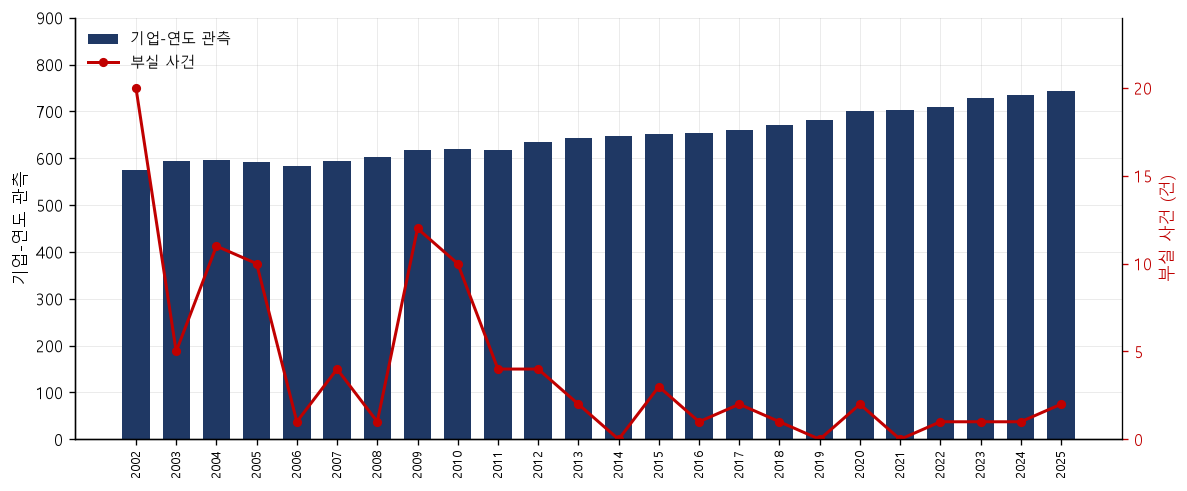

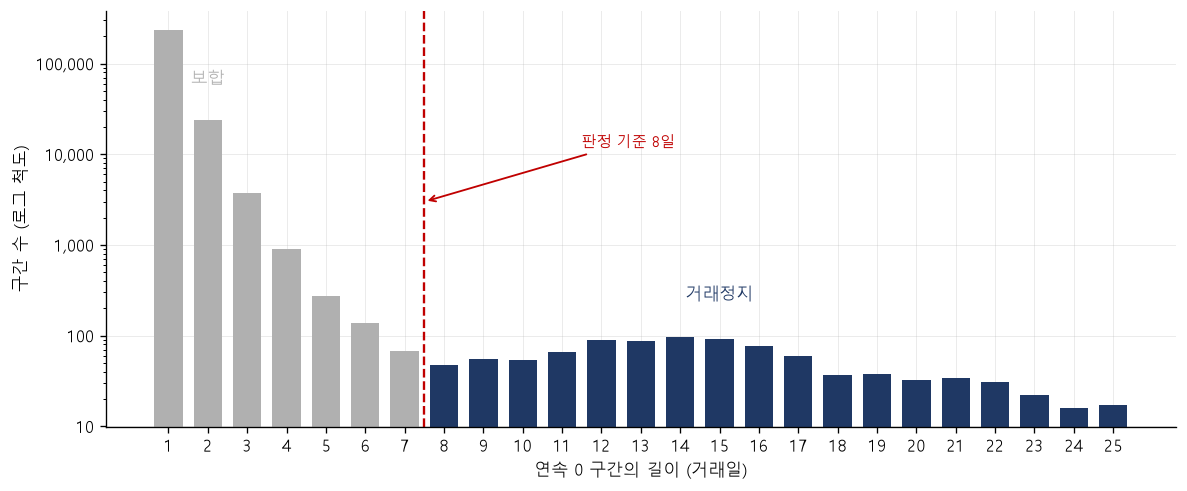

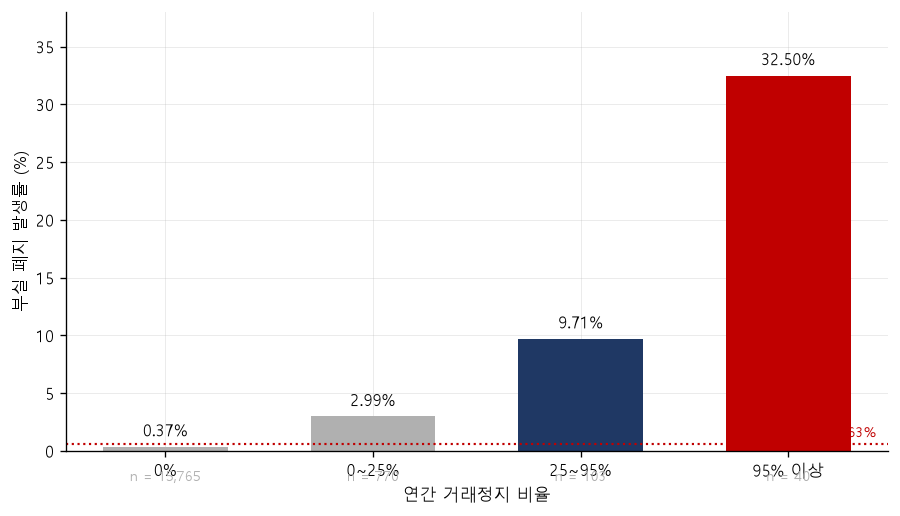

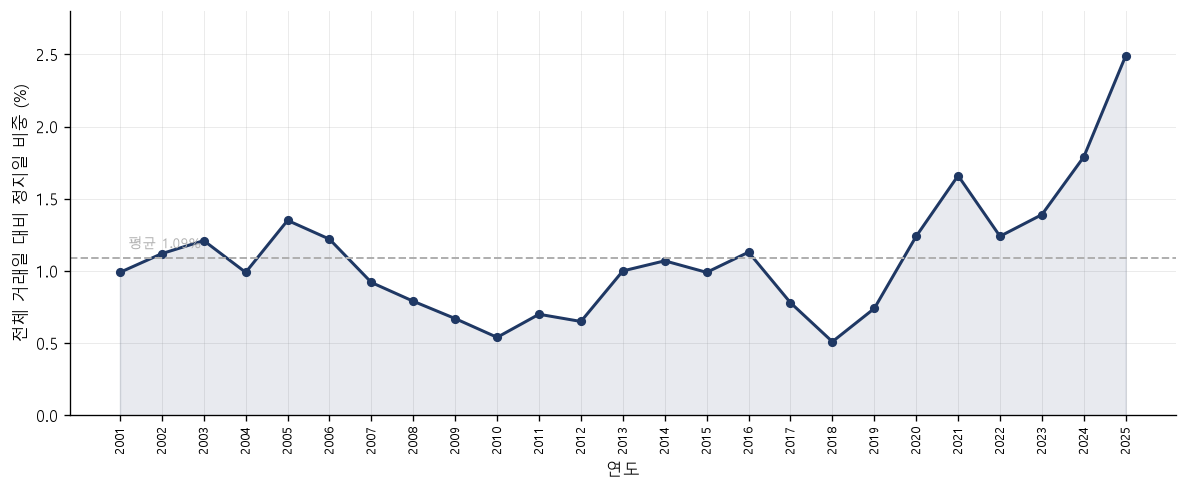

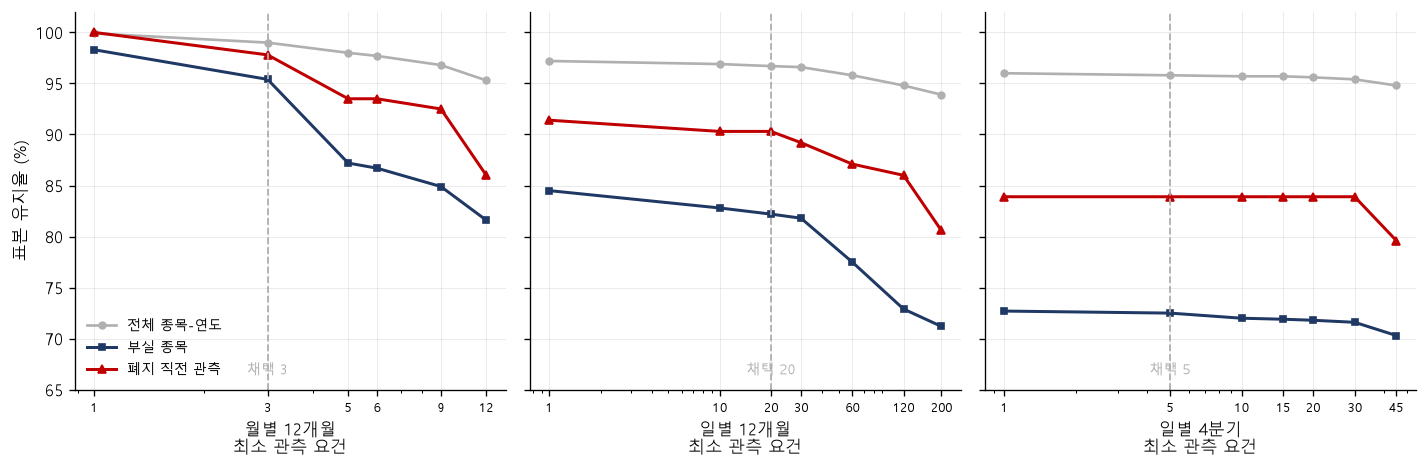

In [55]:
# 그림 1

yr = list(range(2002, 2026))
n = [574, 594, 597, 592, 583, 594, 603, 617, 619, 618, 634, 643,
     647, 652, 653, 661, 670, 682, 701, 703, 710, 729, 734, 743]
ev = [20, 5, 11, 10, 1, 4, 1, 12, 10, 4, 4, 2,
      0, 3, 1, 2, 1, 0, 2, 0, 1, 1, 1, 2]

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(yr, n, color=NAVY, width=0.68, label='기업-연도 관측')
ax.set_ylabel('기업-연도 관측')
ax.set_ylim(0, 900)
ax.set_xticks(yr)
ax.set_xticklabels(yr, rotation=90, fontsize=8)
clean(ax)

ax2 = ax.twinx()
ax2.plot(yr, ev, color=RED, marker='o', markersize=4.5, linewidth=1.8, label='부실 사건')
ax2.set_ylabel('부실 사건 (건)', color=RED)
ax2.tick_params(axis='y', colors=RED)
ax2.set_ylim(0, 24)
ax2.grid(False)
for s in ['top']:
    ax2.spines[s].set_visible(False)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

# 그림 2

L = list(range(1, 26))
cnt = [235489, 23906, 3755, 904, 271, 137, 67, 47, 55, 54, 66, 90, 88,
       97, 91, 77, 59, 37, 38, 32, 34, 31, 22, 16, 17]

fig, ax = plt.subplots(figsize=(10, 4.2))
col = [GRAY if x < 8 else NAVY for x in L]
ax.bar(L, cnt, color=col, width=0.72)
ax.set_yscale('log')
ax.set_xlabel('연속 0 구간의 길이 (거래일)')
ax.set_ylabel('구간 수 (로그 척도)')
ax.set_xticks(L)
ax.axvline(7.5, color=RED, linestyle='--', linewidth=1.4)
ax.annotate('판정 기준 8일', xy=(7.5, 3000), xytext=(11.5, 12000),
            color=RED, fontsize=9,
            arrowprops=dict(arrowstyle='->', color=RED, linewidth=1.1))
ax.annotate('보합', xy=(2, 60000), color=GRAY, fontsize=10, ha='center')
ax.annotate('거래정지', xy=(15, 250), color=NAVY, fontsize=10, ha='center')
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{int(v):,}'))
clean(ax)
plt.tight_layout()
plt.show()

# 그림 3

lab = ['0%', '0~25%', '25~95%', '95% 이상']
rate = [0.37, 2.99, 9.71, 32.50]
obs = [15765, 770, 103, 40]

fig, ax = plt.subplots(figsize=(7.6, 4.4))
b = ax.bar(lab, rate, color=[GRAY, GRAY, NAVY, RED], width=0.6)
ax.set_xlabel('연간 거래정지 비율')
ax.set_ylabel('부실 폐지 발생률 (%)')
ax.set_ylim(0, 38)
for r, o, p in zip(rate, obs, b):
    ax.text(p.get_x() + p.get_width() / 2, r + 0.9, f'{r:.2f}%',
            ha='center', fontsize=10, color='black')
    ax.text(p.get_x() + p.get_width() / 2, -2.6, f'n = {o:,}',
            ha='center', fontsize=8.5, color=GRAY)
ax.axhline(0.63, color=RED, linestyle=':', linewidth=1.3)
ax.text(3.42, 1.2, '전체 평균 0.63%', color=RED, fontsize=8.5, ha='right')
clean(ax)
plt.tight_layout()
plt.show()

# 그림 4

yr = list(range(2001, 2026))
pct = [0.99, 1.12, 1.21, 0.99, 1.35, 1.22, 0.92, 0.79, 0.67, 0.54,
       0.70, 0.65, 1.00, 1.07, 0.99, 1.13, 0.78, 0.51, 0.74, 1.24,
       1.66, 1.24, 1.39, 1.79, 2.49]

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(yr, pct, color=NAVY, marker='o', markersize=4.5, linewidth=1.8)
ax.fill_between(yr, 0, pct, color=NAVY, alpha=0.10)
ax.set_xlabel('연도')
ax.set_ylabel('전체 거래일 대비 정지일 비중 (%)')
ax.set_ylim(0, 2.8)
ax.set_xticks(yr)
ax.set_xticklabels(yr, rotation=90, fontsize=8)
m = float(np.mean(pct))
ax.axhline(m, color=GRAY, linestyle='--', linewidth=1.2)
ax.text(2001.2, m + 0.07, f'평균 {m:.2f}%', color=GRAY, fontsize=8.5)
clean(ax)
plt.tight_layout()
plt.show()

# 그림 5

D = {
 '월별 12개월': ([1, 3, 5, 6, 9, 12],
                [99.9, 99.0, 98.0, 97.7, 96.8, 95.3],
                [98.3, 95.4, 87.2, 86.7, 84.9, 81.6],
                [100.0, 97.8, 93.5, 93.5, 92.5, 86.0], 3),
 '일별 12개월': ([1, 10, 20, 30, 60, 120, 200],
                [97.2, 96.9, 96.7, 96.6, 95.8, 94.8, 93.9],
                [84.5, 82.8, 82.2, 81.8, 77.5, 72.9, 71.2],
                [91.4, 90.3, 90.3, 89.2, 87.1, 86.0, 80.6], 20),
 '일별 4분기': ([1, 5, 10, 15, 20, 30, 45],
               [96.0, 95.8, 95.7, 95.7, 95.6, 95.4, 94.8],
               [72.7, 72.5, 72.0, 71.9, 71.8, 71.6, 70.3],
               [83.9, 83.9, 83.9, 83.9, 83.9, 83.9, 79.6], 5)}

fig, axes = plt.subplots(1, 3, figsize=(12, 4.0), sharey=True)
for ax, (name, (x, a, b, c, pick)) in zip(axes, D.items()):
    ax.plot(x, a, color=GRAY, marker='o', markersize=4, linewidth=1.6, label='전체 종목-연도')
    ax.plot(x, b, color=NAVY, marker='s', markersize=4, linewidth=1.8, label='부실 종목')
    ax.plot(x, c, color=RED, marker='^', markersize=4.5, linewidth=1.8, label='폐지 직전 관측')
    ax.axvline(pick, color=GRAY, linestyle='--', linewidth=1.1)
    ax.text(pick, 66.5, f'채택 {pick}', color=GRAY, fontsize=8.5, ha='center')
    ax.set_xscale('log')
    ax.set_xticks(x)
    ax.set_xticklabels(x, fontsize=8)
    ax.set_xlabel(f'{name}\n최소 관측 요건')
    ax.set_ylim(65, 102)
    clean(ax)
axes[0].set_ylabel('표본 유지율 (%)')
axes[0].legend(loc='lower left', frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()

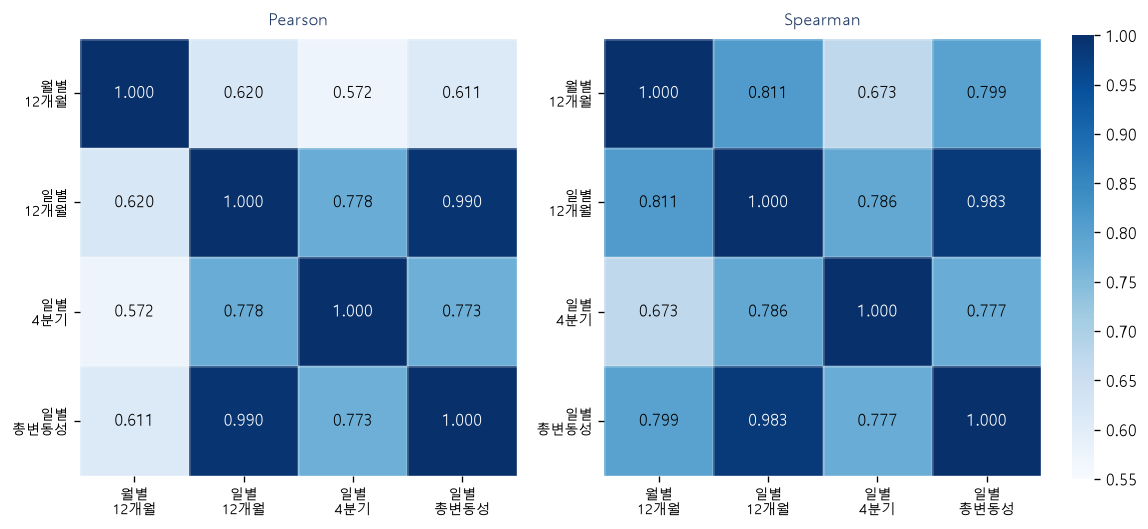

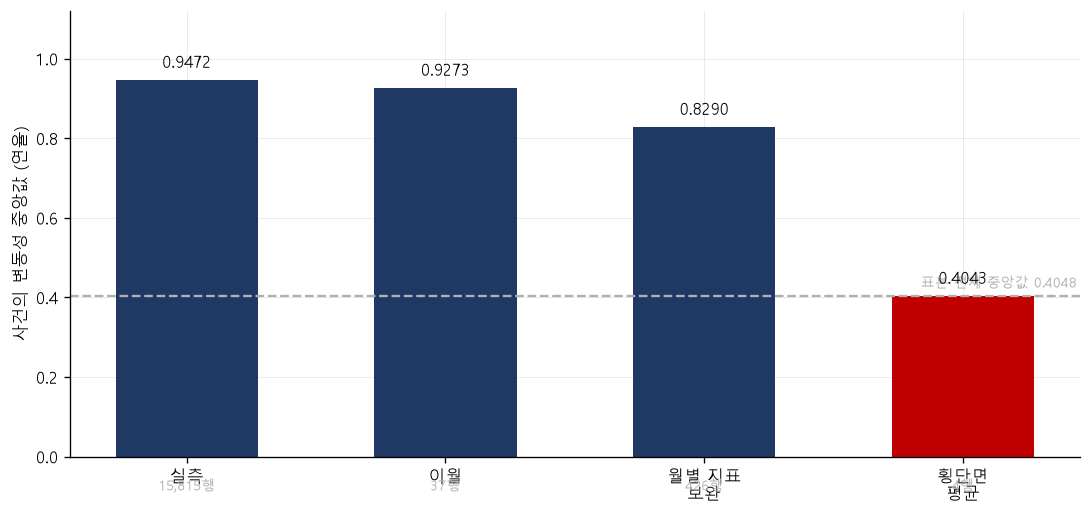

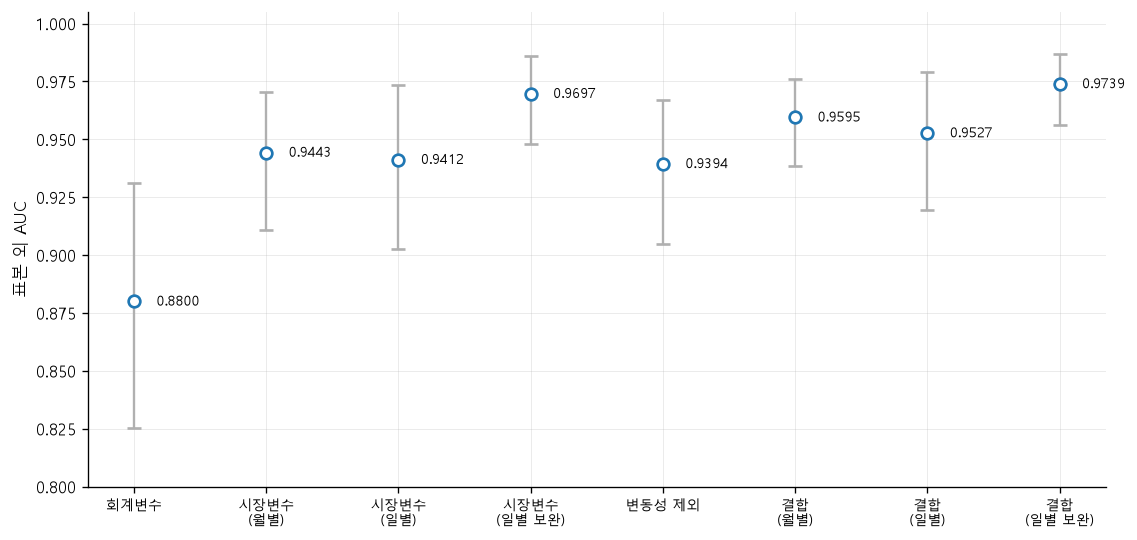

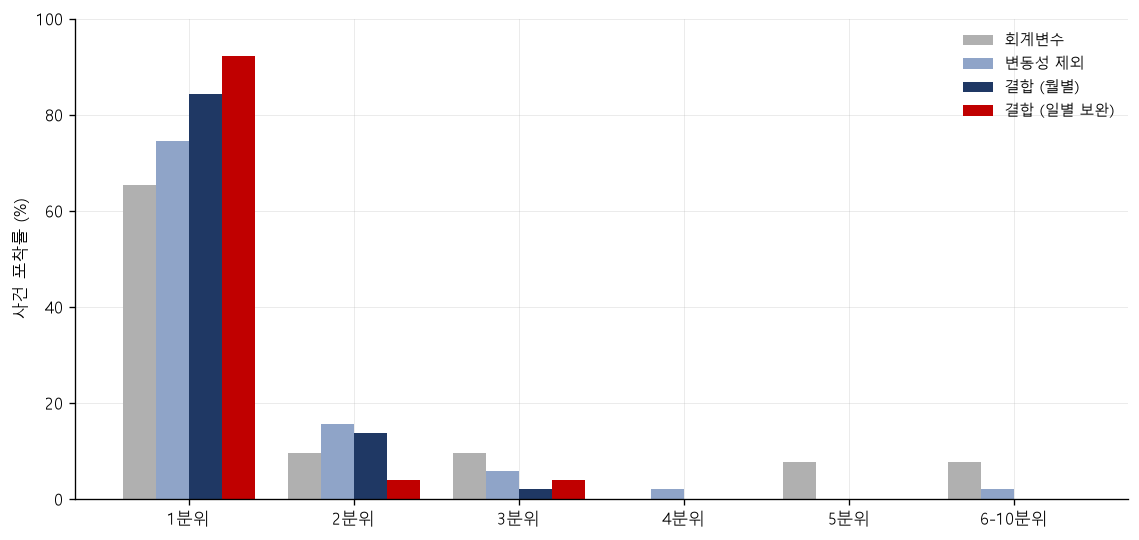

In [58]:
# 그림 6~9

# 그림 6

names = ['월별\n12개월', '일별\n12개월', '일별\n4분기', '일별\n총변동성']
P = np.array([[1.000, 0.620, 0.572, 0.611],
              [0.620, 1.000, 0.778, 0.990],
              [0.572, 0.778, 1.000, 0.773],
              [0.611, 0.990, 0.773, 1.000]])
S = np.array([[1.000, 0.811, 0.673, 0.799],
              [0.811, 1.000, 0.786, 0.983],
              [0.673, 0.786, 1.000, 0.777],
              [0.799, 0.983, 0.777, 1.000]])

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.8))
for ax, M, t in zip(axes, [P, S], ['Pearson', 'Spearman']):
    im = ax.imshow(M, cmap='Blues', vmin=0.55, vmax=1.0)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(names, fontsize=8.5)
    ax.set_yticklabels(names, fontsize=8.5)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{M[i, j]:.3f}', ha='center', va='center', fontsize=9.5,
                    color='white' if M[i, j] > 0.88 else 'black')
    ax.set_xticks(np.arange(-.5, 4, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 4, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1.5)
    ax.grid(which='major', visible=False)
    ax.tick_params(which='minor', length=0)
    ax.set_title(t, fontsize=10, color=NAVY, pad=8)
    for s in ax.spines.values():
        s.set_visible(False)
fig.colorbar(im, ax=axes, fraction=0.030, pad=0.03).outline.set_visible(False)
plt.show()


fig, ax = plt.subplots(figsize=(9.2, 4.4))
paths = ['실측', '이월', '월별 지표\n보완', '횡단면\n평균']
sig = [0.9472, 0.9273, 0.8290, 0.4043]
rows = [15815, 37, 426, 4]
b = ax.bar(paths, sig, color=[NAVY, NAVY, NAVY, RED], width=0.55)
ax.axhline(0.4048, color=GRAY, linestyle='--', linewidth=1.4)
ax.text(3.44, 0.425, '표본 전체 중앙값 0.4048', color=GRAY, fontsize=8.5, ha='right')
ax.set_ylabel('사건의 변동성 중앙값 (연율)')
ax.set_ylim(0, 1.12)
for v, n, p in zip(sig, rows, b):
    ax.text(p.get_x() + p.get_width() / 2, v + 0.03, f'{v:.4f}', ha='center', fontsize=10)
    ax.text(p.get_x() + p.get_width() / 2, -0.085, f'{n:,}행', ha='center',
            fontsize=8.5, color=GRAY)
clean(ax); plt.tight_layout(); plt.show()


fig, ax = plt.subplots(figsize=(9.6, 4.6))
lab = ['회계변수', '시장변수\n(월별)', '시장변수\n(일별)', '시장변수\n(일별 보완)',
       '변동성 제외', '결합\n(월별)', '결합\n(일별)', '결합\n(일별 보완)']
auc = [0.8800, 0.9443, 0.9412, 0.9697, 0.9394, 0.9595, 0.9527, 0.9739]
lo = [0.8255, 0.9108, 0.9025, 0.9479, 0.9047, 0.9387, 0.9196, 0.9561]
hi = [0.9312, 0.9705, 0.9736, 0.9862, 0.9668, 0.9761, 0.9790, 0.9867]
x = np.arange(len(lab))
col = [GRAY] * 7 + [RED]
ax.errorbar(x, auc, yerr=[np.array(auc) - np.array(lo), np.array(hi) - np.array(auc)],
            fmt='o', markersize=7, capsize=4, elinewidth=1.4,
            ecolor=GRAY, markerfacecolor='white', markeredgewidth=1.6)
for i, c in enumerate(col):
    ax.plot(x[i], auc[i], 'o', markersize=7, color=c)
ax.set_xticks(x); ax.set_xticklabels(lab, fontsize=8.5)
ax.set_ylabel('표본 외 AUC')
ax.set_ylim(0.80, 1.005)
for i, v in enumerate(auc):
    ax.text(x[i] + 0.17, v, f'{v:.4f}', fontsize=8.5, va='center')
clean(ax); plt.tight_layout(); plt.show()


fig, ax = plt.subplots(figsize=(9.6, 4.6))
dec = ['1분위', '2분위', '3분위', '4분위', '5분위', '6-10분위']
S = {'회계변수': [65.4, 9.6, 9.6, 0.0, 7.7, 7.6],
     '변동성 제외': [74.5, 15.7, 5.9, 2.0, 0.0, 2.0],
     '결합 (월별)': [84.3, 13.7, 2.0, 0.0, 0.0, 0.0],
     '결합 (일별 보완)': [92.2, 3.9, 3.9, 0.0, 0.0, 0.0]}
x = np.arange(len(dec)); w = 0.2
cols = [GRAY, '#8FA4C8', NAVY, RED]
for i, ((k, v), c) in enumerate(zip(S.items(), cols)):
    ax.bar(x + (i - 1.5) * w, v, width=w, label=k, color=c)
ax.set_xticks(x); ax.set_xticklabels(dec)
ax.set_ylabel('사건 포착률 (%)')
ax.set_ylim(0, 100)
ax.legend(frameon=False, fontsize=9)
clean(ax); plt.tight_layout(); plt.show()

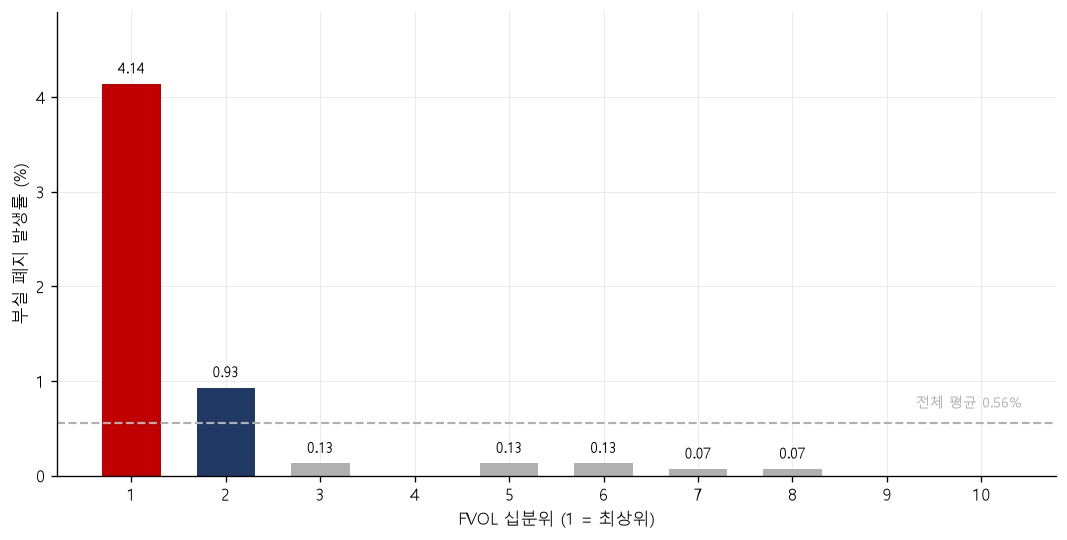

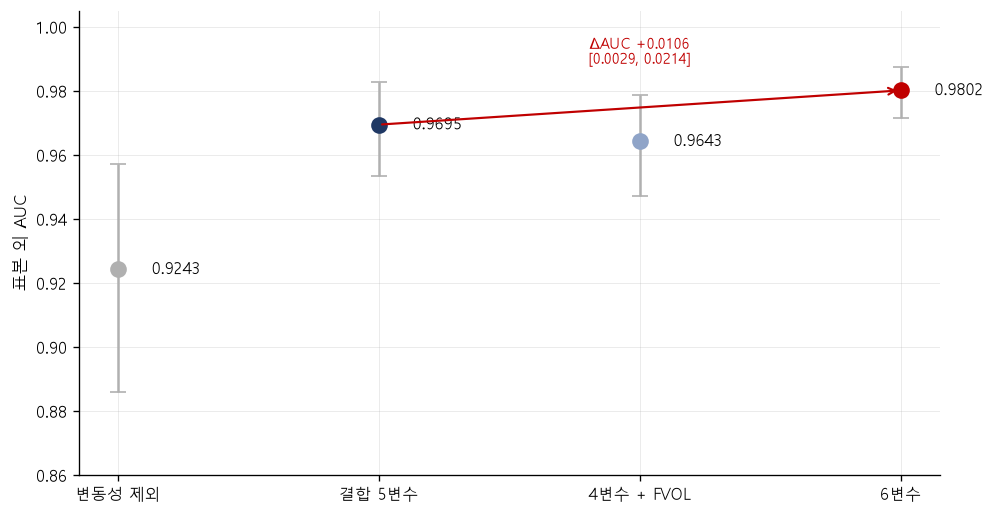

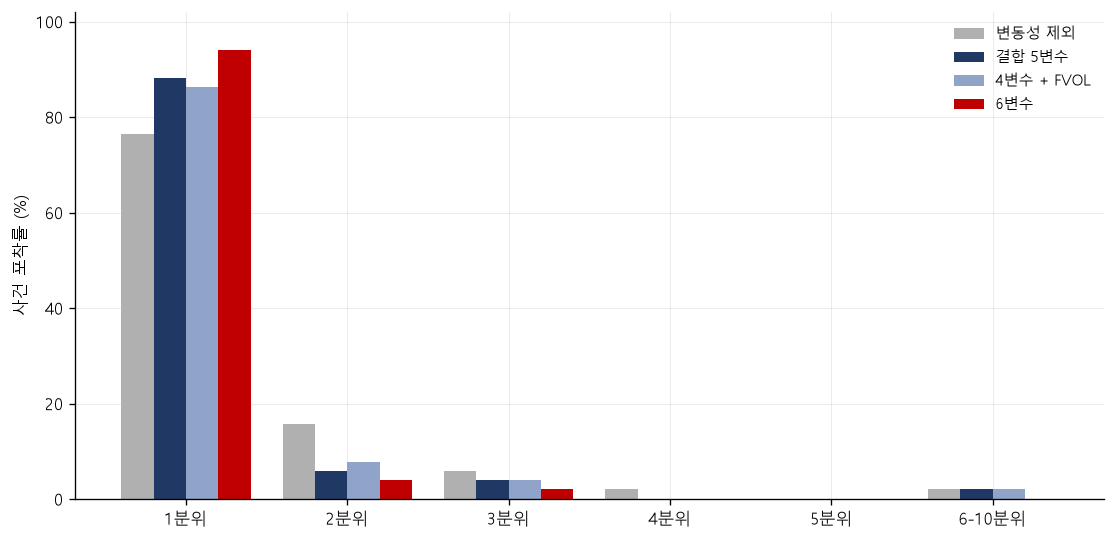

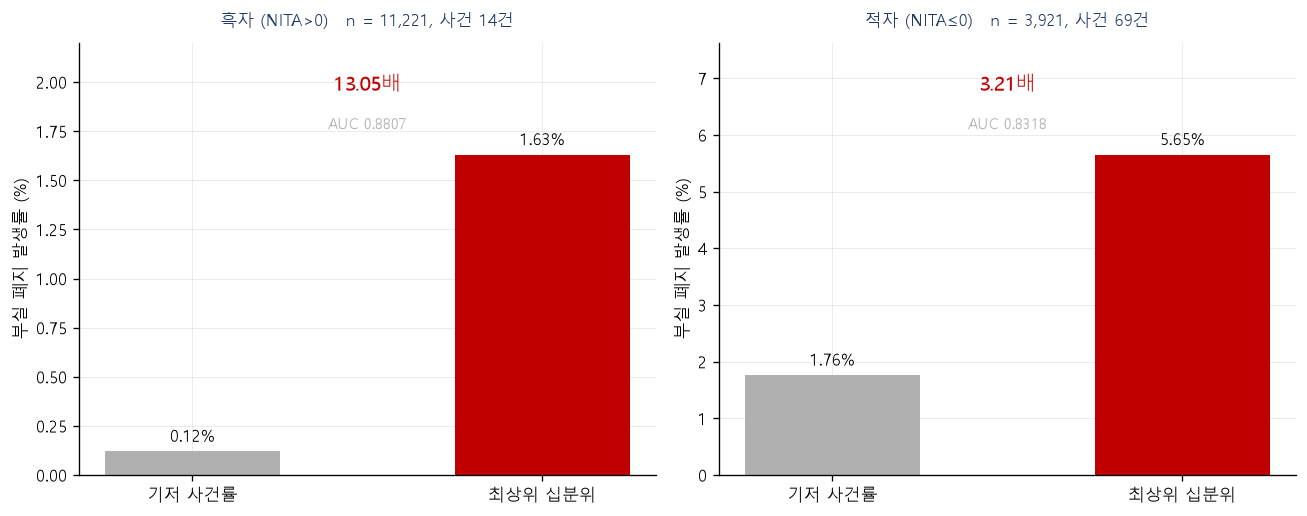

In [56]:
# 그림 10~13

fig, ax = plt.subplots(figsize=(9.0, 4.6))
dec = list(range(1, 11))
rate = [4.14, 0.93, 0.13, 0.00, 0.13, 0.13, 0.07, 0.07, 0.00, 0.00]
obs = [1521, 1513, 1514, 1513, 1509, 1518, 1514, 1513, 1514, 1526]
col = [RED, NAVY] + [GRAY] * 8
b = ax.bar(dec, rate, color=col, width=0.62)
ax.axhline(0.56, color=GRAY, linestyle='--', linewidth=1.3)
ax.text(10.42, 0.72, '전체 평균 0.56%', color=GRAY, fontsize=8.5, ha='right')
ax.set_xlabel('FVOL 십분위 (1 = 최상위)')
ax.set_ylabel('부실 폐지 발생률 (%)')
ax.set_xticks(dec)
ax.set_ylim(0, 4.9)
for v, p in zip(rate, b):
    if v > 0:
        ax.text(p.get_x() + p.get_width() / 2, v + 0.11, f'{v:.2f}', ha='center', fontsize=9)

clean(ax); plt.tight_layout(); plt.show()


fig, ax = plt.subplots(figsize=(8.4, 4.4))
lab = ['변동성 제외', '결합 5변수', '4변수 + FVOL', '6변수']
auc = [0.9243, 0.9695, 0.9643, 0.9802]
lo = [0.8860, 0.9533, 0.9471, 0.9717]
hi = [0.9572, 0.9827, 0.9787, 0.9875]
x = np.arange(len(lab))
cols = [GRAY, NAVY, '#8FA4C8', RED]
ax.errorbar(x, auc, yerr=[np.array(auc) - np.array(lo), np.array(hi) - np.array(auc)],
            fmt='none', capsize=5, elinewidth=1.5, ecolor=GRAY)
for i, c in enumerate(cols):
    ax.plot(x[i], auc[i], 'o', markersize=9, color=c)
    ax.text(x[i] + 0.13, auc[i], f'{auc[i]:.4f}', fontsize=9.5, va='center')
ax.set_xticks(x); ax.set_xticklabels(lab, fontsize=9.5)
ax.set_ylabel('표본 외 AUC')
ax.set_ylim(0.86, 1.005)
ax.annotate('', xy=(3, 0.9802), xytext=(1, 0.9695),
            arrowprops=dict(arrowstyle='->', color=RED, linewidth=1.3))
ax.text(2.0, 0.9885, 'ΔAUC +0.0106\n[0.0029, 0.0214]', color=RED,
        fontsize=9, ha='center')
clean(ax); plt.tight_layout(); plt.show()


fig, ax = plt.subplots(figsize=(9.4, 4.6))
dec = ['1분위', '2분위', '3분위', '4분위', '5분위', '6-10분위']
S = {'변동성 제외': [76.5, 15.7, 5.9, 2.0, 0.0, 2.0],
     '결합 5변수': [88.2, 5.9, 3.9, 0.0, 0.0, 2.0],
     '4변수 + FVOL': [86.3, 7.8, 3.9, 0.0, 0.0, 2.0],
     '6변수': [94.1, 3.9, 2.0, 0.0, 0.0, 0.0]}
x = np.arange(len(dec)); w = 0.2
cols = [GRAY, NAVY, '#8FA4C8', RED]
for i, ((k, v), c) in enumerate(zip(S.items(), cols)):
    ax.bar(x + (i - 1.5) * w, v, width=w, label=k, color=c)
ax.set_xticks(x); ax.set_xticklabels(dec)
ax.set_ylabel('사건 포착률 (%)')
ax.set_ylim(0, 102)
ax.legend(frameon=False, fontsize=9)
clean(ax); plt.tight_layout(); plt.show()


fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))
for ax, (name, base, top, mult, auc, n, ev) in zip(
        axes,
        [('흑자 (NITA>0)', 0.12, 1.63, 13.05, 0.8807, 11221, 14),
         ('적자 (NITA≤0)', 1.76, 5.65, 3.21, 0.8318, 3921, 69)]):
    b = ax.bar(['기저 사건률', '최상위 십분위'], [base, top],
               color=[GRAY, RED], width=0.5)
    for v, p in zip([base, top], b):
        ax.text(p.get_x() + p.get_width() / 2, v + top * 0.03, f'{v:.2f}%',
                ha='center', fontsize=10)
    ax.set_ylim(0, top * 1.35)
    ax.set_ylabel('부실 폐지 발생률 (%)')
    ax.set_title(f'{name}   n = {n:,}, 사건 {ev}건', fontsize=10, color=NAVY, pad=10)
    ax.text(0.5, top * 1.20, f'{mult:.2f}배', ha='center', color=RED, fontsize=12)
    ax.text(0.5, top * 1.08, f'AUC {auc:.4f}', ha='center', color=GRAY, fontsize=9)
    clean(ax)
plt.tight_layout(); plt.show()

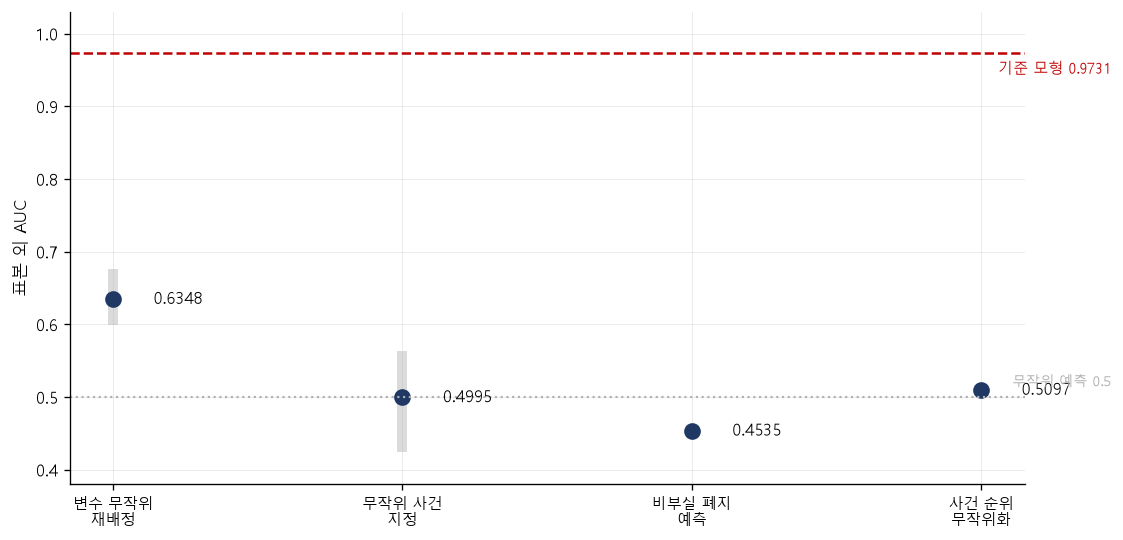

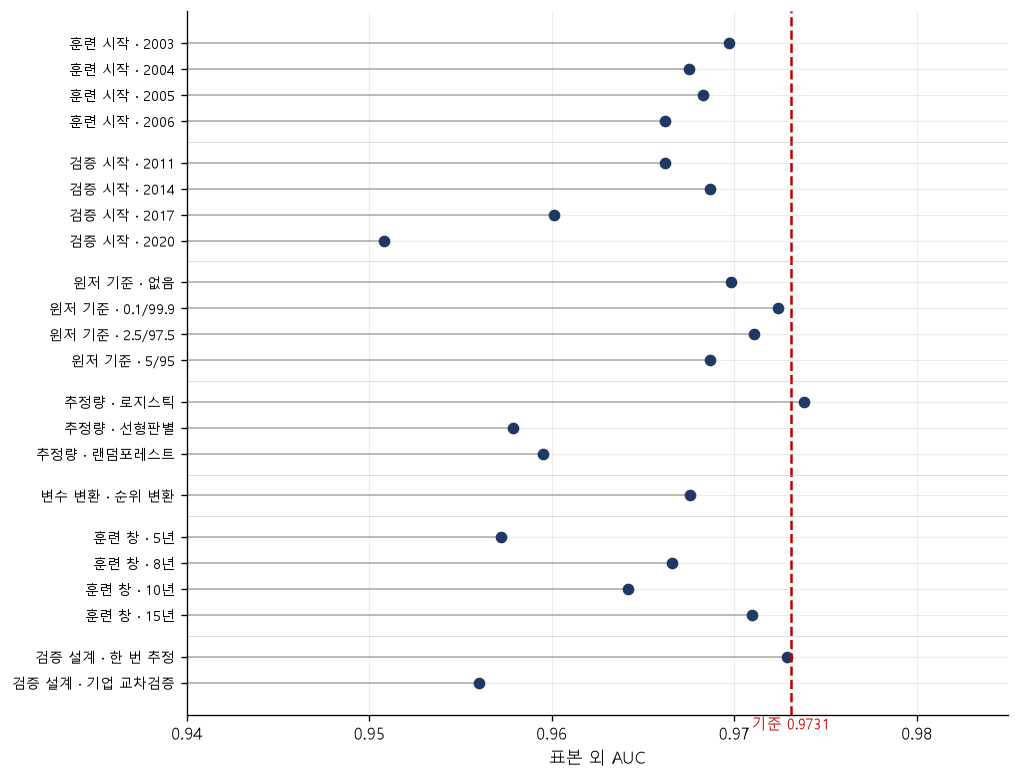

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


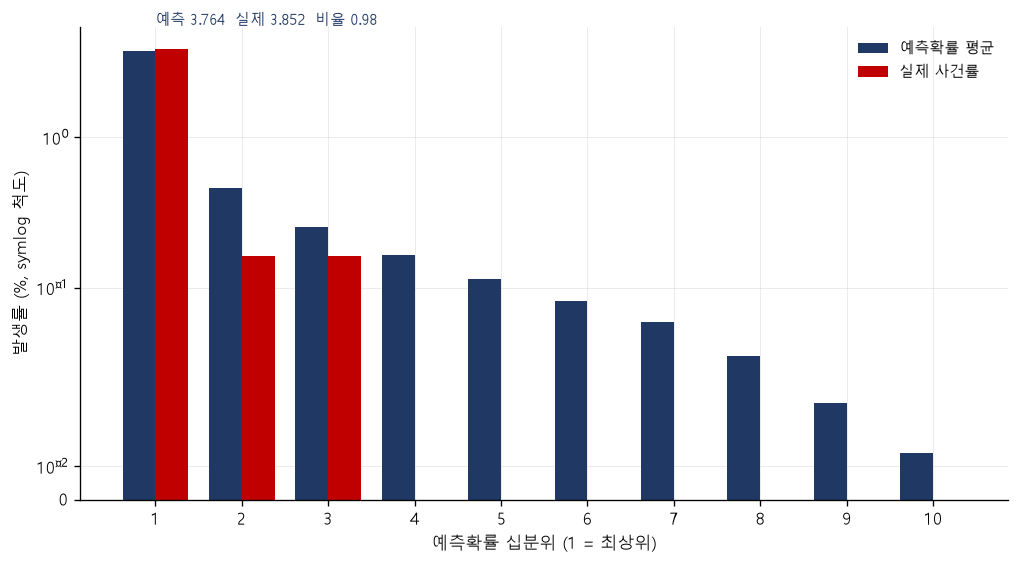

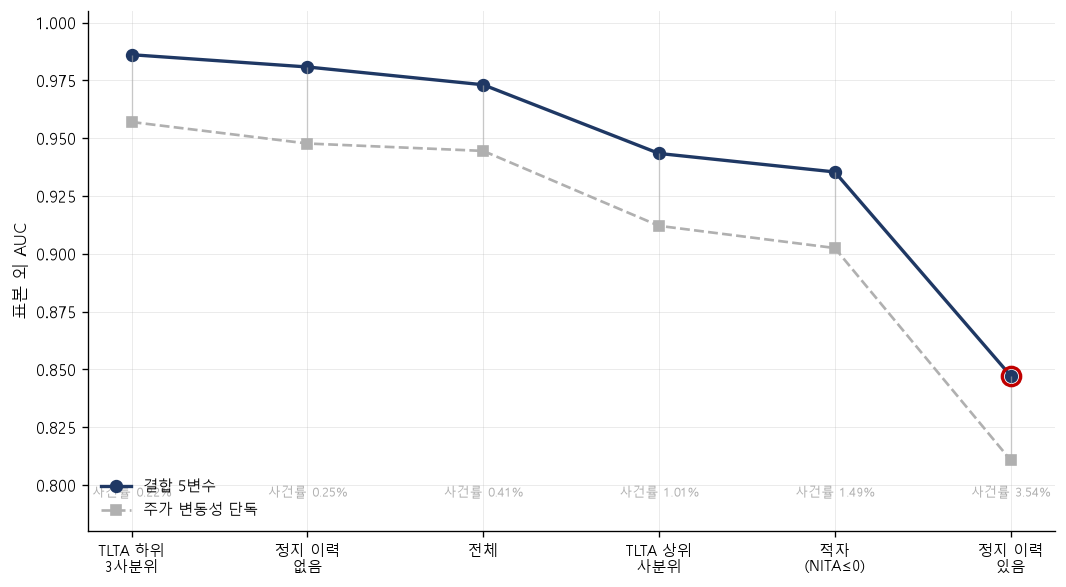

In [54]:
# 그림 14~17

fig, ax = plt.subplots(figsize=(9.4, 4.6))
lab = ['변수 무작위\n재배정', '무작위 사건\n지정', '비부실 폐지\n예측', '사건 순위\n무작위화']
val = [0.6348, 0.4995, 0.4535, 0.5097]
rng = [(0.5990, 0.6757), (0.4248, 0.5628), None, None]
x = np.arange(len(lab))
for i, (v, r) in enumerate(zip(val, rng)):
    if r:
        ax.vlines(x[i], r[0], r[1], color=GRAY, linewidth=6, alpha=0.45)
    ax.plot(x[i], v, 'o', markersize=9, color=NAVY)
    ax.text(x[i] + 0.14, v, f'{v:.4f}', fontsize=9.5, va='center')
ax.axhline(0.5, color=GRAY, linestyle=':', linewidth=1.3)
ax.text(3.45, 0.515, '무작위 예측 0.5', color=GRAY, fontsize=8.5, ha='right')
ax.axhline(0.9731, color=RED, linestyle='--', linewidth=1.5)
ax.text(3.45, 0.945, '기준 모형 0.9731', color=RED, fontsize=9, ha='right')
ax.set_xticks(x); ax.set_xticklabels(lab, fontsize=9)
ax.set_ylabel('표본 외 AUC')
ax.set_ylim(0.38, 1.03)
clean(ax); plt.tight_layout(); plt.show()


fig, ax = plt.subplots(figsize=(8.6, 6.6))
G = [('훈련 시작', ['2003', '2004', '2005', '2006'], [0.9697, 0.9675, 0.9683, 0.9662]),
     ('검증 시작', ['2011', '2014', '2017', '2020'], [0.9662, 0.9687, 0.9601, 0.9508]),
     ('윈저 기준', ['없음', '0.1/99.9', '2.5/97.5', '5/95'], [0.9698, 0.9724, 0.9711, 0.9687]),
     ('추정량', ['로지스틱', '선형판별', '랜덤포레스트'], [0.9738, 0.9579, 0.9595]),
     ('변수 변환', ['순위 변환'], [0.9676]),
     ('훈련 창', ['5년', '8년', '10년', '15년'], [0.9572, 0.9666, 0.9642, 0.9710]),
     ('검증 설계', ['한 번 추정', '기업 교차검증'], [0.9729, 0.9560])]
ypos, ylab, yval, sep = [], [], [], []
k = 0
for g, ls, vs in G:
    for l, v in zip(ls, vs):
        ypos.append(k); ylab.append(f'{g} · {l}'); yval.append(v); k += 1
    sep.append(k - 0.5); k += 0.6
ax.hlines(ypos, 0.94, yval, color=GRAY, linewidth=1.0)
ax.plot(yval, ypos, 'o', markersize=6, color=NAVY)
ax.axvline(0.9731, color=RED, linestyle='--', linewidth=1.5)
ax.text(0.9731, k + 0.2, '기준 0.9731', color=RED, fontsize=9, ha='center')
for s in sep[:-1]:
    ax.axhline(s + 0.3, color=GRAY, linewidth=0.5, alpha=0.5)
ax.set_yticks(ypos); ax.set_yticklabels(ylab, fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel('표본 외 AUC')
ax.set_xlim(0.94, 0.985)
clean(ax); plt.tight_layout(); plt.show()


fig, ax = plt.subplots(figsize=(8.6, 4.8))
dec = list(range(1, 11))
pred = [3.764, 0.459, 0.253, 0.165, 0.114, 0.081, 0.059, 0.043, 0.029, 0.014]
actu = [3.852, 0.162, 0.163, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000]
w = 0.38
x = np.arange(len(dec))
ax.bar(x - w / 2, pred, width=w, color=NAVY, label='예측확률 평균')
ax.bar(x + w / 2, actu, width=w, color=RED, label='실제 사건률')
ax.set_yscale('symlog', linthresh=0.05)
ax.set_xticks(x); ax.set_xticklabels(dec)
ax.set_xlabel('예측확률 십분위 (1 = 최상위)')
ax.set_ylabel('발생률 (%, symlog 척도)')
ax.legend(frameon=False, fontsize=9)
ax.text(0, 5.6, '예측 3.764  실제 3.852  비율 0.98', color=NAVY, fontsize=9, ha='left')
clean(ax); plt.tight_layout(); plt.show()


fig, ax = plt.subplots(figsize=(9.0, 5.0))
sub = ['TLTA 하위\n3사분위', '정지 이력\n없음', '전체', 'TLTA 상위\n사분위',
       '적자\n(NITA≤0)', '정지 이력\n있음']
rate = [0.22, 0.25, 0.41, 1.01, 1.49, 3.54]
m5 = [0.9861, 0.9808, 0.9731, 0.9434, 0.9354, 0.8473]
m1 = [0.9570, 0.9477, 0.9445, 0.9121, 0.9025, 0.8108]
x = np.arange(len(sub))
ax.plot(x, m5, 'o-', color=NAVY, markersize=7, linewidth=2.0, label='결합 5변수')
ax.plot(x, m1, 's--', color=GRAY, markersize=6, linewidth=1.6, label='주가 변동성 단독')
for i, (a, b) in enumerate(zip(m5, m1)):
    ax.vlines(x[i], b, a, color=GRAY, linewidth=0.8, alpha=0.6)
ax.plot(x[-1], m5[-1], 'o', markersize=11, markerfacecolor='none',
        markeredgecolor=RED, markeredgewidth=2.0)
ax.set_xticks(x); ax.set_xticklabels(sub, fontsize=9)
ax.set_ylabel('표본 외 AUC')
ax.set_ylim(0.78, 1.005)
for i, r in enumerate(rate):
    ax.text(x[i], 0.795, f'사건률 {r:.2f}%', ha='center', fontsize=8, color=GRAY)
ax.legend(frameon=False, fontsize=9, loc='lower left')
clean(ax); plt.tight_layout(); plt.show()

In [57]:
# 진단

import numpy as np, pandas as pd

hd = pd.read_parquet('halt_daily.parquet')
dc = pd.read_parquet('delisted_cat.parquet')
bad = set(dc.query('is_bad == 1 and excl == 0')['code'])

d = hd[hd['dret'].notna()].sort_values(['code', 'date']).copy()
z = (d['dret'] == 0).to_numpy(); code = d['code'].to_numpy()
g = np.zeros(len(d), int); k = 0
for i in range(len(d)):
    if i == 0 or code[i] != code[i-1] or z[i] != z[i-1]:
        k += 1
    g[i] = k
d['grp'] = g
runs = (d[z].groupby('grp')
        .agg(code=('code','first'), year=('year','first'), n=('dret','size'))
        .reset_index(drop=True))
runs['bad'] = runs['code'].isin(bad)

BINS = [1,2,3,4,5,6,7,8,10,15,20,30,10**6]
LAB = ['1','2','3','4','5','6','7','8-9','10-14','15-19','20-29','30+']
runs['bin'] = pd.cut(runs['n'], bins=BINS, right=False, labels=LAB)

rows = []
for t in range(2008, 2026):
    tr = runs[(runs['year'] >= 2002) & (runs['year'] < t)]
    v = tr[tr['bad']]['bin'].value_counts().reindex(LAB, fill_value=0)
    f = tr[tr['bad']].groupby('code')['bin'].nunique()
    rows.append({'훈련 구간': f'2002~{t-1}', '부실 구간 수': int(tr['bad'].sum()),
                 '부실 종목': tr[tr['bad']]['code'].nunique(),
                 '최소 셀': int(v.min()), '최대 셀': int(v.max()),
                 '5 미만 셀': int((v < 5).sum())})
cw = pd.DataFrame(rows).set_index('훈련 구간')
print('[AH-2] 훈련 구간별 부실 종목의 길이 구간 셀')
print(cw.to_string())
print()

tr = runs[(runs['year'] >= 2002) & (runs['year'] < 2008) & runs['bad']]
v = tr['bin'].value_counts().reindex(LAB, fill_value=0)
print('  최초 훈련 구간 (2002~2007) 부실 종목 길이 구간별 관측')
print('  ' + '  '.join(f'{a}:{int(b)}' for a, b in v.items()))

[AH-2] 훈련 구간별 부실 종목의 길이 구간 셀
           부실 구간 수  부실 종목  최소 셀  최대 셀  5 미만 셀
훈련 구간                                        
2002~2007     6272     97     5  5298       0
2002~2008     6988     97     5  5937       0
2002~2009     7708     97     7  6542       0
2002~2010     8265     97     7  6994       0
2002~2011     8529     97     7  7221       0
2002~2012     8753     97     8  7416       0
2002~2013     8933     97     9  7567       0
2002~2014     9093     97     9  7713       0
2002~2015     9242     97     9  7852       0
2002~2016     9346     97     9  7944       0
2002~2017     9490     97     9  8065       0
2002~2018     9594     97     9  8160       0
2002~2019     9663     97     9  8224       0
2002~2020     9728     97     9  8283       0
2002~2021     9781     97     9  8332       0
2002~2022     9828     97     9  8377       0
2002~2023     9857     97     9  8404       0
2002~2024     9869     97     9  8411       0

  최초 훈련 구간 (2002~2007) 부실 종목 길이 구간별 관측
  1:5298  2

In [61]:
# 진단

import numpy as np, pandas as pd

hd = pd.read_parquet('halt_daily.parquet')
dc = pd.read_parquet('delisted_cat.parquet')

dcx = dc.query('excl == 0').copy()
dcx['del_year'] = pd.to_datetime(dcx['del_date']).dt.year

d = hd[hd['dret'].notna()].sort_values(['code', 'date']).copy()
z = (d['dret'] == 0).to_numpy(); code = d['code'].to_numpy()
g = np.zeros(len(d), int); k = 0
for i in range(len(d)):
    if i == 0 or code[i] != code[i-1] or z[i] != z[i-1]:
        k += 1
    g[i] = k
d['grp'] = g
runs = (d[z].groupby('grp')
        .agg(code=('code', 'first'), year=('year', 'first'), n=('dret', 'size'))
        .reset_index(drop=True))

CAND = list(range(3, 31))

def best_cut(sub):
    tot = sub.groupby('code')['bad'].first()
    out = []
    for c in CAND:
        hit = sub[sub['n'] >= c].groupby('code').size()
        cov = tot.index.isin(hit.index)
        a = int((cov & tot.to_numpy()).sum())
        b = int((cov & ~tot.to_numpy()).sum())
        p = int(tot.sum()); q = int(len(tot) - p)
        if p == 0 or q == 0:
            out.append((c, np.nan)); continue
        out.append((c, a / p - b / q))
    o = pd.DataFrame(out, columns=['cut', 'ks']).dropna()
    return int(o.loc[o['ks'].idxmax(), 'cut']), float(o['ks'].max()), o

def window(t):
    known = set(dcx[(dcx['is_bad'] == 1) & (dcx['del_year'] < t)]['code'])
    sub = runs[(runs['year'] >= 2002) & (runs['year'] < t)].copy()
    sub['bad'] = sub['code'].isin(known)
    return sub

rows = []
for t in range(2008, 2026):
    sub = window(t)
    if sub['bad'].sum() == 0:
        continue
    c, v, _ = best_cut(sub)
    rows.append({'훈련 구간': f'2002~{t-1}',
                 '부실 종목': int(sub[sub['bad']]['code'].nunique()),
                 '최적 절단점(일)': c, 'KS 통계량': round(v, 4)})
tab = pd.DataFrame(rows).set_index('훈련 구간')

print('[AI] 훈련 구간만으로 탐색한 절단점')
print(tab.to_string())
print()
print(f"  최적 절단점 범위 {tab['최적 절단점(일)'].min()}일 ~ {tab['최적 절단점(일)'].max()}일")
print(f"  최빈값 {tab['최적 절단점(일)'].mode().tolist()}")
print()

_, _, o = best_cut(window(2008))
top = o.sort_values('ks', ascending=False).head(8)
print('[AI-2] 최초 훈련 구간(2002~2007)의 절단점별 분리도')
print(top.to_string(index=False))
print()
print(f"  1위와 8위의 KS 차이 {top['ks'].iloc[0] - top['ks'].iloc[-1]:.4f}")

[AI] 훈련 구간만으로 탐색한 절단점
           부실 종목  최적 절단점(일)  KS 통계량
훈련 구간                              
2002~2007     51         11  0.4653
2002~2008     52         12  0.4366
2002~2009     63         12  0.4719
2002~2010     73         17  0.5100
2002~2011     77         17  0.5177
2002~2012     81         17  0.5139
2002~2013     83         17  0.5056
2002~2014     83         17  0.4897
2002~2015     86         17  0.5000
2002~2016     87         17  0.5022
2002~2017     88         17  0.4947
2002~2018     89         19  0.4929
2002~2019     89         19  0.4909
2002~2020     90         19  0.4881
2002~2021     90         19  0.4863
2002~2022     91         19  0.4875
2002~2023     92         19  0.4813
2002~2024     92         19  0.4755

  최적 절단점 범위 11일 ~ 19일
  최빈값 [17]

[AI-2] 최초 훈련 구간(2002~2007)의 절단점별 분리도
 cut       ks
  11 0.465257
  12 0.458150
  13 0.455729
  20 0.455270
  14 0.451746
  21 0.449724
   9 0.448928
  18 0.446752

  1위와 8위의 KS 차이 0.0185
